# «Лаборатории исследований гражданского общества». Определение уязвимых групп населения

Согласно опросу [«инФОМ»](https://www.cbr.ru/Collection/Collection/File/39633/inFOM_21-12.pdf) от декабря 2021 года, у27% россиян хватает денег только на еду, а ещё 9% не могут позволить себе полноценное питание.Эти люди особенно внимательно следят за ценами, а темп роста цен на продукты обычно превышает средний темп инфляции.При этом Росстат [считает](https://www.fedstat.ru/indicator/37053) что расходы на продукты питания должны составлять примерно 36% от среднемесячных расходов россиянина (ещё около 10% приходится на услуги ЖКХ и жильё, 4% — на лекарства).

До 2021 года «черта бедности» (жизнь на сумму ниже прожиточного минимума) в России определялась стоимостью [минимальной продуктовой корзины](https://base.garant.ru/70306880/). В том же году правительство «отвязало» уровень бедности от цен на базовые продукты: с 2021 года прожиточный минимум рассчитывается как 44.2% от медианного дохода граждан РФ за прошлый год.

В нашем распоряжении есть данные о доходах, заболеваемости, социальнонезащищённых слоях населения России и другие экономические и демографические данные.

### Постановка целей и задач

*Цель* — выявить регионы и группы населения, находящиеся в наиболее уязвимом социально-экономическом положении.

*Задачи:*

Кластеризовать регионы по признакам бедности, здоровья, доходов и демографии.

Определить, какие группы (дети, пенсионеры, инвалиды и др.) чаще сталкиваются с бедностью.

Найти связи бедности с производством, потреблением и социальной инфраструктурой

## Часть 1. Знакомство с данными. Очистка от пропусков и дубликатов. Предварительный анализ

In [440]:
# загрузим необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings 
import os, re, glob, difflib

from functools import reduce

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture


from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn import metrics
from sklearn import ensemble
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn import preprocessing


import hyperopt
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import GridSearchCV
from functools import partial



In [3]:

# соберем словарь названия регионов, чтобы в дальнейшем привести все регионы к одному стандаруту
region_map = {
  "bладимирская область": "Владимирская область",
  "bолгоградская область": "Волгоградская область",
  "bологодская область": "Вологодская область",
  "bоронежская область": "Воронежская область",
  "агинский бурятский округ (забайкальский край)": "Агинский Бурятский округ",
  "алтайский край": "Алтайский край",
  "амурская область": "Амурская область",
  "архангельская область": "Архангельская область",
  "архангельская область (без ао)": "Архангельская область без НАО",
  "архангельская область (без ненецкого автономного округа)": "Архангельская область без НАО",
  "архангельская область (кроме ненецкого автономного округа)": "Архангельская область без НАО",
  "архангельская область без авт. округа": "Архангельская область без НАО",
  "архангельская область без нао": "Архангельская область без НАО",
  "архангельская обл. без данных по ненецкому авт. окр.": "Архангельская область без НАО",
  "архангельская область без автономного округа": "Архангельская область без НАО",
  "астраханская область": "Астраханская область",
  "белгородская область": "Белгородская область",
  "брянская область": "Брянская область",
  "владимирская область": "Владимирская область",
  "волго-вятский район": "Волго-Вятский район",
  "волгоградская область": "Волгоградская область",
  "вологодская область": "Вологодская область",
  "воронежская область": "Воронежская область",
  "восточно-сибирский район": "Восточно-Сибирский район",
  "г. байконур": "г. Байконур",
  "г. москва": "г. Москва",
  "г. санкт-петербург": "г. Санкт-Петербург",
  "г. севастополь": "г. Севастополь",
  "г.москва": "г. Москва",
  "город москва": "г. Москва",
  "город москва столица российской федерации город федерального значения": "г. Москва",
  "город санкт - петербург": "г. Санкт-Петербург",
  "город санкт-петербург": "г. Санкт-Петербург",
  "город санкт-петербург город федерального значения": "г. Санкт-Петербург",
  "город севастополь": "г. Севастополь",
  "город федерального значения севастополь": "г. Севастополь",
  "дальневосточный район": "Дальневосточный Федеральный Округ",
  "дальневосточный федеральный округ": "Дальневосточный Федеральный Округ",
  "еврейская авт. область": "Еврейская автономная область",
  "еврейская автономная область": "Еврейская автономная область",
  "забайкальский край": "Забайкальский край",
  "западно-сибирский район": "Западно-Сибирский район",
  "ивановская область": "Ивановская область",
  "иркутская область": "Иркутская область",
  "кабардино-балкарская республика": "Кабардино-Балкарская Республика",
  "калининградская область": "Калининградская область",
  "калужская область": "Калужская область",
  "камчатский край": "Камчатский край",
  "карачаево-черкесская республика": "Карачаево-Черкесская Республика",
  "кемеровская область": "Кемеровская область",
  "кемеровская область - кузбасс": "Кемеровская область",
  "кировская область": "Кировская область",
  "коми-пермяцкий округ, входящий в состав пермского края": "Коми-Пермяцкий Округ",
  "корякский округ, входящий в состав камчатского края": "Корякский Округ",
  "костромская область": "Костромская область",
  "краснодарский край": "Краснодарский край",
  "красноярский край": "Красноярский край",
  "крымский федеральный округ": "Республика Крым",
  "курганская область": "Курганская область",
  "курская область": "Курская область",
  "ленинградская область": "Ленинградская область",
  "липецкая область": "Липецкая область",
  "магаданская область": "Магаданская область",
  "москва в старых границах": "г. Москва",
  "московская обл. в старых границах": "Московская область",
  "московская область": "Московская область",
  "мурманская область": "Мурманская область",
  "ненецкий авт. округ": "Ненецкий автономный округ",
  "ненецкий автономный округ": "Ненецкий автономный округ",
  "ненецкий автономный округ (архангельская область)": "Ненецкий автономный округ",
  "нижегородская область": "Нижегородская область",
  "новгородская область": "Новгородская область",
  "новосибирская область": "Новосибирская область",
  "омская область": "Омская область",
  "оренбургская область": "Оренбургская область",
  "орловская область": "Орловская область",
  "пензенская область": "Пензенская область",
  "пермский край": "Пермский край",
  "поволжский район": "Поволжский район",
  "приволжский федеральный округ": "Приволжский Федеральный Округ",
  "приморский край": "Приморский край",
  "псковская область": "Псковская область",
  "республика адыгея": "Республика Адыгея",
  "республика адыгея (адыгея)": "Республика Адыгея",
  "республика адыгея (адыгея) (до 03.06.2014)": "Республика Адыгея",
  "республика алтай": "Республика Алтай",
  "республика башкортостан": "Республика Башкортостан",
  "республика бурятия": "Республика Бурятия",
  "республика дагестан": "Республика Дагестан",
  "республика ингушетия": "Республика Ингушетия",
  "республика калмыкия": "Республика Калмыкия",
  "республика карелия": "Республика Карелия",
  "республика коми": "Республика Коми",
  "республика крым": "Республика Крым",
  "республика марий эл": "Республика Марий Эл",
  "республика мордовия": "Республика Мордовия",
  "республика саха (якутия)": "Республика Саха (Якутия)",
  "республика саха(якутия)": "Республика Саха (Якутия)",
  "республика северная осетия - алания": "Республика Северная Осетия-Алания",
  "республика северная осетия-алания": "Республика Северная Осетия-Алания",
  "республика татарстан": "Республика Татарстан",
  "республика татарстан (татарстан)": "Республика Татарстан",
  "республика тыва": "Республика Тыва",
  "республика хакасия": "Республика Хакасия",
  "ростовская область": "Ростовская область",
  "рязанская область": "Рязанская область",
  "самарская область": "Самарская область",
  "саратовская область": "Саратовская область",
  "сахалинская область": "Сахалинская область",
  "свердловская область": "Свердловская область",
  "северный район": "Северный район",
  "северо-западный район": "Северо-Западный Федеральный Округ",
  "северо-западный федеральный округ": "Северо-Западный Федеральный Округ",
  "северо-кавказский район": "Северо-Кавказский Федеральный Округ",
  "северо-кавказский федеральный округ": "Северо-Кавказский Федеральный Округ",
  "северо-кавказский федеральный округ (до 03.06.2014)": "Северо-Кавказский Федеральный Округ",
  "северо-кавказский федеральный округ (с 03.06.2014)": "Северо-Кавказский Федеральный Округ",
  "сибирский федеральный округ": "Сибирский Фдеральный Округ",
  "смоленская область": "Смоленская область",
  "ставропольский край": "Ставропольский край",
  "таймырский (долгано-ненецкий) автономный округ (красноярский край)": "Таймырский (Долгано-Ненецкий) Автономный Округ",
  "тамбовская область": "Тамбовская область",
  "тверская область": "Тверская область",
  "томская область": "Томская область",
  "тульская область": "Тульская область",
  "тюменская область": "Тюменская область",
  "тюменская область (без автономных округов)": "Тюменская область без автономных округов",
  "тюменская область (без ао)": "Тюменская область без автономных округов",
  "тюменская область (кроме ханты-мансийского автономного округа-югры и ямало-ненецкого автономного округа)": "Тюменская область без автономных округов",
  "тюменская область без авт. округов": "Тюменская область без автономных округов",
  "тюменская область без автономного округа": "Тюменская область без автономных округов",
  "тюменская область без автономных округов": "Тюменская область без автономных округов",
  "тюменская обл.без данных по ханты-мансийскому и ямало-ненецкому авт. окр.": "Тюменская область без автономных округов",
  "удмуртская республика": "Удмуртская республика",
  "ульяновская область": "Ульяновская область",
  "уральский район": "Уральский федеральный округ",
  "уральский федеральный округ": "Уральский федеральный округ",
  "хабаровский край": "Хабаровский край",
  "ханты-мансийский авт. округ": "Ханты-Мансийский автономный округ - Югра",
  "ханты-мансийский автономный округ": "Ханты-Мансийский автономный округ - Югра",
  "ханты-мансийский автономный округ - югра": "Ханты-Мансийский автономный округ - Югра",
  "ханты-мансийский автономный округ - югра (тюменская область)": "Ханты-Мансийский автономный округ - Югра",
  "ханты-мансийский ао": "Ханты-Мансийский автономный округ - Югра",
  "центрально-черноземный район": "Центральный Федеральный Округ",
  "центральный район": "Центральный Федеральный Округ",
  "центральный федеральный округ": "Центральный Федеральный Округ",
  "челябинская область": "Челябинская область",
  "чеченская республика": "Чеченская Республика",
  "чувашская республика": "Чувашская Республика",
  "чувашская республика - чувашия": "Чувашская Республика",
  "чукотский авт. округ": "Чукотский Автономный Округ",
  "чукотский автономный округ": "Чукотский Автономный Округ",
  "южный федеральный округ": "Южный Федеральный Округ",
  "южный федеральный округ (до 03.06.2014)": "Южный Федеральный Округ",
  "южный федеральный округ (по 2009 год)": "Южный Федеральный Округ",
  "южный федеральный округ (с 03.06.2014)": "Южный Федеральный Округ",
  "южный федеральный округ (с 2010 года)": "Южный Федеральный Округ",
  "южный федеральный округ (с 28.07.2016)": "Южный Федеральный Округ",
  "южный федеральный округ (с 29.07.2016)": "Южный Федеральный Округ",
  "ямало-hенецкий ао": "Ямало-Ненецкий автономный округ",
  "ямало-ненецкий авт. округ": "Ямало-Ненецкий автономный округ",
  "ямало-ненецкий автономный округ": "Ямало-Ненецкий автономный округ",
  "ямало-ненецкий автономный округ (тюменская область)": "Ямало-Ненецкий автономный округ",
  "ярославская область": "Ярославская область"
}




In [4]:
# функция для приведения регионов к единому формату

def _norm_key(s: str) -> str:
    """Нормализует строку: убирает лишние пробелы, заменяет спецсимволы"""
    if not isinstance(s, str):
        return ""
    t = s.strip().replace("\u00A0", " ").replace("–", "-").replace("—", "-").replace("ё", "е")
    t = re.sub(r"\s+", " ", t)
    return t.lower()

def canon_region_df(df: pd.DataFrame, column: str, region_map: dict) -> pd.DataFrame:
    """Приводит названия регионов в колонке column к формату из region_map"""
    df = df.copy()  # создаем копию DataFrame
    df[column] = df[column].astype(str).map(lambda x: region_map.get(_norm_key(x), x.strip()))
    return df

Загрузим данны и проверим их на наличие дубликатов, пропусков.
Приведем регионы к одному стандарту

In [5]:
# загрузим дататсет среднедушевые и реальные денежные доходы населения (Среднедушевые денежные доходы (в месяц), руб.)
data_cash = pd.read_excel('data/cash_real_income_wages_2015_2020.xlsx')
data_cash.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  98 non-null     object 
 1   2015    96 non-null     float64
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.5+ KB


In [6]:
# в датасете присутствуют строки в том числе, которые не содержат никаких данных, удалим их 
data_cash = data_cash.dropna()

In [7]:
# проверим пропуски в данных
data_cash.isnull().mean() *100

region    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
dtype: float64

In [8]:
def dubl(df):
    """Возаращает число дубликатов в датасете
    """
    dupl_columns = list(df.columns)
    #dupl_columns.remove('id')
    mask = df.duplicated(subset=dupl_columns)
    df_duplicates = df[mask]
    return print(f'Число найденных дубликатов: {df_duplicates.shape[0]}')


In [9]:
dubl(data_cash)

Число найденных дубликатов: 0


In [10]:
# проверим, если у нас в данных есть Архангельская область и отдельно Архангельская область без округов
data_cash[data_cash["region"].str.contains("Архангельская", case=False, na=False)] 

,region,2015,2016,2017,2018,2019,2020
23,Архангельская область,31285.0,31394.0,32310.0,33831.0,35693.0,36779.0
26,Архангельская область без\nавтономного округа,29716.0,29837.0,30707.0,32054.0,33874.0,34852.0


In [11]:
# в данных задваиваются значения регионов удалим и заодно общий показатель по рф
mask_totals = data_cash["region"].str.strip().isin([
    "Тюменская область",
    "Архангельская область",
    "Российская Федерация",
])

data_cash = data_cash[~mask_totals].reset_index(drop=True)

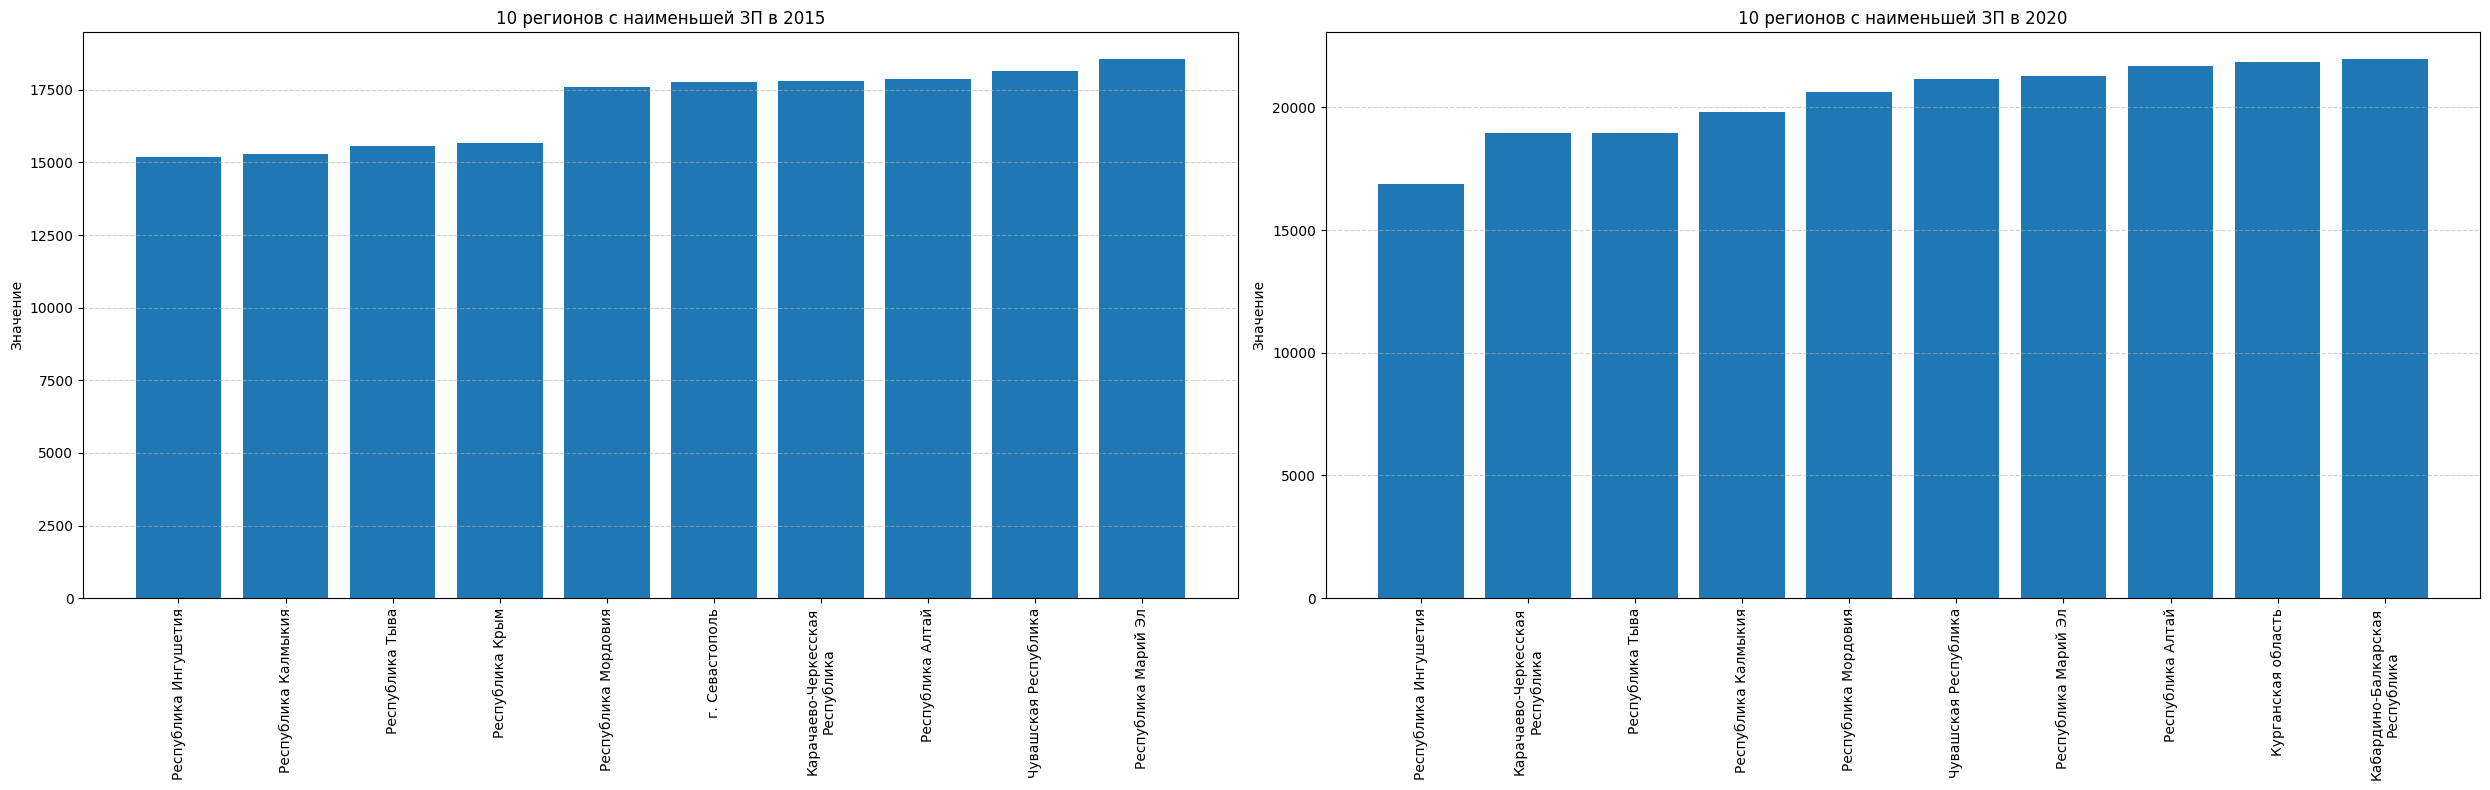

In [12]:
#построим график с 10 антитоп, то есть регионы с нименьшими показателями ЗП
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 8))

years = [2015, 2020]

for i, year in enumerate(years):
    # Берём 10 с наименьшими значениями
    bottom10 = data_cash.nsmallest(10, year).sort_values(year, ascending=True)
    
    axes[i].bar(
        x=bottom10["region"],
        height=bottom10[year],
        color="#1f77b4"
    )
    axes[i].set_title(f"10 регионов с наименьшей ЗП в {year}")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_ylabel("Значение")
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

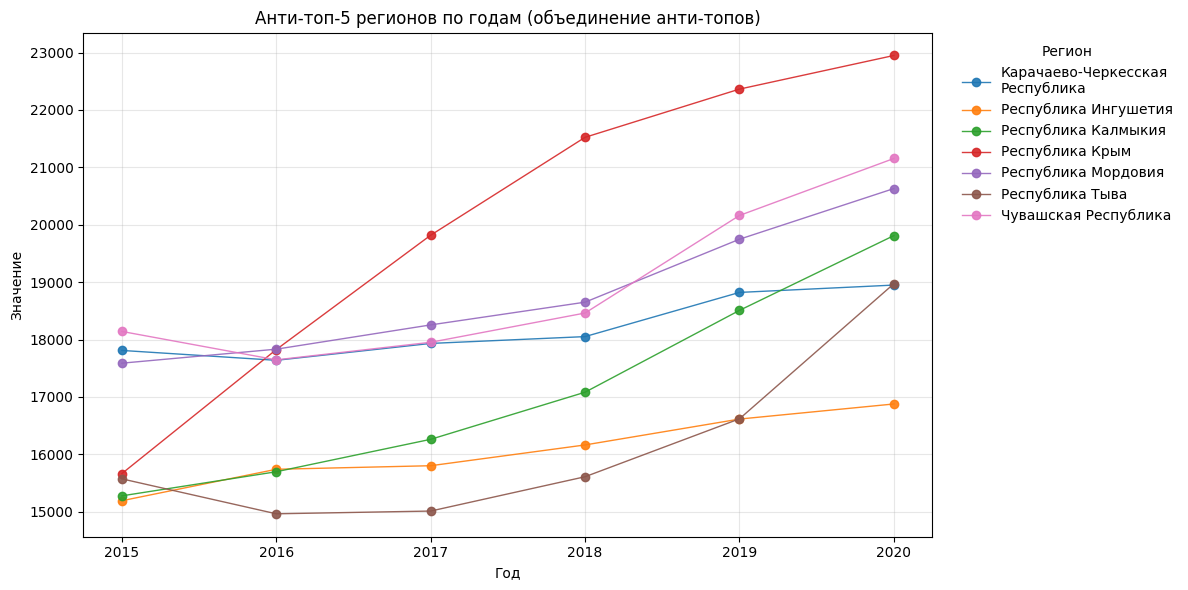

In [13]:


# годы сравнивнения
years = [2015, 2016, 2017, 2018, 2019, 2020]

# найдём анти-топ-10 по каждому году
bottom_sets = []
for y in years:
    bottom10 = data_cash.nsmallest(5, y)["region"]
    bottom_sets.append(set(bottom10))

# объединим все регионы, которые хоть раз были в анти-топе
anti_regions = sorted(set().union(*bottom_sets))

# подготовим данные в long-формат для удобного построения
year_cols = [str(y) for y in years]  # приведём имена столбцов к строкам
df_plot = (
    data_cash[data_cash["region"].isin(anti_regions)]
    .rename(columns={y: str(y) for y in years})
    .melt(id_vars=["region"], value_vars=year_cols, var_name="year", value_name="value")
)
df_plot["year"] = df_plot["year"].astype(int)

# выведем график
plt.figure(figsize=(12, 6))
for reg, sub in df_plot.groupby("region"):
    sub = sub.sort_values("year")
    plt.plot(sub["year"], sub["value"], marker="o", linewidth=1, alpha=0.9, label=reg)

plt.title("Анти-топ-5 регионов по годам (объединение анти-топов)")
plt.xlabel("Год")
plt.ylabel("Значение")
plt.grid(True, alpha=0.3)
plt.xticks(years)
# Легенду вынесем за пределы графика, чтобы не мешала
plt.legend(title="Регион", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=1)
plt.tight_layout()
plt.show()


In [14]:
# для наглядности сгруппируем значения по регионам и выведем средние показатели
grouped_cash= (
    df_plot.groupby("region")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "cash_mean"})
)


print(grouped_cash.head(10))

                             region  cash_mean
0                   Республика Крым   20024.17
1              Чувашская Республика   18919.67
2               Республика Мордовия   18784.17
3  Карачаево-Черкесская\nРеспублика   18200.17
4               Республика Калмыкия   17105.67
5                   Республика Тыва   16124.17
6              Республика Ингушетия   16064.17


С 2015 по 2022 год 3 регионами с самыми низкими показателями стали:

* Республика Ингушения - ЗП практически не расла в эти годы.
* Республика Калмыкия - показатель рос, но все равно регион остался в тройке 
* Республика Тыва - показатель сначала даже упал, а потом начал расти



In [15]:
# приведем таблицу к лонг формату

year_cols = [c for c in data_cash.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) привести имена годовых колонок к строкам (для стабильного melt)
rename_map = {c: str(c) for c in year_cols}
cash_long = (
    data_cash
    .rename(columns=rename_map)
    .melt(
        id_vars=["region"],
        value_vars=[rename_map[c] for c in year_cols],  
        var_name="year",
        value_name="value"
    )
)
cash_long["year"] = cash_long["year"].astype(int)

print(cash_long.head(10))

                            region  year    value
0  Центральный\n федеральный округ  2015  38832.0
1             Белгородская область  2015  28043.0
2                 Брянская область  2015  23428.0
3             Владимирская область  2015  22712.0
4              Воронежская область  2015  29366.0
5               Ивановская область  2015  22297.0
6                Калужская область  2015  27434.0
7              Костромская область  2015  21939.0
8                  Курская область  2015  25330.0
9                 Липецкая область  2015  27087.0


In [16]:
# приведем название регионов в дата сете к формату для дальнейшего объединения
cash_long  = canon_region_df(cash_long, "region", region_map)

In [17]:
cash_long[cash_long["region"].str.contains("Арх", case=False, na=False)] 

,region,year,value
23,Архангельская область без НАО,2015,29716.0
116,Архангельская область без НАО,2016,29837.0
209,Архангельская область без НАО,2017,30707.0
302,Архангельская область без НАО,2018,32054.0
395,Архангельская область без НАО,2019,33874.0
488,Архангельская область без НАО,2020,34852.0


In [18]:
# сделаем таблицу со средними значениями

cash_mean= (
    cash_long.groupby("region")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "cash_mean"})
)

cash_mean

,region,cash_mean
0,Ямало-Ненецкий автономный округ,78070.50
1,Ненецкий автономный округ,76707.67
2,Чукотский Автономный Округ,75961.83
3,г. Москва,68295.00
4,Магаданская область,58826.83
...,...,...
88,Республика Мордовия,18784.17
89,Карачаево-Черкесская Республика,18200.17
90,Республика Калмыкия,17105.67
91,Республика Тыва,16124.17


In [19]:
 #загрузим датасет по детсткой смертности в сельской местности c 1990-2020
data_child_mortality_rural = pd.read_excel('data/child_mortality_rural_1990_2021.xlsx', skiprows=2)
data_child_mortality_rural.rename(columns={data_child_mortality_rural.columns[0]: "Регион"}, inplace=True)
data_child_mortality_rural = data_child_mortality_rural.drop(['Unnamed: 1', 'Unnamed: 2'], axis=1) # удалим столбцы "Пол" и "Тип населения", они не нужны 
data_child_mortality_rural.head(3)

,Регион,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Российская Федерация,11186.0,10943.0,10111.0,9840.0,9010.0,8582.0,7983.0,7701.0,7214.0,...,5463.0,5059.0,4681.0,4165.0,3568.0,3032.0,2521.0,2122.0,1916.0,1852.0
1,Центральный федеральный округ,1615.0,1550.0,1361.0,1426.0,1347.0,1321.0,1200.0,NaN,NaN,...,625.0,608.0,487.0,490.0,426.0,347.0,291.0,211.0,228.0,212.0
2,Белгородская область,103.0,92.0,75.0,79.0,80.0,72.0,72.0,67.0,61.0,...,43.0,48.0,41.0,42.0,36.0,34.0,33.0,16.0,22.0,20.0


In [20]:
# оставим только 2015 -2021 годы
data_cmr = data_child_mortality_rural.drop(['1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014'], axis=1)


In [21]:
data_cmr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регион  119 non-null    object 
 1   2015    97 non-null     float64
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
 7   2021    95 non-null     float64
dtypes: float64(7), object(1)
memory usage: 7.6+ KB


In [22]:
#  проверим на пропуски
data_cmr .isnull().mean() *100

Регион     0.000000
2015      18.487395
2016      19.327731
2017      19.327731
2018      19.327731
2019      19.327731
2020      19.327731
2021      20.168067
dtype: float64

In [23]:
# заполним пропуски средними значениями по региону

year_cols = [col for col in data_cmr.columns if str(col).isdigit()]

data_cmr[year_cols] = data_cmr[year_cols].apply(
    lambda row: row.fillna(round(row.mean()) if not pd.isna(row.mean()) else 0),
    axis=1
).astype(int)

data_cmr.isnull().mean() *100

Регион    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
dtype: float64

In [24]:
# проверим наличие суммарных значений по Тюменской области
data_cmr[data_cmr["Регион"].str.contains("Тюменская", case=False, na=False)]

,Регион,2015,2016,2017,2018,2019,2020,2021
71,Тюменская область,94,70,78,62,50,38,42
72,Ханты-Мансийский автономный округ ...,10,8,15,5,4,5,8
73,Ямало-Ненецкий автономный округ (Т...,22,16,22,13,17,10,16
74,Тюменская область (кроме Ханты-Ман...,62,46,41,44,29,23,17


In [25]:
# удалим сумарные по Арх Обл и Тюм Обл
mask_totals = data_cmr["Регион"].str.strip().isin([
    "Тюменская область",
    "Архангельская область",
    "Северо-Западный федеральный округ",
    "Центральный федеральный округ",
    "Российская Федерация",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Сибирский федеральный округ",
    "Южный федеральный округ (с 2010 года)",
    "Южный федеральный округ (по 2009 год)",
    "Южный федеральный округ (с 2010 года)",
    "Южный федеральный округ (с 29.07.2016)",
    "Уральский федеральный округ",
    "Дальневосточный федеральный округ",
    "Крымский федеральный округ"
    
])

data_cmr = data_cmr[~mask_totals].reset_index(drop=True)

In [26]:
# проверим наличие дубликатов

dubl(data_cmr)

Число найденных дубликатов: 0


In [27]:
# приведем названия регионов в дата сеет к формату для дальнейшего объединения
data_cmr  = canon_region_df(data_cmr, "Регион", region_map)

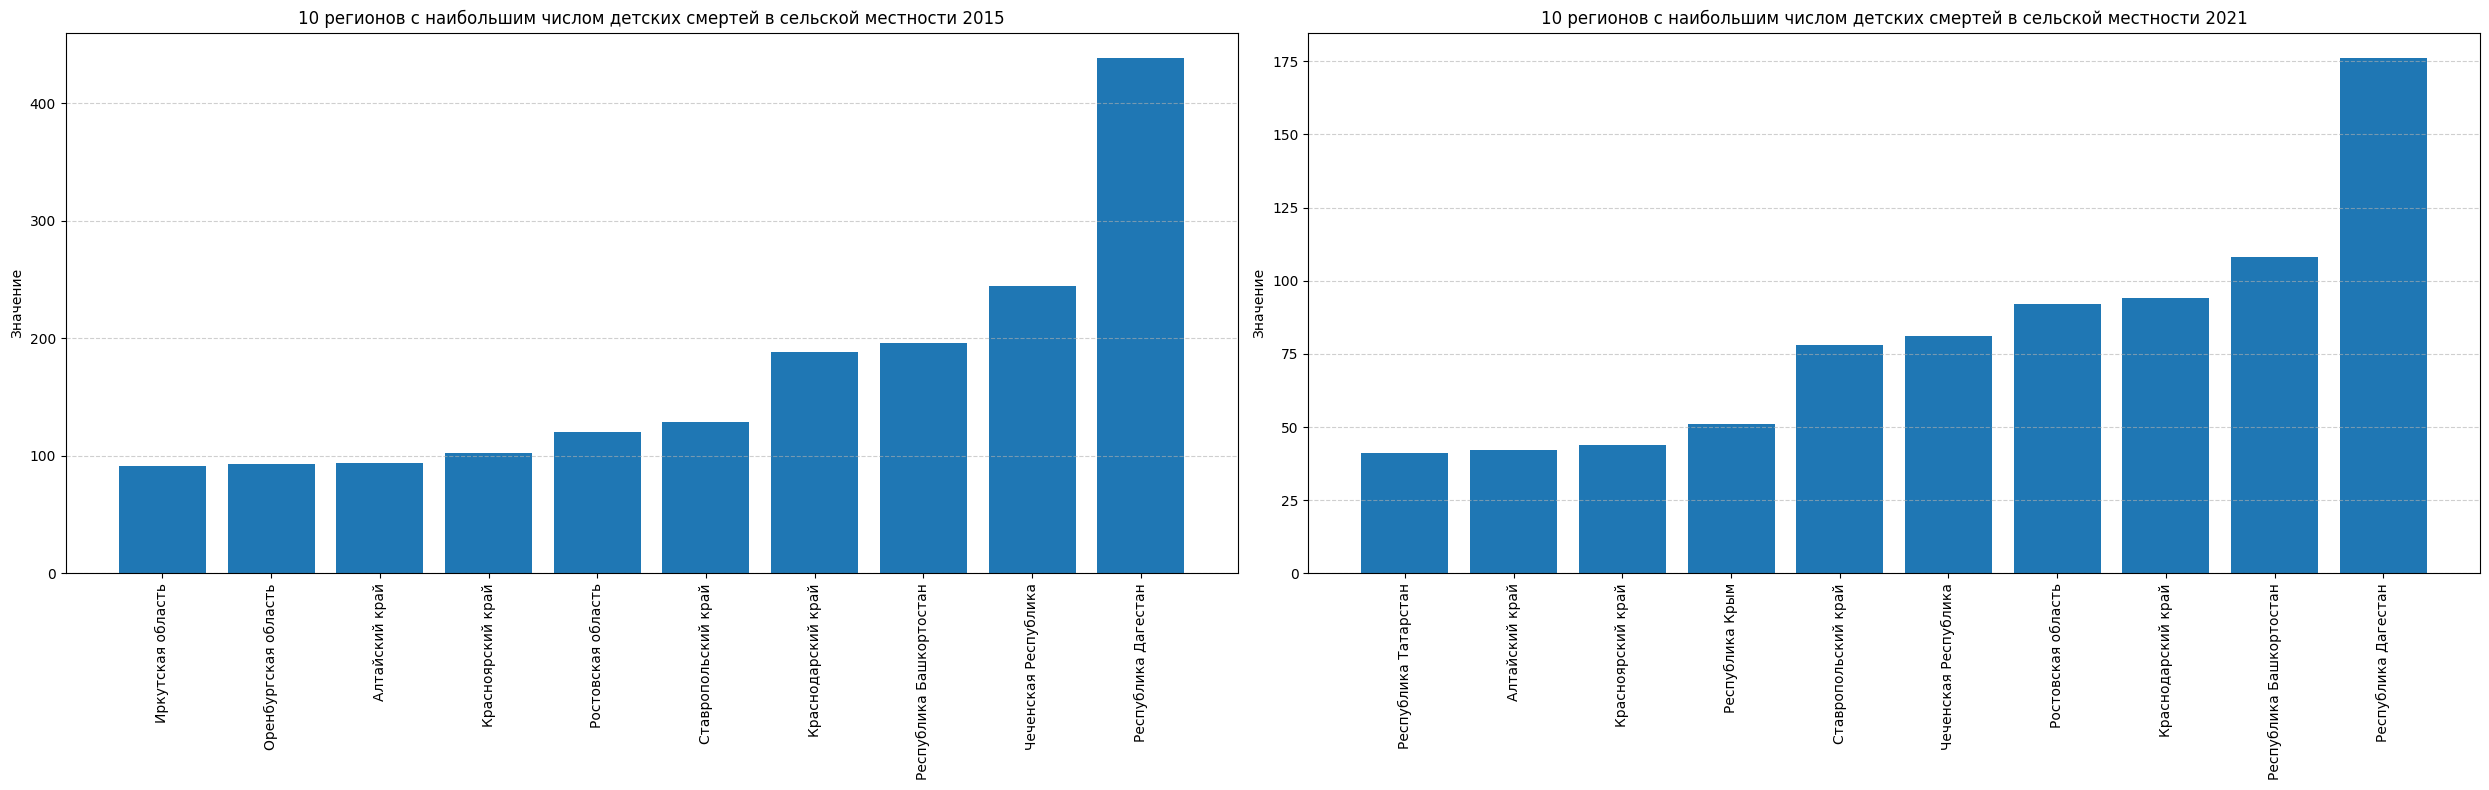

In [28]:
#построим график с 10 антитопами, то есть регионы с наибольшим числом детских смертей
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 8))

years = ['2015', '2021']

for i, year in enumerate(years):
    # Берём 10 с наибольшие значениями
    bottom10 = data_cmr.nlargest(10, year).sort_values(year, ascending=True)
    
    axes[i].bar(
        x=bottom10["Регион"],
        height=bottom10[year],
        color="#1f77b4"
    )
    axes[i].set_title(f"10 регионов с наибольшим числом детских смертей в сельской местности {year}")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_ylabel("Значение")
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

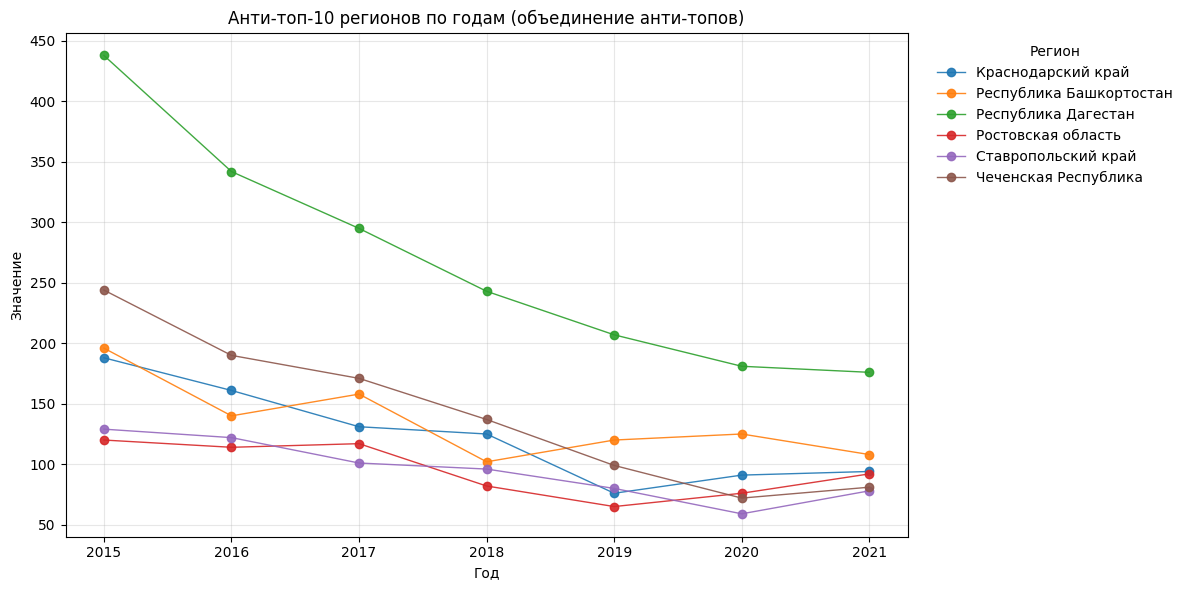

In [29]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]  # числа, не строки

# найдём анти-топ-10 по каждому году
bottom_sets = []
for y in years:
    bottom10 = data_cmr.nlargest(5, str(y))["Регион"]  # здесь приводим к str, т.к. имена колонок строковые
    bottom_sets.append(set(bottom10))

# регионы, которые хоть раз были в анти-топе
anti_regions = sorted(set().union(*bottom_sets))

# переводим таблицу в long-формат
year_cols = [str(y) for y in years]
df_plot = (
    data_cmr[data_cmr["Регион"].isin(anti_regions)]
    .rename(columns={y: str(y) for y in years})
    .melt(id_vars=["Регион"], value_vars=year_cols, var_name="year", value_name="value")
)
df_plot["year"] = df_plot["year"].astype(int)

# строим график
plt.figure(figsize=(12, 6))
for reg, sub in df_plot.groupby("Регион"):
    sub = sub.sort_values("year")
    plt.plot(sub["year"], sub["value"], marker="o", linewidth=1, alpha=0.9, label=reg)

plt.title("Анти-топ-10 регионов по годам (объединение анти-топов)")
plt.xlabel("Год")
plt.ylabel("Значение")
plt.grid(True, alpha=0.3)
plt.xticks(years)  # теперь это список чисел, всё ок
plt.legend(title="Регион", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=1)
plt.tight_layout()
plt.show()



In [30]:
# для наглядности сгруппируем значения по регионам и выведем средние показатели
grouped_cmr= (
    df_plot.groupby("Регион")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "cmr_mean"})
)


print(grouped_cmr.head(5))

                    Регион  cmr_mean
0      Республика Дагестан    268.86
1     Чеченская Республика    142.00
2  Республика Башкортостан    135.57
3       Краснодарский край    123.71
4       Ростовская область     95.14


Самые высокие показатели детской смертности в Респблике Дагестан и Чеченской республике.

In [31]:
# переведем дата сет в лонг формат и выведем по региону среднее значение

year_cols = [c for c in data_cmr.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) привести имена годовых колонок к строкам (для стабильного melt)
rename_map = {c: str(c) for c in year_cols}
cmr_long = (
    data_cmr
    .rename(columns=rename_map)
    .melt(
        id_vars=["Регион"],
        value_vars=[rename_map[c] for c in year_cols],  # теперь точно есть в DF
        var_name="year",
        value_name="value"
    )
)
cmr_long["year"] = cmr_long["year"].astype(int)

print(cmr_long.head(10))

                 Регион  year  value
0  Белгородская область  2015     42
1      Брянская область  2015     44
2  Владимирская область  2015     31
3   Воронежская область  2015     25
4    Ивановская область  2015     16
5     Калужская область  2015     25
6   Костромская область  2015     20
7       Курская область  2015     27
8      Липецкая область  2015     45
9    Московская область  2015     39


In [32]:
# сделаем таблицу со средними значениями

cmr_mean= (
    cmr_long.groupby("Регион")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "cmr_mean", "Регион": "region"})
)

cmr_mean

,region,cmr_mean
0,Республика Дагестан,268.86
1,Чеченская Республика,142.00
2,Республика Башкортостан,135.57
3,Краснодарский край,123.71
4,Ростовская область,95.14
...,...,...
97,Северный район,0.00
98,Усть-Ордынский Бурятский округ,0.00
99,Уральский федеральный округ,0.00
100,Северо-Западный Федеральный Округ,0.00


In [33]:
# загрузим датасет по детсткой смертности в городской местности
data_child_mortality_urban = pd.read_excel('data/child_mortality_urban_1990_2021.xlsx', skiprows=2) #
data_child_mortality_urban.rename(columns={data_child_mortality_urban.columns[0]: "Регион"}, inplace=True) #
data_child_mortality_urban = data_child_mortality_urban.drop(['Unnamed: 1', 'Unnamed: 2'], axis=1) # 
data_child_mortality_urban.head(3)

,Регион,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Российская Федерация,23902.0,21549.0,19097.0,18106.0,17131.0,16258.0,14842.0,14034.0,13883.0,...,10843.0,10418.0,9641.0,8499.0,7860.0,6545.0,5723.0,5206.0,4573.0,4664.0
1,Центральный федеральный округ,5317.0,4734.0,4175.0,3899.0,3871.0,3631.0,3254.0,NaN,NaN,...,2789.0,2735.0,2402.0,2228.0,2146.0,1785.0,1593.0,1409.0,1153.0,1192.0
2,Белгородская область,209.0,198.0,165.0,165.0,153.0,131.0,102.0,100.0,99.0,...,84.0,68.0,62.0,68.0,72.0,43.0,40.0,23.0,25.0,34.0


In [34]:
# оставим только 2015 -2021 годы
data_cmu = data_child_mortality_urban.drop(['1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014'], axis=1)


In [35]:
#  проверим на пропуски
data_cmu .isnull().mean() *100

Регион     0.000000
2015      18.487395
2016      19.327731
2017      19.327731
2018      19.327731
2019      19.327731
2020      19.327731
2021      20.168067
dtype: float64

In [36]:
# заполним пропуски средним по регионам
# заполним пропуски средними значениями по региону

year_cols = [col for col in data_cmu.columns if str(col).isdigit()]

data_cmu[year_cols] = data_cmu[year_cols].apply(
    lambda row: row.fillna(round(row.mean()) if not pd.isna(row.mean()) else 0),
    axis=1
).astype(int)

data_cmu.isnull().mean() *100



Регион    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
dtype: float64

In [37]:
# удалим сумарные по Арх Обл и Тюм Обл
mask_totals = data_cmu["Регион"].str.strip().isin([
    "Тюменская область",
    "Архангельская область",
    "Северо-Западный федеральный округ",
    "Центральный федеральный округ",
    "Российская Федерация",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Сибирский федеральный округ",
    "Южный федеральный округ (с 2010 года)",
    "Южный федеральный округ (по 2009 год)",
    "Южный федеральный округ (с 2010 года)",
    "Южный федеральный округ (с 29.07.2016)",
    "Уральский федеральный округ",
    "Дальневосточный федеральный округ",
    "Крымский федеральный округ"
    
])

data_cmu = data_cmu[~mask_totals].reset_index(drop=True)

In [38]:
# проверим наличие дубликатов

dubl(data_cmu)

Число найденных дубликатов: 0


In [39]:
# приведем регионы в дата сете к формату для дальнейшего объединения
data_cmu = canon_region_df(data_cmu, "Регион", region_map)

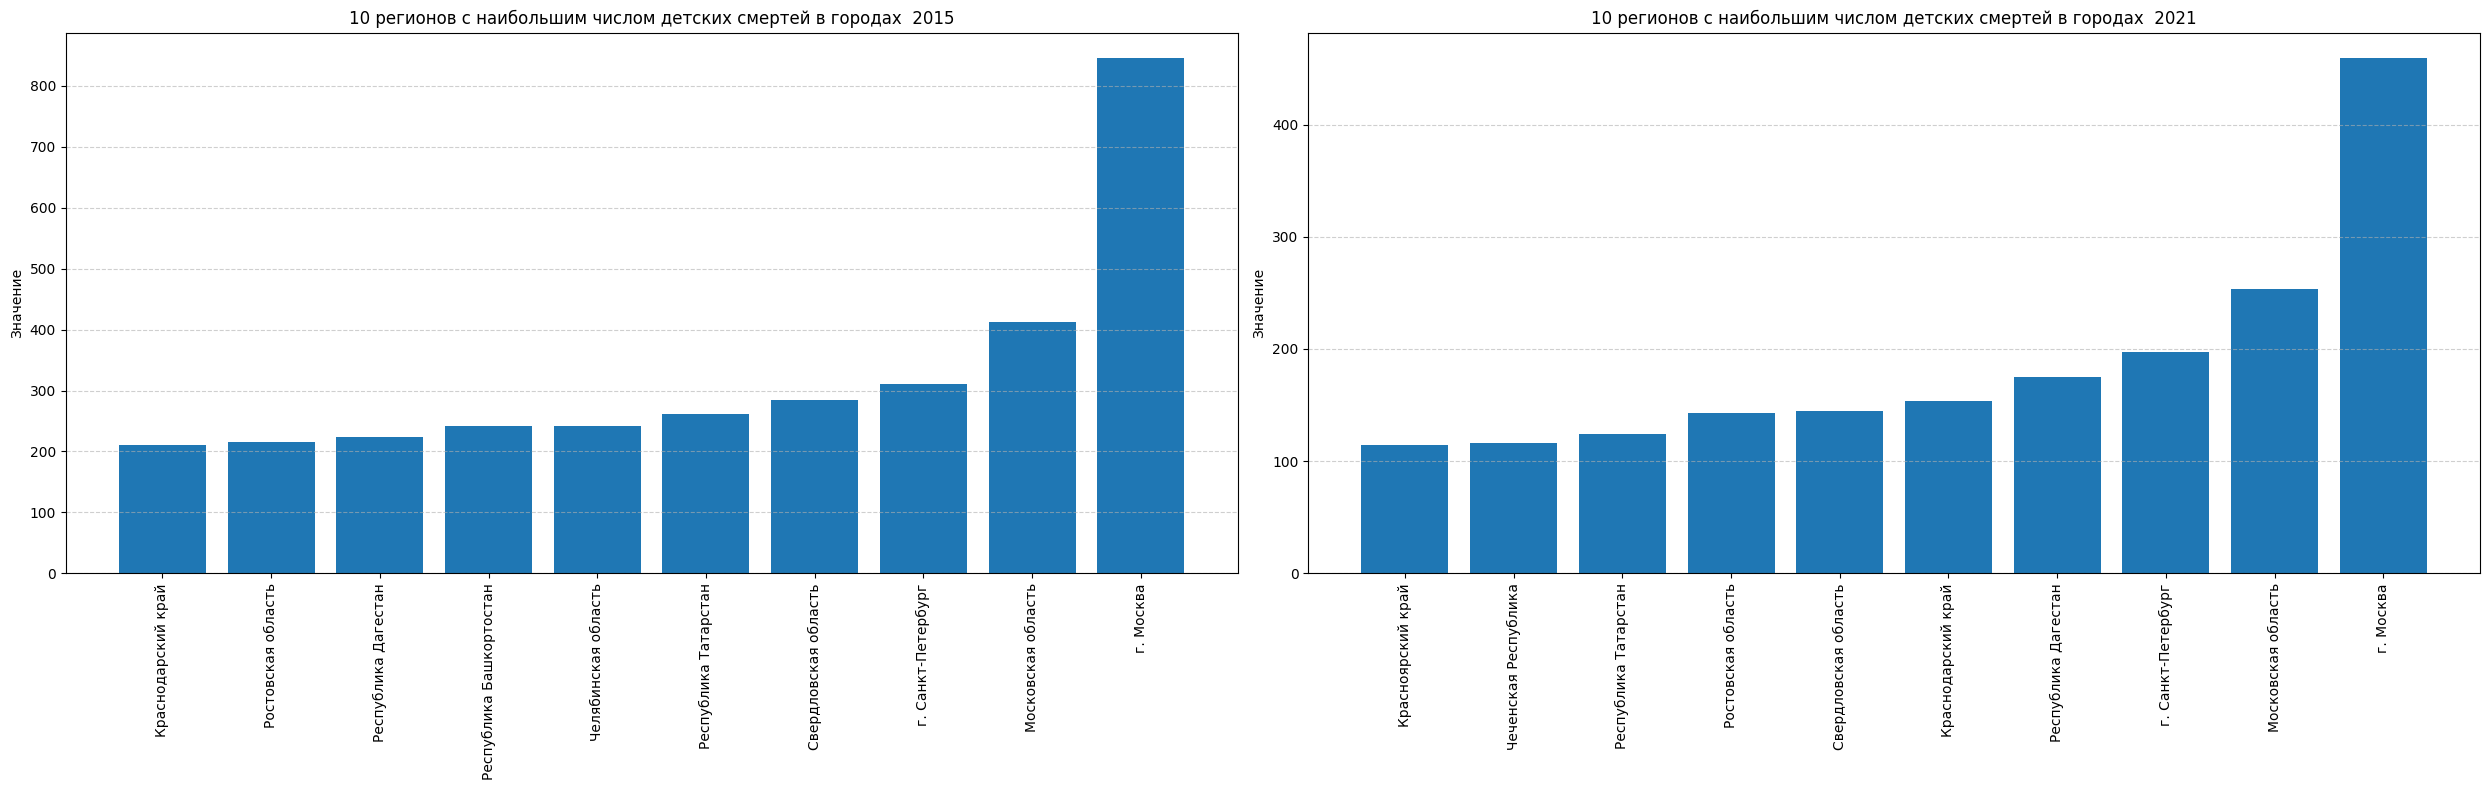

In [40]:
#построим график с 10 антитоп, то есть регионы с наибольшим числом детских смертей в городаж
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 8))

years = ['2015', '2021']

for i, year in enumerate(years):
    # Берём 10 с наибольшим значениями
    bottom10 = data_cmu.nlargest(10, year).sort_values(year, ascending=True)
    
    axes[i].bar(
        x=bottom10["Регион"],
        height=bottom10[year],
        color="#1f77b4"
    )
    axes[i].set_title(f"10 регионов с наибольшим числом детских смертей в городах  {year}")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_ylabel("Значение")
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

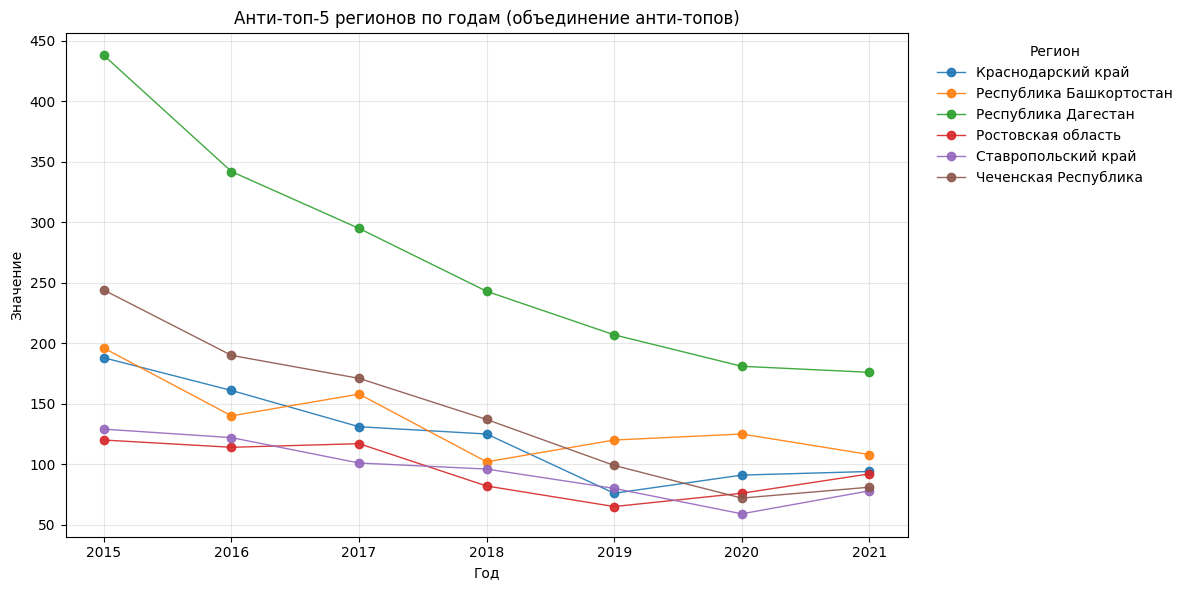

In [41]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]  # числа, не строки

# найдём анти-топ-5 по каждому году
bottom_sets = []
for y in years:
    bottom10 = data_cmu.nlargest(5, str(y))["Регион"]  # здесь приводим к str, т.к. имена колонок строковые
    bottom_sets.append(set(bottom10))

# регионы, которые хоть раз были в анти-топе
anti_regions = sorted(set().union(*bottom_sets))

# переводим таблицу в long-формат
year_cols = [str(y) for y in years]
df_plot_cmu = (
    data_cmu[data_cmu["Регион"].isin(anti_regions)]
    .rename(columns={y: str(y) for y in years})
    .melt(id_vars=["Регион"], value_vars=year_cols, var_name="year", value_name="value")
)
df_plot_cmu["year"] = df_plot_cmu["year"].astype(int)

# строим график
plt.figure(figsize=(12, 6))
for reg, sub in df_plot.groupby("Регион"):
    sub = sub.sort_values("year")
    plt.plot(sub["year"], sub["value"], marker="o", linewidth=1, alpha=0.9, label=reg)

plt.title("Анти-топ-5 регионов по годам (объединение анти-топов)")
plt.xlabel("Год")
plt.ylabel("Значение")
plt.grid(True, alpha=0.3)
plt.xticks(years)  # теперь это список чисел, всё ок
plt.legend(title="Регион", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=1)
plt.tight_layout()
plt.show()


In [42]:
# для наглядности сгруппируем значения по регионам и выведем средние показатели
grouped_cmu= (
    df_plot_cmu.groupby("Регион")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "cmu_mean", "Регион":"region"})
)


print(grouped_cmu.head(6))

                 region  cmu_mean
0             г. Москва    665.86
1    Московская область    311.00
2    г. Санкт-Петербург    240.57
3  Свердловская область    205.29
4  Республика Татарстан    177.14
5   Республика Дагестан    167.86


Самая высокая смертность в городах: Москва, Московской области и С-Петербург.

In [43]:
# переведем дата сет в лонг формат и выведем по региону среднее значение

year_cols = [c for c in data_cmu.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) привести имена годовых колонок к строкам (для стабильного melt)
rename_map = {c: str(c) for c in year_cols}
cmu_long = (
    data_cmu
    .rename(columns=rename_map)
    .melt(
        id_vars=["Регион"],
        value_vars=[rename_map[c] for c in year_cols],  # теперь точно есть в DF
        var_name="year",
        value_name="value"
    )
)
cmu_long["year"] = cmu_long["year"].astype(int)

print(cmr_long.head(10))

                 Регион  year  value
0  Белгородская область  2015     42
1      Брянская область  2015     44
2  Владимирская область  2015     31
3   Воронежская область  2015     25
4    Ивановская область  2015     16
5     Калужская область  2015     25
6   Костромская область  2015     20
7       Курская область  2015     27
8      Липецкая область  2015     45
9    Московская область  2015     39


In [44]:
# сделаем таблицу со средними значениями

cmu_mean= (
    cmu_long.groupby("Регион")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "cmu_mean", "Регион": "region"})
)

cmu_mean

,region,cmu_mean
0,г. Москва,665.86
1,Московская область,311.00
2,г. Санкт-Петербург,240.57
3,Свердловская область,205.29
4,Республика Татарстан,177.14
...,...,...
97,Усть-Ордынский Бурятский округ,0.00
98,Уральский федеральный округ,0.00
99,Северный район,0.00
100,Северо-Западный Федеральный Округ,0.00


In [45]:
# загрузим датасет по числу людей с инвалидностью в регионах с 2017 по 2022 годы
data_disabled = pd.read_csv('data/disabled_total_by_age_2017_2022.csv')
data_disabled.info(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6080 entries, 0 to 6079
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  6080 non-null   object 
 1   total   6074 non-null   float64
 2   18_30   6073 non-null   float64
 3   31_40   6074 non-null   float64
 4   41_50   6074 non-null   float64
 5   51_60   6074 non-null   float64
 6   60_     6074 non-null   float64
 7   date    6080 non-null   object 
dtypes: float64(6), object(2)
memory usage: 380.1+ KB


In [46]:

data_disabled.head(5)

,region,total,18_30,31_40,41_50,51_60,60_,date
0,Российская Федерация,11640873.0,550895.0,766054.0,1030652.0,2135436.0,7157836.0,2017-01-01
1,Центральный федеральный округ,3420310.0,118579.0,172662.0,257484.0,598102.0,2273483.0,2017-01-01
2,Белгородская область,223030.0,6318.0,10383.0,16596.0,37444.0,152289.0,2017-01-01
3,Брянская область,110418.0,4215.0,6568.0,10230.0,21481.0,67924.0,2017-01-01
4,Владимирская область,133352.0,4454.0,6811.0,9606.0,23322.0,89159.0,2017-01-01


In [47]:
# удалим суммарные федеральные округи
mask_totals = data_disabled["region"].str.strip().isin([
    "Северо-Западный федеральный округ",
    "Центральный федеральный округ",
    "Российская Федерация",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Сибирский федеральный округ",
    "Южный федеральный округ",
    "Уральский федеральный округ",
    "Дальневосточный федеральный округ",
    "Крымский федеральный округ"
    
])

data_disabled = data_disabled[~mask_totals].reset_index(drop=True)

In [48]:
data_disabled = canon_region_df(data_disabled, 'region', region_map)

In [49]:
# проверим наличие пропусков
data_disabled.isnull().mean() *100

region    0.000000
total     0.109012
18_30     0.127180
31_40     0.109012
41_50     0.109012
51_60     0.109012
60_       0.109012
date      0.000000
dtype: float64

In [50]:
dubl(data_disabled)

Число найденных дубликатов: 0


In [51]:
# сгруппируем по региону и выведем средние значения по возрастным группам за весь период
dis_grouped = (data_disabled.groupby('region').agg({
    "total":"mean",
    "18_30": "mean",
    "31_40": "mean",
    "41_50": "mean",
    "51_60": "mean",
    "60_":"mean"
})
    .round(2)   # округляем до целых
    .reset_index()
)



dis_grouped

,region,total,18_30,31_40,41_50,51_60,60_
0,Алтайский край,173039.83,7626.49,13418.02,15295.33,25707.40,110992.59
1,Амурская область,64625.03,3325.66,5248.72,6287.66,10531.98,39231.02
2,Архангельская область,84988.52,3060.48,5146.83,6899.94,12204.80,57676.47
3,Астраханская область,43462.77,2799.27,3981.23,4850.64,8200.56,23631.06
4,Белгородская область,202033.86,5353.17,9767.11,15291.14,31774.77,139847.67
...,...,...,...,...,...,...,...
81,Ярославская область,101446.30,2773.14,5100.50,7436.02,14258.34,71878.30
82,г. Байконур,834.06,97.21,89.09,132.67,250.53,266.08
83,г. Москва,1006747.45,29759.81,43911.58,65045.72,141911.84,726118.50
84,г. Санкт-Петербург,572592.86,13114.97,20130.83,28119.00,59009.39,452218.67


In [52]:
dis_grouped[dis_grouped['region'].str.contains("Архангельская", case=False, na=False)] 

,region,total,18_30,31_40,41_50,51_60,60_
2,Архангельская область,84988.52,3060.48,5146.83,6899.94,12204.8,57676.47


In [53]:
# так у нас в статистике фгуриют Архангельская обл без НАО и Тюменская обл без АО, переименуем регионы в дата сете
dis_grouped["region"] = dis_grouped["region"].replace({
    "Архангельская область": "Архангельская область без НАО",
    "Тюменская область": "Тюменская область без автономных округов"
})

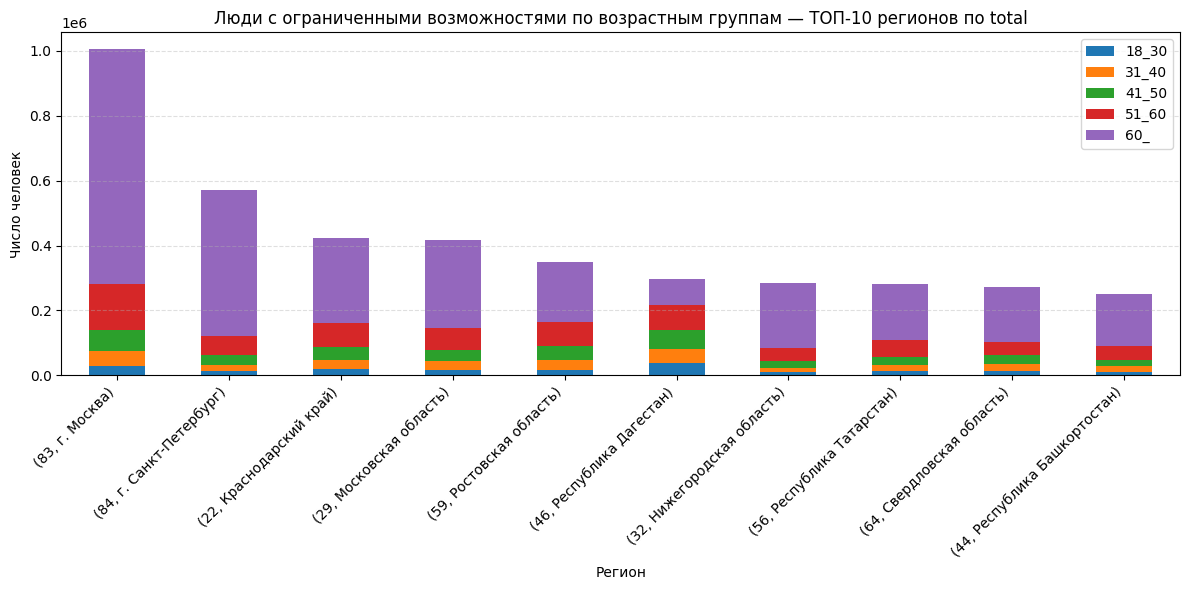

In [54]:
df = dis_grouped.copy()          # твой DataFrame (index=region)
df = df.reset_index().rename(columns={"index":"region"})  # на случай MultiIndex


# берём топ-10 по total
top10 = df.nlargest(10, "total").set_index("region")

age_cols = ["18_30", "31_40", "41_50", "51_60", "60_"]
ax = top10[age_cols].plot(kind="bar", stacked=True, figsize=(12,6))
ax.set_title("Люди с ограниченными возможностями по возрастным группам — ТОП-10 регионов по total")
ax.set_xlabel("Регион")
ax.set_ylabel("Число человек")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# правим подписи
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.tight_layout()
plt.show()

По всем регионам ТОП 10 большее всего людей с особенностями в группе 60+. Лидируют города Москва и СПб.

In [ ]:
dis_grouped = dis_grouped.drop('total', axis=1)

In [91]:
dis_grouped = dis_grouped.rename(columns={
    '18_30': '18_30_disab',
    '31_40': '31_40_disab',
    '41_50': '41_50_disab',
    '51_60': '51_60_disab',
    '60_': 'over_60_disab'
})

In [132]:
# сведения о заболеваемости алкоголизмом и наркоманией, на 100 тыс. населения (2005–2018):
path = "data/drug_alco.xlsx"
df1_alco = pd.read_excel(path, sheet_name=0)  # первый лист
df2_alco = pd.read_excel(path, sheet_name=1)  # второй лист
df3_drug = pd.read_excel(path, sheet_name=2)  # третий лист
df4_drug = pd.read_excel(path, sheet_name=3)  # четвертый лист


In [134]:
# приведем регионы к нужному формату
df1_alco = canon_region_df(df1_alco, "region", region_map)
df2_alco = canon_region_df(df2_alco, "region", region_map)
df3_drug = canon_region_df(df3_drug, "region", region_map)
df4_drug = canon_region_df(df4_drug, "region", region_map)

In [136]:
# получим уникальные регионы в каждом датасете
regions1 = set(df1_alco["region"].dropna().unique())
regions2 = set(df2_alco["region"].dropna().unique())

# разницы
only_in_df1 = regions1 - regions2
only_in_df2 = regions2 - regions1

print("Есть только в df1_alco:", only_in_df1)
print("Есть только в df2_alco:", only_in_df2)

Есть только в df1_alco: {'Архангельская область', 'Тюменская область'}
Есть только в df2_alco: {'Тюменская область без автономных округов', 'Главное медицинское управление Управления делами Президента Российской Федерации', 'Республика Крым', 'г. Севастополь', 'Архангельская область без НАО'}


In [135]:
# получим уникальные регионы в каждом датасете
regions3 = set(df3_drug["region"].dropna().unique())
regions4 = set(df4_drug["region"].dropna().unique())

# разницы
only_in_df3 = regions3 - regions4
only_in_df4 = regions4 - regions3

print("Есть только в df3_drug:", only_in_df3)
print("Есть только в df4_drug:", only_in_df4)

Есть только в df3_drug: {'Архангельская область', 'Тюменская область'}
Есть только в df4_drug: {'Тюменская область без автономных округов', 'Главное медицинское управление Управления делами Президента Российской Федерации', 'Республика Крым', 'г. Севастополь', 'Архангельская область без НАО'}


Перед объединением приведем Названия регионов Архангельская область, Тюменская область к единому формати, чтобы в дальнейшем не возникало проблем с пропусками.

In [137]:
# переименуем 
rename_map = {
    "Архангельская область": "Архангельская область без НАО",
    "Тюменская область": "Тюменская область без автономных округов",
}

df1_alco["region"] = df1_alco["region"].replace(rename_map)
df3_drug["region"] = df3_drug["region"].replace(rename_map)

In [138]:
# объединяем 2 листа алко
data_alco= pd.merge(
    df1_alco, 
    df2_alco, 
    on="region",      # Объединяем по колонке 'region'
    how="outer"     # outer — чтобы остались все регионы из обоих фреймов
)

In [139]:
data_alco.head()

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Российская Федерация,147.4,135.3,123.1,122.2,112.5,108.5,96.7,85.8,78.3,74.6,70.9,64.9,53.2,51.6
1,Центральный Федеральный Округ,141.5,131.1,120.3,119.8,109.6,103.3,86.4,80.0,72.9,69.1,64.1,55.3,46.2,44.9
2,Белгородская область,99.6,93.2,84.0,92.3,94.3,86.4,72.6,74.8,66.9,56.8,50.7,46.1,45.2,41.3
3,Брянская область,243.8,231.8,242.0,225.8,180.2,180.6,133.2,134.4,130.2,120.6,102.5,107.9,92.2,82.2
4,Владимирская область,178.3,161.5,147.1,145.0,140.5,135.0,120.8,88.8,94.1,87.7,81.7,75.7,65.3,66.5


In [140]:
# объединяем 2 листа драгс
data_drug= pd.merge(
    df3_drug, 
    df4_drug, 
    on="region",      # Объединяем по колонке 'region'
    how="outer"     # outer — чтобы остались все регионы из обоих фреймов
)

In [141]:
# посмотрим пропуски
cols_null_percent = data_alco.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

2014    21.052632
2015    21.052632
2016    21.052632
2005     3.157895
2006     3.157895
2007     3.157895
2008     3.157895
2009     3.157895
2010     3.157895
2011     3.157895
2012     3.157895
2013     3.157895
dtype: float64

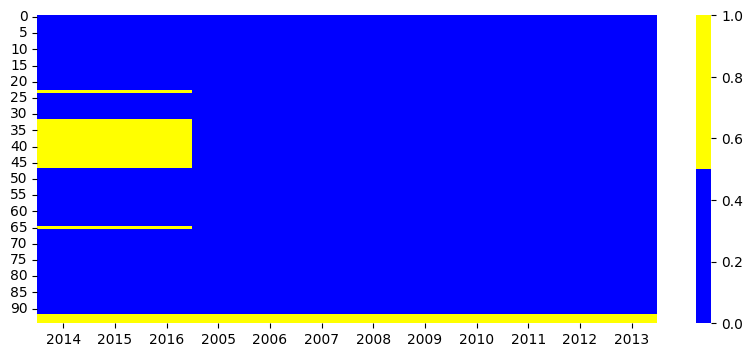

In [142]:
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(10, 4))
cols = cols_with_null.index
ax = sns.heatmap(
    data_alco[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [143]:
data_alco.tail()

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
90,Еврейская автономная область,167.3,193.5,180.0,253.9,230.0,250.8,199.1,119.8,112.9,124.7,125.3,137.9,118.9,87
91,Чукотский Автономный Округ,847.5,552.4,549.9,527.1,422.0,615.3,409.2,409.9,303.3,375.9,488.7,331.0,254.1,208.7
92,Республика Крым,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.3,57.6
93,г. Севастополь,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.6,90
94,Главное медицинское управление Управления дела...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-


In [144]:
# проверим наличие суммарных значений по Тюменской области
data_alco[data_alco["region"].str.contains("Тюменская", case=False, na=False)]

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
65,Тюменская область без автономных округов,163.1,166.5,152.1,149.8,133.3,129.7,115.6,89.4,65.6,NaN,NaN,NaN,63.2,61.2


In [145]:
# удалим ненужные строки
mask_totals = data_alco["region"].str.strip().isin([
    "Главное медицинское управление Управления делами Президента Российской Федерации",

])

data_alco= data_alco[~mask_totals].reset_index(drop=True)

data_alco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  94 non-null     object 
 1   2005    92 non-null     float64
 2   2006    92 non-null     float64
 3   2007    92 non-null     float64
 4   2008    92 non-null     float64
 5   2009    92 non-null     float64
 6   2010    92 non-null     float64
 7   2011    92 non-null     float64
 8   2012    92 non-null     float64
 9   2013    92 non-null     float64
 10  2014    75 non-null     float64
 11  2015    75 non-null     float64
 12  2016    75 non-null     float64
 13  2017    94 non-null     object 
 14  2018    94 non-null     object 
dtypes: float64(12), object(3)
memory usage: 11.1+ KB


In [146]:
# переведем 2017 и 2018 годы из  object  в float64
data_alco[[2017, 2018]] = data_alco[[2017, 2018]].astype("float64")
data_alco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  94 non-null     object 
 1   2005    92 non-null     float64
 2   2006    92 non-null     float64
 3   2007    92 non-null     float64
 4   2008    92 non-null     float64
 5   2009    92 non-null     float64
 6   2010    92 non-null     float64
 7   2011    92 non-null     float64
 8   2012    92 non-null     float64
 9   2013    92 non-null     float64
 10  2014    75 non-null     float64
 11  2015    75 non-null     float64
 12  2016    75 non-null     float64
 13  2017    94 non-null     float64
 14  2018    94 non-null     float64
dtypes: float64(14), object(1)
memory usage: 11.1+ KB


In [147]:
# посмотрим пропуски наркотики
cols_null_percent = data_drug.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

2014    21.052632
2015    21.052632
2016    21.052632
2005     3.157895
2006     3.157895
2007     3.157895
2008     3.157895
2009     3.157895
2010     3.157895
2011     3.157895
2012     3.157895
2013     3.157895
dtype: float64

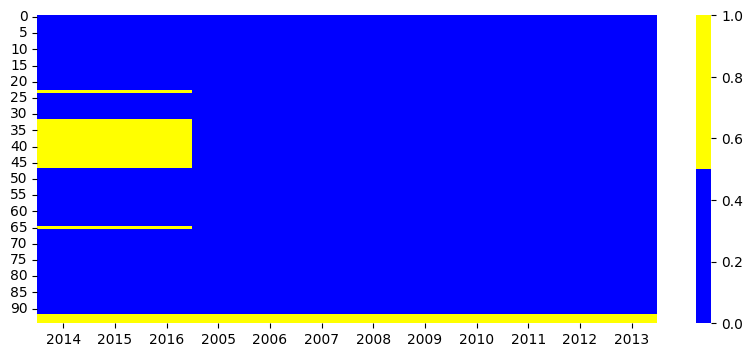

In [148]:
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(10, 4))
cols = cols_with_null.index
ax = sns.heatmap(
    data_drug[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [149]:
data_drug.tail()

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
90,Еврейская автономная область,28.2,15.0,15.0,28.0,16.7,25.4,27.8,29.8,27.2,25.5,37.4,66.8,73,65.4
91,Чукотский Автономный Округ,2.0,4.0,4.0,2.0,14.3,0.0,4.0,0.0,3.9,0.0,0.0,0.0,2,0
92,Республика Крым,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.8,14.6
93,г. Севастополь,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.9,25.4
94,Главное медицинское управление Управления дела...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-


In [150]:
# удалим ненужные строки
mask_totals = data_drug["region"].str.strip().isin([
    "Главное медицинское управление Управления делами Президента Российской Федерации",

])

data_drug= data_drug[~mask_totals].reset_index(drop=True)

data_drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  94 non-null     object 
 1   2005    92 non-null     float64
 2   2006    92 non-null     float64
 3   2007    92 non-null     float64
 4   2008    92 non-null     float64
 5   2009    92 non-null     float64
 6   2010    92 non-null     float64
 7   2011    92 non-null     float64
 8   2012    92 non-null     float64
 9   2013    92 non-null     float64
 10  2014    75 non-null     float64
 11  2015    75 non-null     float64
 12  2016    75 non-null     float64
 13  2017    94 non-null     object 
 14  2018    94 non-null     object 
dtypes: float64(12), object(3)
memory usage: 11.1+ KB


In [151]:
# переведем 2017 и 2018 годы из  object  в float64
data_drug[[2017, 2018]] = data_drug[[2017, 2018]].astype("float64")
data_drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  94 non-null     object 
 1   2005    92 non-null     float64
 2   2006    92 non-null     float64
 3   2007    92 non-null     float64
 4   2008    92 non-null     float64
 5   2009    92 non-null     float64
 6   2010    92 non-null     float64
 7   2011    92 non-null     float64
 8   2012    92 non-null     float64
 9   2013    92 non-null     float64
 10  2014    75 non-null     float64
 11  2015    75 non-null     float64
 12  2016    75 non-null     float64
 13  2017    94 non-null     float64
 14  2018    94 non-null     float64
dtypes: float64(14), object(1)
memory usage: 11.1+ KB


Так как у нас будет итоговый дата сет по накоительной сумме, не будем заполнят пропуски. Удалим только дата последнюю строку.

In [152]:
data_drug.tail()

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
89,Сахалинская область,36.5,34.8,34.8,36.8,34.9,39.5,34.8,27.7,11.8,26.0,24.6,15.4,19.8,18.4
90,Еврейская автономная область,28.2,15.0,15.0,28.0,16.7,25.4,27.8,29.8,27.2,25.5,37.4,66.8,73.0,65.4
91,Чукотский Автономный Округ,2.0,4.0,4.0,2.0,14.3,0.0,4.0,0.0,3.9,0.0,0.0,0.0,2.0,0.0
92,Республика Крым,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.8,14.6
93,г. Севастополь,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.9,25.4


Заменим NaN на 0 и создадим окончательный датасет с накопительной суммой.

In [153]:

# находим колонки с годами (числовые названия)
year_cols = [col for col in data_drug.columns if str(col).isdigit()]

# считаем сумму по строкам (только по годам)
data_drug["drug_sum"] = data_drug[year_cols].sum(axis=1, skipna=True)

# оставляем только два признака: регион и сумма
data_drug_sum = data_drug[["region", "drug_sum"]]


drug_sorted = data_drug_sum.sort_values(by='drug_sum', ascending=False)
drug_sorted

,region,drug_sum
90,Еврейская автономная область,481.2
85,Приморский край,462.2
76,Кемеровская область,450.7
75,Иркутская область,401.5
64,Свердловская область,400.4
...,...,...
23,Архангельская область без НАО,43.9
53,Чувашская Республика,38.2
41,Республика Ингушетия,36.5
91,Чукотский Автономный Округ,36.2


In [154]:
data_alco.tail()

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
89,Сахалинская область,619.5,506.2,482.4,329.7,302.5,338.3,281.8,246.1,216.3,159.5,156.6,141.4,113.1,106.1
90,Еврейская автономная область,167.3,193.5,180.0,253.9,230.0,250.8,199.1,119.8,112.9,124.7,125.3,137.9,118.9,87.0
91,Чукотский Автономный Округ,847.5,552.4,549.9,527.1,422.0,615.3,409.2,409.9,303.3,375.9,488.7,331.0,254.1,208.7
92,Республика Крым,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.3,57.6
93,г. Севастополь,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.6,90.0


In [155]:

# находим колонки с годами (числовые названия)
year_cols = [col for col in data_alco.columns if str(col).isdigit()]

# считаем сумму по строкам (только по годам)
data_alco["alco_sum"] = data_alco[year_cols].sum(axis=1, skipna=True)

# оставляем только два признака: регион и сумма
data_alco_sum = data_alco[["region", "alco_sum"]]



alco_sorted = data_alco_sum.sort_values(by='alco_sum', ascending=False)
alco_sorted.head()

,region,alco_sum
91,Чукотский Автономный Округ,6295.0
88,Магаданская область,4449.2
89,Сахалинская область,3999.5
24,Ненецкий автономный округ,3209.9
82,Республика Саха (Якутия),3165.5


In [80]:
# приведем название регионов к стандарту
data_alco_sum = canon_region_df(data_alco_sum, 'region', region_map)
data_drug_sum = canon_region_df(data_drug_sum, 'region', region_map)

In [156]:
data_alco_sum[data_drug_sum['region'].str.contains("Арх", case=False, na=False)] 

,region,alco_sum
23,Архангельская область без НАО,978.8


In [157]:
# валовой региональный продукт на душу населения,в рублях
data_gross_prod = pd.read_excel('data/gross_regional_product_1996_2020.xlsx', skiprows=2)
data_gross_prod = data_gross_prod.rename(columns={data_gross_prod.columns[0]: "Регион"})
data_gross_prod.head(3)

,Регион,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Российская Федерация,12225.0,13938.4,15371.1,26200.6,39532.3,49474.8,60611.4,74840.5,97691.9,...,317515.3,348641.5,377006.0,405147.7,449097.9,505337.7,543065.9,614333.2,646144.1,640519.0
1,Центральный федеральный округ,NaN,NaN,16564.4,31118.7,48205.0,58851.5,75739.2,94244.6,121487.7,...,417288.1,451517.2,494482.7,536607.9,580706.6,663881.8,711031.6,792780.9,835858.8,854978.5
2,Белгородская область,9575.6,10792.2,12242.8,21398.0,27969.5,33126.7,41327.4,50271.4,75629.4,...,331010.0,354570.6,368874.8,400820.8,447619.7,501467.8,539720.5,588641.5,617426.5,646569.0


In [158]:
# посмотрим пропуски 
cols_null_percent = data_gross_prod.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

1996    19.801980
1997    19.801980
2019     4.950495
2018     4.950495
2017     4.950495
2016     4.950495
2015     4.950495
2020     4.950495
2012     3.960396
1998     3.960396
1999     3.960396
2000     3.960396
2001     3.960396
2010     3.960396
2011     3.960396
2013     2.970297
2014     2.970297
2004     2.970297
2005     2.970297
2009     2.970297
2003     2.970297
2007     2.970297
2006     2.970297
2008     2.970297
2002     1.980198
dtype: float64

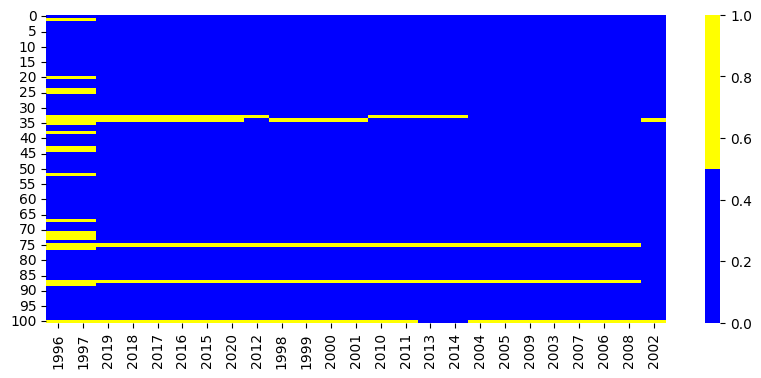

In [159]:
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(10, 4))
cols = cols_with_null.index
ax = sns.heatmap(
    data_gross_prod[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [160]:
#
print(data_gross_prod.iloc[87])

Регион        Дальневосточный федеральный округ
1996                                        NaN
1997                                        NaN
1998                                        NaN
1999                                        NaN
2000                                        NaN
2001                                        NaN
2002                                    70194.8
2003                                        NaN
2004                                        NaN
2005                                        NaN
2006                                        NaN
2007                                        NaN
2008                                        NaN
2009                                        NaN
2010                                        NaN
2011                                        NaN
2012                                        NaN
2013                                        NaN
2014                                        NaN
2015                                    

In [161]:
data_gross_prod[data_gross_prod["Регион"].str.contains("Тюменская", case=False, na=False)] 

,Регион,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
70,Тюменская область,49237.2,55035.5,58587.7,98130.1,176917.9,232236.3,275622.5,341146.7,467803.8,...,1198186.0,1327227.1,1402915.6,1485863.5,1626160.4,1683993.8,1930537.3,2393355.2,2384622.4,1934463.9
71,Ханты-Мансийский автономный округ ...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1575300.0,1719109.2,1715722.4,1782617.7,1947653.2,1912836.6,2155227.7,2715827.8,2733622.7,1994630.3
72,Ямало-Ненецкий автономный округ (Т...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1820301.3,2209803.4,2544898.0,3025745.6,3336453.4,3790547.2,4571566.9,5650999.3,5710467.4,5072483.6
73,Тюменская область (кроме Ханты-Ман...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,522064.8,532020.4,604921.2,564680.5,628098.5,659860.8,727930.9,872684.2,821610.6,757076.0


In [162]:
# оставим только данные с 2010 года
data_gp = data_gross_prod.drop(['1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010'], axis=1)



In [163]:
#  удалим все округа и Тюми Арх области, чтобы не мешали дальнейшему анализу по регионам
mask_totals = data_gp["Регион"].str.strip().isin([
    "Тюменская область",
    "Архангельская область",
    "Дальневосточный федеральный округ",
    "Крымский федеральный округ",
    "Российская Федерация",
    "Сибирский федеральный округ",
    "Южный федеральный округ (по 2009 год)",
    "Южный федеральный округ (с 2010 года)",
    "Южный федеральный округ (с 29.07.2016)",
    "Центральный федеральный округ",
    "Северо-Западный федеральный округ",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Уральский федеральный округ",
    
    
])

data_gp = data_gp[~mask_totals].reset_index(drop=True)

data_gp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регион  85 non-null     object 
 1   2011    85 non-null     float64
 2   2012    85 non-null     float64
 3   2013    85 non-null     float64
 4   2014    85 non-null     float64
 5   2015    85 non-null     float64
 6   2016    85 non-null     float64
 7   2017    85 non-null     float64
 8   2018    85 non-null     float64
 9   2019    85 non-null     float64
 10  2020    85 non-null     float64
dtypes: float64(10), object(1)
memory usage: 7.4+ KB


In [164]:
# проверим дубликаты

dubl(data_gp)

Число найденных дубликатов: 0


In [165]:
# приведем регионы к единому формату
data_gp = canon_region_df(data_gp, 'Регион', region_map)

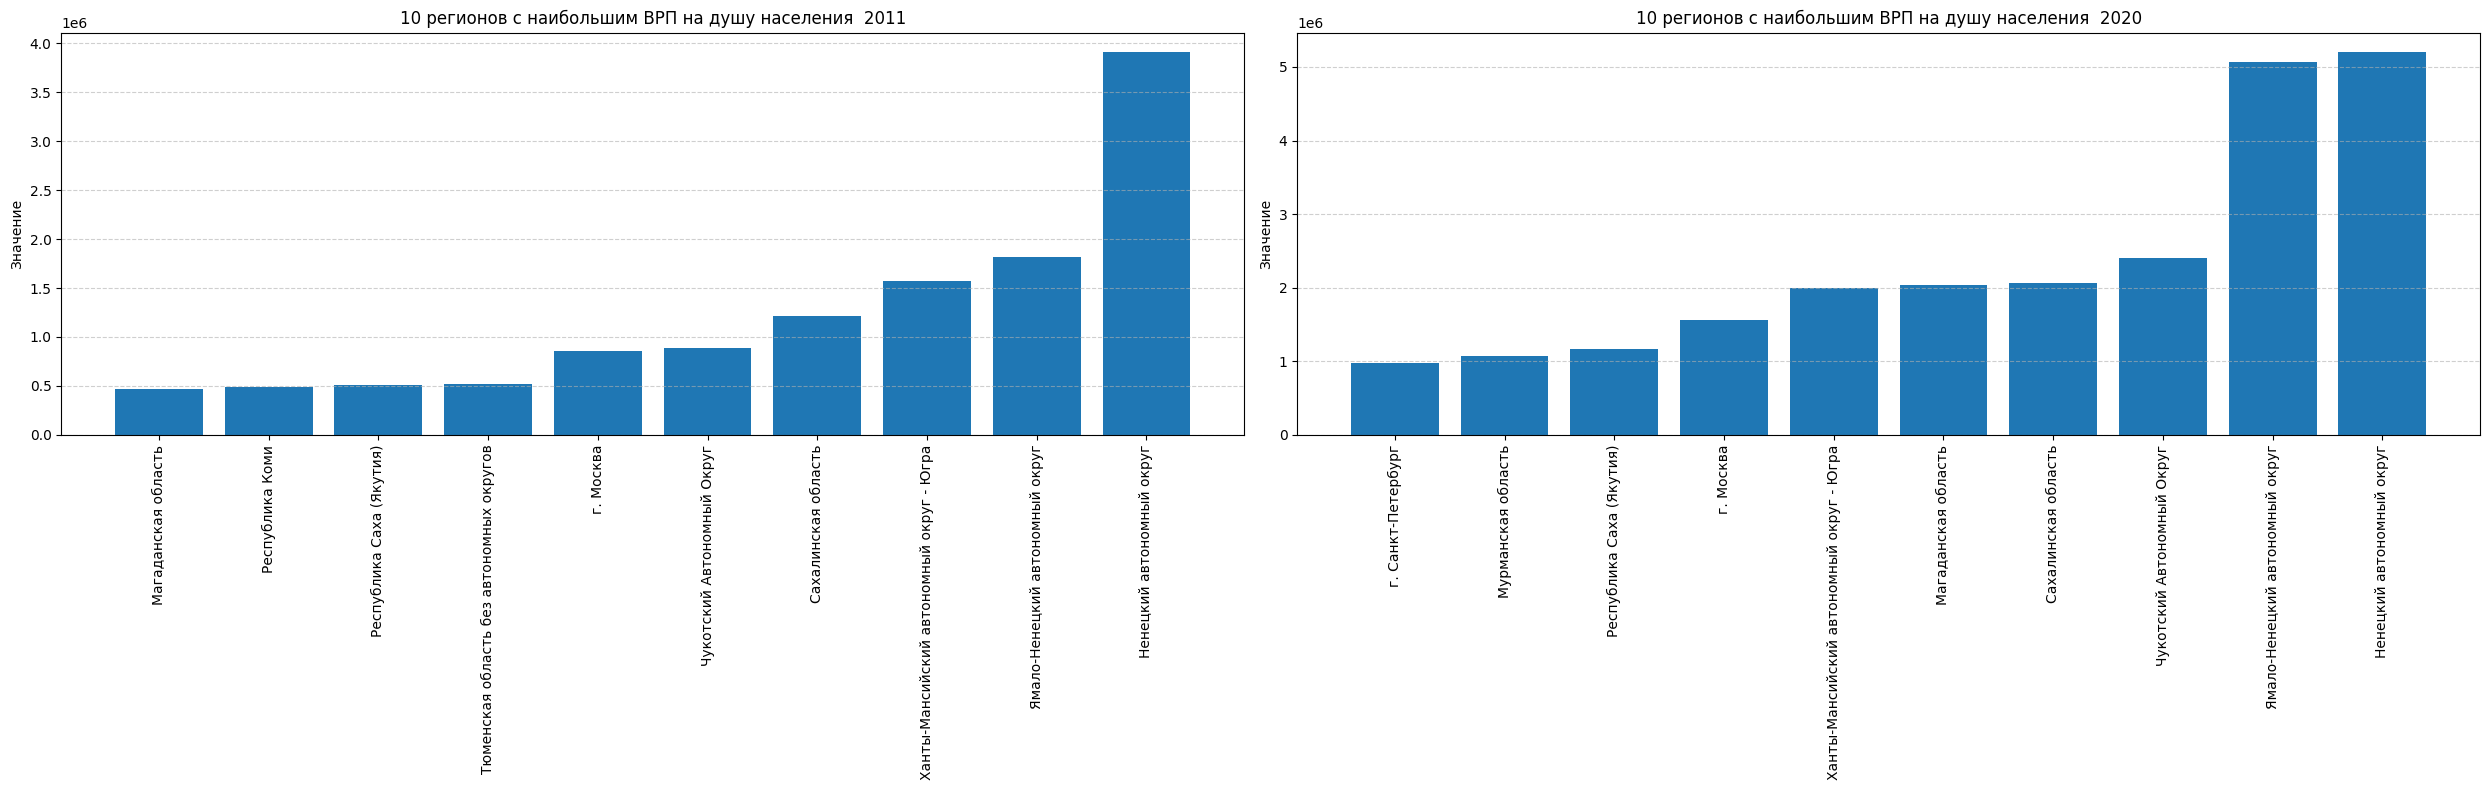

In [166]:
#построим график с 10 топ, то есть регионы с наибольшим числом ВРП на душу населения
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 8))

years = ['2011', '2020']

for i, year in enumerate(years):
    # Берём 10 с наибольшим значениями
    bottom10 = data_gp.nlargest(10, year).sort_values(year, ascending=True)
    
    axes[i].bar(
        x=bottom10["Регион"],
        height=bottom10[year],
        color="#1f77b4"
    )
    axes[i].set_title(f"10 регионов с наибольшим ВРП на душу населения  {year}")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_ylabel("Значение")
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

В 2011 однявный лидер - Ненецкий АО, а в 2020 2 - Ямало-Ненцкий АО и Ненецкий АО.

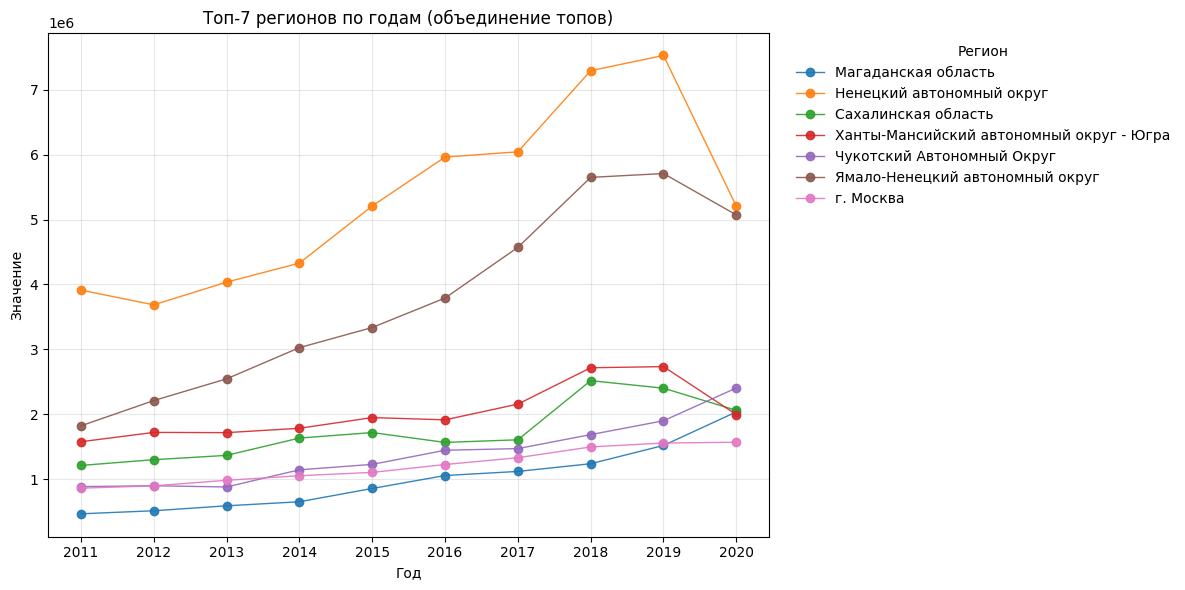

In [167]:
# найдем топ 5
years = [str(y) for y in range(2011, 2021)]
top_sets = []

# собираем топ-10 регионов по каждому году
for y in years:
    top10 = data_gp.nlargest(5, y)["Регион"]
    top_sets.append(set(top10))

# объединяем все регионы, которые хоть раз были в топ-10
top_regions = sorted(set().union(*top_sets))

# подготавливаем данные в long-формат
df_plot = (
    data_gp[data_gp["Регион"].isin(top_regions)]
    .melt(id_vars=["Регион"], value_vars=years, var_name="year", value_name="value")
)

# год -> int
df_plot["year"] = df_plot["year"].astype(int)

# рисуем график
plt.figure(figsize=(12, 6))
for reg, sub in df_plot.groupby("Регион"):
    sub = sub.sort_values("year")
    plt.plot(sub["year"], sub["value"], marker="o", linewidth=1, alpha=0.9, label=reg)

plt.title("Топ-7 регионов по годам (объединение топов)")
plt.xlabel("Год")
plt.ylabel("Значение")
plt.grid(True, alpha=0.3)
plt.xticks(range(2011, 2021))
plt.legend(title="Регион", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=1)
plt.tight_layout()
plt.show()


Общий график по годам показал нам, что Ненцкий АО бал лидером на протяжении 9 лет, но в 20 году показатель резко упал и практически сровнялся с ВРП Ямало-Ненецкого АО

In [168]:
data_gp 

,Регион,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Белгородская область,331010.0,354570.6,368874.8,400820.8,447619.7,501467.8,539720.5,588641.5,617426.5,646569.0
1,Брянская область,137187.1,164726.6,175865.0,196096.7,221080.0,258752.7,280630.1,304547.1,332442.8,347204.5
2,Владимирская область,181842.6,200456.4,216320.8,232757.6,262945.5,309713.7,325043.1,349856.4,394560.3,410443.6
3,Воронежская область,203575.5,241947.4,262578.3,308004.7,345566.8,354657.9,374125.7,408140.7,431037.0,459629.5
4,Ивановская область,121945.5,129448.3,151263.6,146032.6,174687.5,200504.4,208522.0,230325.5,249591.6,273821.5
...,...,...,...,...,...,...,...,...,...,...,...
80,Амурская область,273175.8,280023.9,258817.0,286282.6,343385.7,370192.4,373935.1,419905.2,521060.1,571362.1
81,Магаданская область,464112.9,511125.4,587477.4,649745.4,854561.5,1054274.8,1117517.3,1236274.4,1518066.7,2035007.0
82,Сахалинская область,1210003.9,1298440.0,1364874.7,1631919.0,1716734.4,1564707.9,1605079.4,2517125.0,2400858.1,2059206.5
83,Еврейская автономная область,225065.5,246301.3,224042.7,247666.9,266405.8,294021.2,338826.6,339068.1,355545.7,400340.5


In [169]:
# приведем таблицу к лонг формату, чтобы преобразовать

year_cols = [c for c in data_gp.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) привести имена годовых колонок к строкам (для стабильного melt)
rename_map = {c: str(c) for c in year_cols}
gp_long = (
    data_gp
    .rename(columns=rename_map)
    .melt(
        id_vars=["Регион"],
        value_vars=[rename_map[c] for c in year_cols], 
        var_name="year",
        value_name="value"
    )
)
gp_long["year"] = gp_long["year"].astype(int)

print(gp_long.head(10))

                 Регион  year     value
0  Белгородская область  2011  331010.0
1      Брянская область  2011  137187.1
2  Владимирская область  2011  181842.6
3   Воронежская область  2011  203575.5
4    Ивановская область  2011  121945.5
5     Калужская область  2011  232722.0
6   Костромская область  2011  175626.6
7       Курская область  2011  203676.0
8      Липецкая область  2011  246213.8
9    Московская область  2011  304342.6


In [170]:
# сделаем таблицу со средними значениями

gp_mean= (
    gp_long.groupby("Регион")["value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"value": "vrp_mean"})
    .rename(columns={"Регион": "region"})
)

gp_mean

,region,vrp_mean
0,Ненецкий автономный округ,5321754.28
1,Ямало-Ненецкий автономный округ,3773326.61
2,Ханты-Мансийский автономный округ - Югра,2025254.76
3,Сахалинская область,1736894.89
4,Чукотский Автономный Округ,1392794.65
...,...,...
80,Кабардино-Балкарская Республика,158583.52
81,г. Севастополь,152156.79
82,Республика Крым,137603.59
83,Чеченская Республика,124347.60


In [171]:
# загрузим дата сет с характеристиками жилищных условий домохозяйств. 
# В таблице 2 листа, 1 - Характеристика жилищных условий домохозяйств, % от всех домохозяйств, 
# 2 - Оценка домохозяйствами состояния занимаемого ими жилого помещения, % от всех домохозяйств
# будем работать с 1 листом, так как в нем более существенные данные
data_housing = pd.read_excel('data/housing_2020.xlsx')

data_housing.head(3)

,Регион,"Число домохозяйств, проживающих во всех типах жилых помещений","в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности","в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность","в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность",затруднились ответить,Размер общей площади в расчете на члена домохозяйства,Размер жилой площади в расчете на члена домохозяйства,Число жилых комнат в расчете на одно домохозяйство
0,Российская Федерация,100.0,80.7,15.4,3.8,0.1,24.2,16.9,2.4
1,Центральный федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Белгородская область,100.0,86.3,11.7,2.0,0.0,25.1,17.8,2.6


In [172]:
# удалим пустые строки 
data_housing = data_housing.dropna()
data_housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 93
Data columns (total 9 columns):
 #   Column                                                                                         Non-Null Count  Dtype  
---  ------                                                                                         --------------  -----  
 0   Регион                                                                                         86 non-null     object 
 1   Число домохозяйств, проживающих во всех типах жилых помещений                                  86 non-null     float64
 2   в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности            86 non-null     float64
 3   в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность  86 non-null     float64
 4   в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность       86 non-null     float64
 5   затруднились ответить         

In [173]:
# удалим пустые строки  удалим столбец с 100% показателям, нам он не нужен

data_housing = data_housing.drop('Число домохозяйств, проживающих во всех типах жилых помещений', axis=1)

In [174]:
# переимнуем колонки
data_housing = data_housing.rename(columns={
    "Регион": "region",
    "в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности": "good_cond_house",
    "в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность": "not_good_cond_house",
    "в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность": "bad_cond_house",
    "затруднились ответить": "no_answer_cond_house",
    "Размер общей площади в расчете на члена домохозяйства": "total_area_per_member",
    "Размер жилой площади в расчете на члена домохозяйства": "livng_area_per_member",
    "Число жилых комнат в расчете на одно домохозяйство": "living_room_quantity",
    })

In [175]:
data_housing[data_housing["region"].str.contains("Тюменская", case=False, na=False)] 

,region,good_cond_house,not_good_cond_house,bad_cond_house,no_answer_cond_house,total_area_per_member,livng_area_per_member,living_room_quantity
67,Тюменская область без авт. округов,79.7,15.7,4.5,0.0,23.8,18.1,2.5


In [176]:
# проверим наличие дубликатов
dubl(data_housing)

Число найденных дубликатов: 0


In [177]:
# проверим наличие пропусков
data_housing.isnull().mean() * 100

region                   0.0
good_cond_house          0.0
not_good_cond_house      0.0
bad_cond_house           0.0
no_answer_cond_house     0.0
total_area_per_member    0.0
livng_area_per_member    0.0
living_room_quantity     0.0
dtype: float64

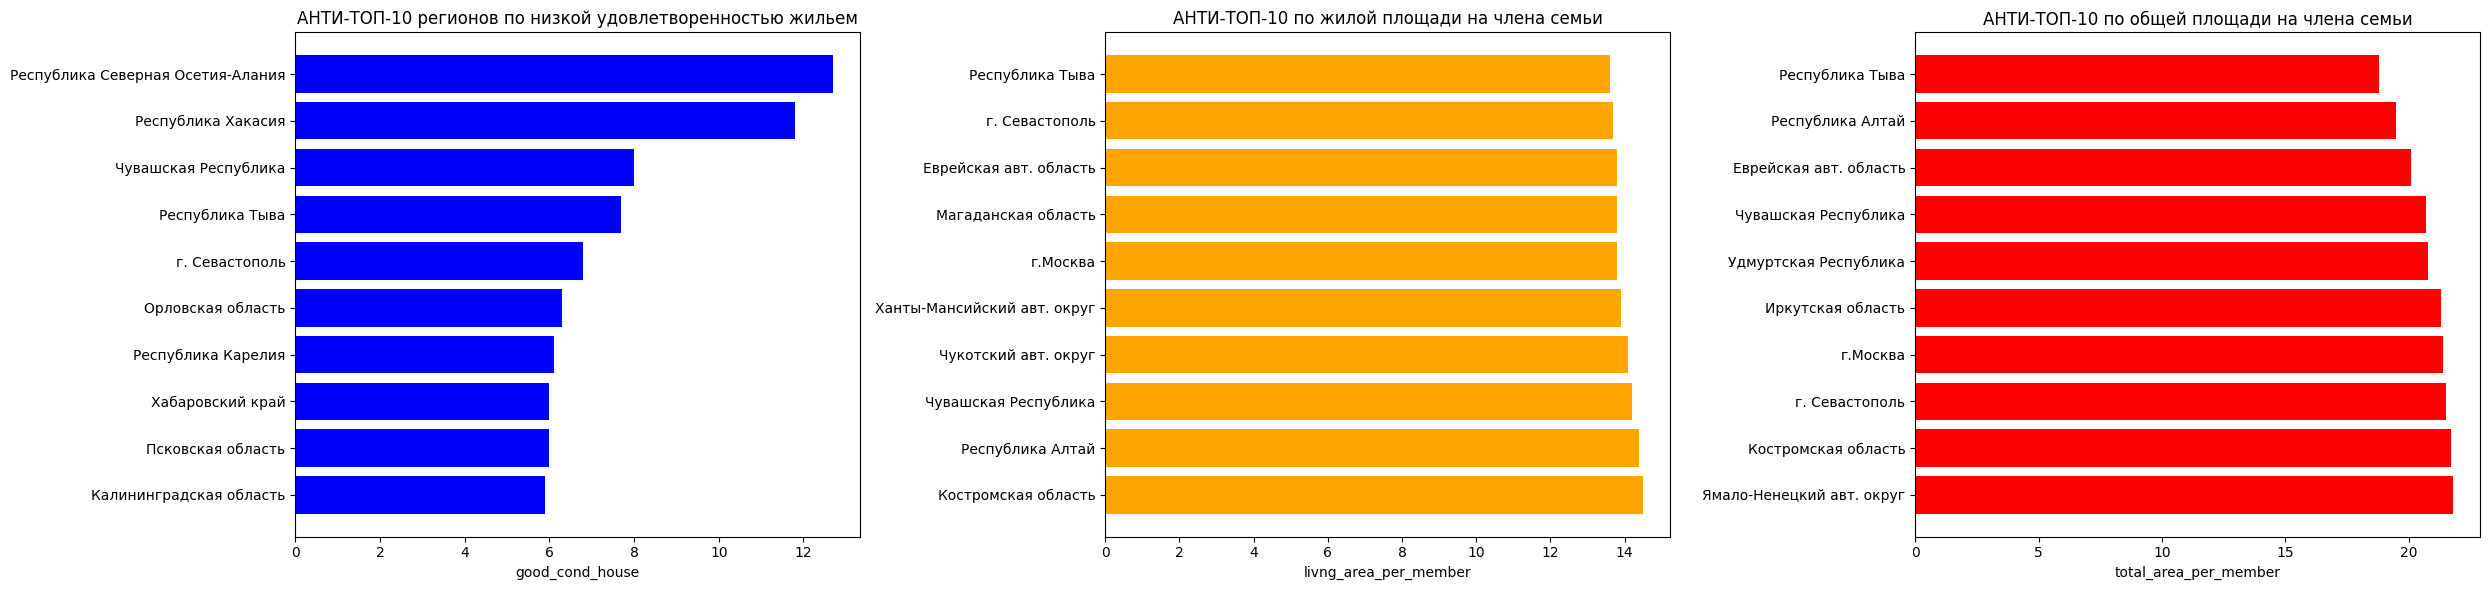

In [178]:


# 1. Анти-топ-10  по good_cond_house
top_bad = (
    data_housing.nlargest(10, "bad_cond_house")
    .sort_values("bad_cond_house", ascending=True)  # для красивого барчарта
)

# 2. Анти-топ-10 по living_area_per_member
worst_living_area = (
    data_housing.nsmallest(10, "livng_area_per_member")
    .sort_values("livng_area_per_member", ascending=False)
)

# 3. Анти-топ-10 по total_area_per_member
worst_total_area = (
    data_housing.nsmallest(10, "total_area_per_member")
    .sort_values("total_area_per_member", ascending=False)
)

# 4. Визуализация
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Топ по bad_cond_house
axes[0].barh(top_bad["region"], top_bad["bad_cond_house"], color="blue")
axes[0].set_title("АНТИ-ТОП-10 регионов по низкой удовлетворенностью жильем")
axes[0].set_xlabel("good_cond_house")

# Анти-топ по living_area_per_member
axes[1].barh(worst_living_area["region"], worst_living_area["livng_area_per_member"], color="orange")
axes[1].set_title("АНТИ-ТОП-10 по жилой площади на члена семьи")
axes[1].set_xlabel("livng_area_per_member")

# Анти-топ по total_area_per_member
axes[2].barh(worst_total_area["region"], worst_total_area["total_area_per_member"], color="red")
axes[2].set_title("АНТИ-ТОП-10 по общей площади на члена семьи")
axes[2].set_xlabel("total_area_per_member")

plt.tight_layout()
plt.show()


Регион с низкой удовлетворенностью жильем - Республика северная Осетия- Алания.
Регон с минимальной общей площадью на человека - Республика Тыва
Регион с минимальной жилой площадью на человека - Республика Тыва


In [179]:
# приведем название регионов к единому формату

data_housing = canon_region_df(data_housing, 'region', region_map)

In [180]:
# заболеваемость на 100 тыс. человек населения, по возрастным группам и группам заболеваний.
data_morbidity = pd.read_excel('data/morbidity_2005_2020_age_disease.xlsx', skiprows=2)
data_morbidity = data_morbidity.rename(columns={data_morbidity.columns[0]: "region"})
data_morbidity = data_morbidity.rename(columns={data_morbidity.columns[1]: "disease"})
data_morbidity = data_morbidity.rename(columns={data_morbidity.columns[2]: "age"})
data_morbidity.head()

,region,disease,age,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Российская Федерация,"Беременность, роды и послеродовой период",0-14 лет,21.3,17.6,17.9,22.1,18.1,18.9,16.2,17.7,12.2,12.1,8.1,15.5
1,Российская Федерация,"Беременность, роды и послеродовой период",15-17 лет,1537.3,1527.5,1605.2,1681.5,1618.9,1451.3,1247.6,1229.1,1272.3,1186.5,914.0,794.0
2,Российская Федерация,"Беременность, роды и послеродовой период",18 лет и старше,6731.7,6833.5,7229.7,7516.9,8007.5,8084.4,7981.6,8141.8,8084.6,8219.9,7734.1,7278.6
3,Российская Федерация,"Беременность, роды и послеродовой период",Всего,5719.4,5861.2,6258.7,6556.6,7011.6,7085.3,6979.7,7121.5,7067.6,7145.3,6700.2,6291.1
4,Российская Федерация,Болезни глаза и его придаточного аппарата,0-14 лет,5643.4,5581.1,5760.8,5775.9,5743.6,5884.8,5931.9,6206.9,6104.5,5919.4,5910.3,5971.5


In [181]:
# проверим на дубликаты 
dubl(data_morbidity)

Число найденных дубликатов: 0


In [182]:
# приведем регионы к единому формату 
data_morbidity = canon_region_df(data_morbidity, 'region', region_map )

In [183]:
# сгруппируем дата сет по региону
df_grouped = (data_morbidity.groupby('region').agg({
        "2005": "mean",
        "2006": "mean",
        "2007": "mean",
        "2008": "mean",
        "2009": "mean",
        "2010": "mean",
        "2011": "mean",
        "2012": "mean",
        "2013": "mean",
        "2014": "mean",
        "2015": "mean",
        "2016": "mean"
    })
.round(2)
.reset_index()
)
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  96 non-null     object 
 1   2005    92 non-null     float64
 2   2006    92 non-null     float64
 3   2007    92 non-null     float64
 4   2008    92 non-null     float64
 5   2009    92 non-null     float64
 6   2010    92 non-null     float64
 7   2011    92 non-null     float64
 8   2012    92 non-null     float64
 9   2013    92 non-null     float64
 10  2014    94 non-null     float64
 11  2015    94 non-null     float64
 12  2016    94 non-null     float64
dtypes: float64(12), object(1)
memory usage: 9.9+ KB


In [184]:
# посмотрим пропуски 
cols_null_percent = df_grouped.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

2005    4.166667
2006    4.166667
2007    4.166667
2008    4.166667
2009    4.166667
2010    4.166667
2011    4.166667
2012    4.166667
2013    4.166667
2014    2.083333
2015    2.083333
2016    2.083333
dtype: float64

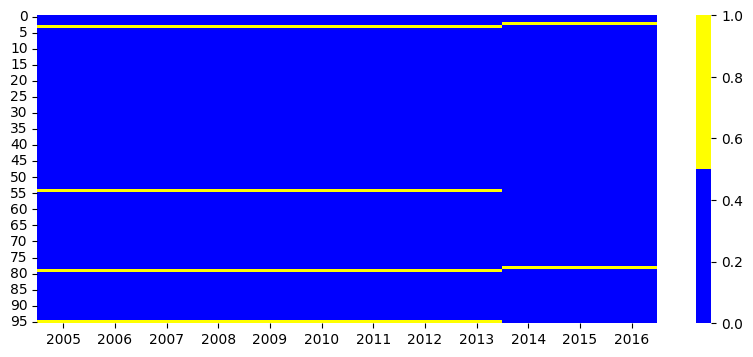

In [185]:
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(10, 4))
cols = cols_with_null.index
ax = sns.heatmap(
    df_grouped [cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [186]:
# посмотри, как в нашем дата сете представленны показатели по Архангельской области
df_grouped [df_grouped ["region"].str.contains("Архангельская", case=False, na=False)] 

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
2,Архангельская область,14977.65,16846.25,16994.39,17013.47,18489.7,18465.7,19163.42,20210.15,18026.69,NaN,NaN,NaN
3,Архангельская область без НАО,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17566.47,19073.15,18991.07


In [187]:
# посмотри, как в нашем дата сете представленны показатели по Тюменской области
df_grouped [df_grouped ["region"].str.contains("Тюменская", case=False, na=False)] 

,region,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
78,Тюменская область,13356.97,13882.16,13951.39,13765.23,13927.34,13184.43,13595.34,14381.74,10936.03,NaN,NaN,NaN
79,Тюменская область без автономных округов,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10171.08,10829.7,11090.1


In [188]:
# так как у нас не пересекаются значания по Арх и Тюм обл. то переименуем их, что бы в дальнейшем  значения объединить 

data_morbidity["region"] = data_morbidity["region"].replace(
    {
    "Архангельская область": "Архангельская область без НАО",
    "Тюменская область": "Тюменская область без автономных округов"
    })

In [189]:
morbidity_grouped = (
    data_morbidity
    .groupby(["region", "age"])
    .agg({
        "2005": "mean",
        "2006": "mean",
        "2007": "mean",
        "2008": "mean",
        "2009": "mean",
        "2010": "mean",
        "2011": "mean",
        "2012": "mean",
        "2013": "mean",
        "2014": "mean",
        "2015": "mean",
        "2016": "mean"
    })
    .round(2)
    .reset_index()
)


morbidity_grouped

,region,age,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Алтайский край,0-14 лет,17780.76,18038.88,17981.47,17770.78,19035.54,19004.09,19013.14,19786.29,19123.34,19146.12,20464.40,21629.84
1,Алтайский край,15-17 лет,16681.64,17369.75,17298.86,17261.85,19050.56,17536.42,18522.52,20046.41,20180.39,21508.36,22672.34,22034.55
2,Алтайский край,18 лет и старше,9764.18,10338.72,10558.59,10801.98,10924.24,10277.08,10793.19,12062.32,11241.88,11502.39,11765.98,11997.14
3,Алтайский край,Всего,11444.39,11907.70,12061.32,12224.68,12586.96,12014.18,12504.36,13759.64,13004.59,7388.25,13874.29,14281.39
4,Амурская область,0-14 лет,15217.27,16647.99,18133.64,18838.95,19899.25,19869.77,20438.30,22706.67,20811.40,21070.12,23024.35,23053.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,г. Санкт-Петербург,Всего,8604.78,9302.92,9599.07,10198.38,10670.31,10585.17,10251.31,11001.33,10359.42,5711.22,11450.68,12461.68
372,г. Севастополь,0-14 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18913.14,17749.15,17980.38
373,г. Севастополь,15-17 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12763.50,11843.58,12039.03
374,г. Севастополь,18 лет и старше,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4369.91,4125.00,4290.29


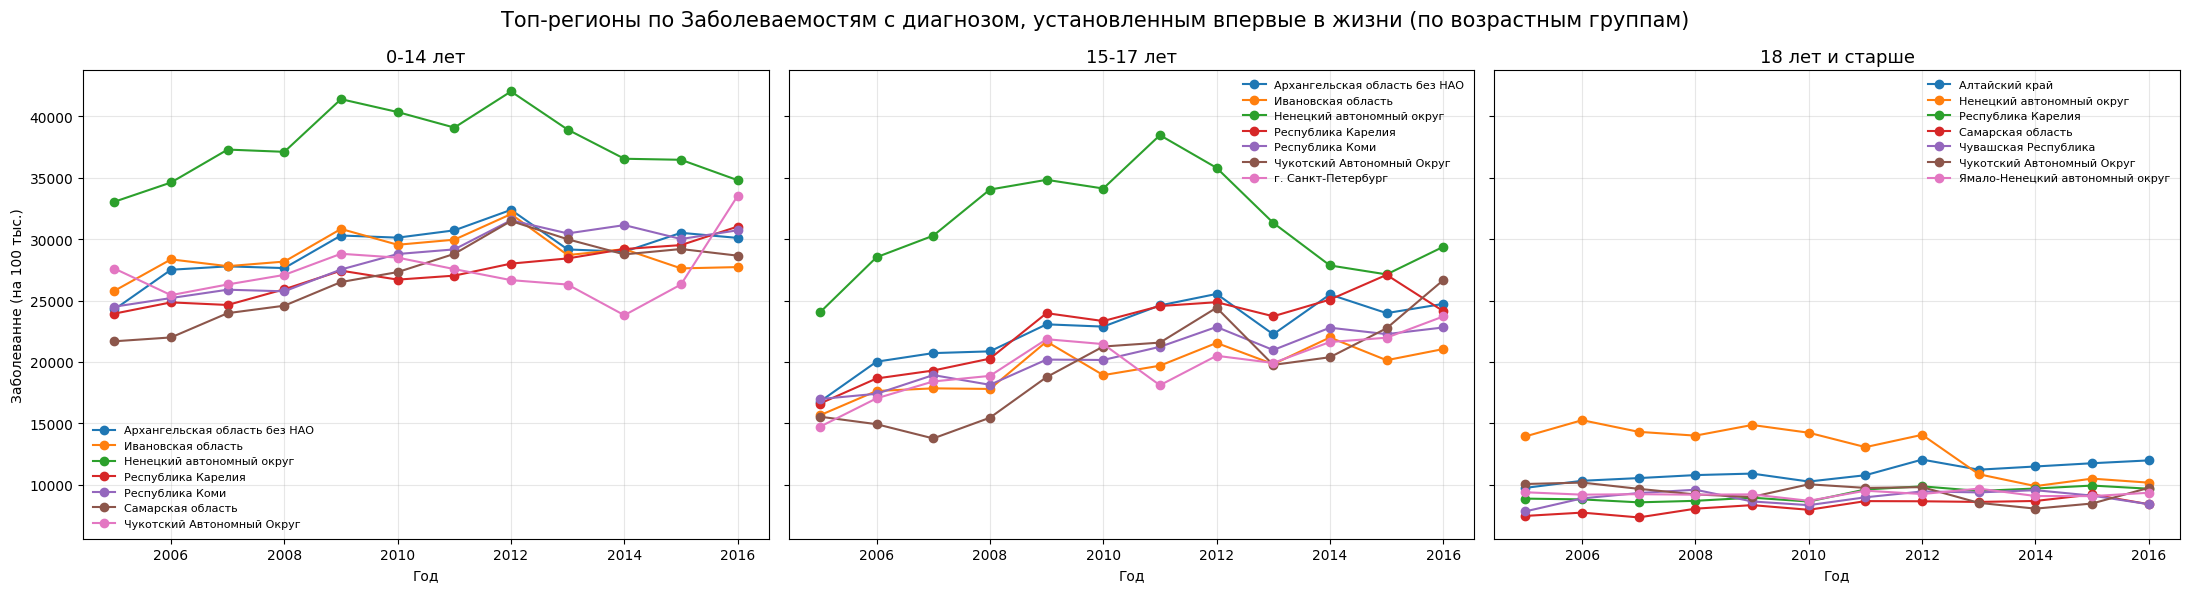

In [190]:


# 1. Годовые колонки
year_cols = [c for c in morbidity_grouped.columns if c.isdigit()]

# 2. Переводим в long
morb_long = morbidity_grouped.melt(
    id_vars=["region", "age"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

morb_long["year"] = morb_long["year"].astype(int)
morb_long["value"] = pd.to_numeric(morb_long["value"], errors="coerce")

# 3. Для наглядности возьмём топ-7 регионов по каждой возрастной группе
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

age_groups = ["0-14 лет", "15-17 лет", "18 лет и старше"]

for i, age in enumerate(age_groups):
    sub = morb_long[morb_long["age"] == age]

    # топ-7 регионов по среднему значению
    top_regions = (
        sub.groupby("region")["value"]
        .mean()
        .nlargest(7)
        .index
    )

    df_plot = sub[sub["region"].isin(top_regions)]

    for reg, subreg in df_plot.groupby("region"):
        axes[i].plot(subreg["year"], subreg["value"], marker="o", label=reg)

    axes[i].set_title(f"{age}", fontsize=13)
    axes[i].set_xlabel("Год")
    if i == 0:
        axes[i].set_ylabel("Заболеванне (на 100 тыс.)")
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8, frameon=False)

plt.suptitle("Топ-регионы по Заболеваемостям с диагнозом, установленным впервые в жизни (по возрастным группам)", fontsize=15)
plt.tight_layout()
plt.show()



Во всех трех возрастных группах лидирует Ненецкий АО. Только после 2012 года в возрастной группе от 18 лет и страше показатель немнго понизилася и первое место перешло к Алтайскому краю.

In [191]:
# создадим окончательный датасет,чтобы можно было его использовать при кластеризации 

# выделяем числовые колонки (годы)
year_cols = [col for col in morbidity_grouped.columns if col.isdigit()]

# считаем среднее по всем годам для каждой пары (регион + возраст)
morbidity_mean = (
    morbidity_grouped
    .groupby(["region", "age"])[year_cols]
    .mean()
    .round(2)
    .reset_index()
)

# добавим одну колонку - среднее по всем годам
morbidity_mean["mean_all_years"] = morbidity_mean[year_cols].mean(axis=1).round(2)

# переводим возрастные группы в колонки (pivot)
morbidity_pivot = morbidity_mean.pivot(
    index="region", columns="age", values="mean_all_years"
).reset_index()

morbidity_pivot.head(10)


age,region,0-14 лет,15-17 лет,18 лет и старше,Всего
0,Алтайский край,19064.55,19180.30,11002.31,12254.31
1,Амурская область,19975.93,15314.11,6152.51,8720.09
2,Архангельская область без НАО,29116.15,22576.17,7925.12,11603.33
3,Астраханская область,17310.49,11474.87,6153.12,8085.26
4,Белгородская область,17456.35,17472.16,7117.66,8717.26
5,Брянская область,20256.00,17624.93,7132.05,9217.85
6,Владимирская область,25941.93,18509.46,7915.57,10526.35
7,Волгоградская область,19389.15,14360.10,5979.27,8085.67
8,Вологодская область,26563.22,18788.85,6393.28,9832.82
9,Воронежская область,14604.36,10306.35,4924.44,6224.21


In [192]:
# оставим только значения по возрастным группам без суммы
morbidity_df = morbidity_pivot.drop('Всего', axis=1)

In [193]:
morbidity_df = morbidity_df.rename(columns={
    '0-14 лет': '0-14_dieses',
    '15-17 лет': '15_17_dieses',
    '18 лет и старше': '18_and_over_dieses',
})

In [194]:
# новорожденные по регионам
data_newborn = pd.read_csv('data/newborn_2006_2022_monthly.csv', sep=";", encoding="utf-8")
data_newborn.head(3)


,Region,январь 2006 г.,февраль 2006 г.,март 2006 г.,апрель 2006 г.,май 2006 г.,июнь 2006 г.,июль 2006 г.,август 2006 г.,сентябрь 2006 г.,...,сентябрь 2021 г.,октябрь 2021 г.,ноябрь 2021 г.,декабрь 2021 г.,январь 2022 г.,февраль 2022 г.,март 2022 г.,апрель 2022 г.,май 2022 г.,Unnamed: 198
0,Российская Федерация,109422,"114068,99","129177,99","113391,99","125099,99",124238,"125926,99","140227,99","123949,99",...,"121645,99","120080,99","114976,99","117945,99",103782,101082,115512,"99696,99",103159,NaN
1,Центральный федеральный округ,"24998,99","25539,99","29558,99",25781,29137,28837,"28997,99","31590,99","27755,99",...,29727,"29532,99",29093,29477,25827,25678,28086,"24979,99",26304,NaN
2,Белгородская область,1040,1094,1190,1044,1228,1249,1224,1389,1157,...,1084,1053,990,1028,861,941,956,801,869,NaN


In [195]:
# проверим наличие дубликатов
dubl(data_newborn)

Число найденных дубликатов: 0


In [196]:
data_newborn.isnull().mean() * 100

Region               0.000000
январь 2006 г.      11.926606
февраль 2006 г.     11.926606
март 2006 г.        11.926606
апрель 2006 г.      11.926606
                      ...    
февраль 2022 г.     11.926606
март 2022 г.        11.926606
апрель 2022 г.      11.926606
май 2022 г.         11.926606
Unnamed: 198       100.000000
Length: 199, dtype: float64

In [197]:
# удалим сразц 100 пропуски
data_newborn = data_newborn.drop('Unnamed: 198', axis=1)

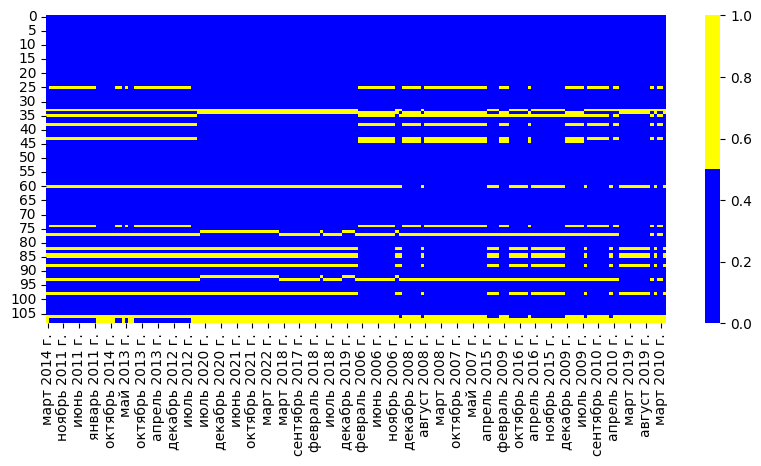

In [198]:
# посмотрим пропуски 
cols_null_percent = data_newborn.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(10, 4))
cols = cols_with_null.index
ax = sns.heatmap(
    data_newborn[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [199]:
data_newborn.iloc[38]

Region             Республика Крым
январь 2006 г.                 NaN
февраль 2006 г.                NaN
март 2006 г.                   NaN
апрель 2006 г.                 NaN
                        ...       
январь 2022 г.                1248
февраль 2022 г.               1302
март 2022 г.                  1505
апрель 2022 г.                1258
май 2022 г.                   1194
Name: 38, Length: 198, dtype: object

In [200]:
# посмотри, как в нашем дата сете представленны показатели по Тюменской области
data_newborn [data_newborn ["Region"].str.contains("Тюменская", case=False, na=False)] 

,Region,январь 2006 г.,февраль 2006 г.,март 2006 г.,апрель 2006 г.,май 2006 г.,июнь 2006 г.,июль 2006 г.,август 2006 г.,сентябрь 2006 г.,...,август 2021 г.,сентябрь 2021 г.,октябрь 2021 г.,ноябрь 2021 г.,декабрь 2021 г.,январь 2022 г.,февраль 2022 г.,март 2022 г.,апрель 2022 г.,май 2022 г.
71,Тюменская область,"2992,99",3585,"3714,99",3630,3855,3817,3638,"3733,99",4044,...,3802,3914,3881,"3744,99",3976,3431,3203,3888,3394,3589
72,Ханты-Мансийский автономный округ - Югра (Тюме...,1337,1639,1789,1596,1837,1819,1740,1531,"2119,99",...,1670,1692,1658,1621,1732,1420,1412,1714,1493,1589
73,Ямало-Ненецкий автономный округ (Тюменская обл...,370,646,463,726,619,599,500,633,543,...,543,587,601,580,645,532,"496,99",623,572,590
74,Тюменская область (кроме Ханты-Мансийского авт...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1589,1635,1622,1544,1599,1479,1294,1551,1329,1410


In [201]:
# посмотри, как в нашем дата сете представленны показатели по Тюменской области
data_newborn [data_newborn ["Region"].str.contains("Архангельская", case=False, na=False)] 

,Region,январь 2006 г.,февраль 2006 г.,март 2006 г.,апрель 2006 г.,май 2006 г.,июнь 2006 г.,июль 2006 г.,август 2006 г.,сентябрь 2006 г.,...,август 2021 г.,сентябрь 2021 г.,октябрь 2021 г.,ноябрь 2021 г.,декабрь 2021 г.,январь 2022 г.,февраль 2022 г.,март 2022 г.,апрель 2022 г.,май 2022 г.
23,Архангельская область,1136,1045,1260,1133,1201,1147,1334,1297,1106,...,782,736,741,700,754,654,630,764,656,687
24,Ненецкий автономный округ (Архангельская область),51,43,53,58,34,47,55,61,45,...,53,55,39,41,47,40,51,55,27,38
25,Архангельская область (кроме Ненецкого автоном...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,729,681,702,659,707,614,579,709,629,649


In [202]:


def _collapse_region_to_series(df: pd.DataFrame, region_name: str, region_col: str, val_cols: list[str]) -> pd.Series:
    """
    Берёт все строки по региону, приводит к числам и «схлопывает» в одну серию:
    для каждого столбца берём первое непустое значение сверху (если строк несколько).
    """
    block = df.loc[df[region_col] == region_name, val_cols]
    if block.empty:
        raise ValueError(f"В таблице нет строк для: {region_name}")
    block = block.apply(pd.to_numeric, errors="coerce")
    return block.T.bfill(axis=1).iloc[:, 0]  # Series с индексом = val_cols


def fill_parent_minus_children(
    df: pd.DataFrame,
    region_col: str,
    parent_region: str,
    children_regions: list[str],
    target_region: str,
) -> pd.DataFrame:
    """
    Заполняет NaN в target_region значениями: parent_region - sum(children_regions)
    по всем «временным» столбцам (годы/месяцы).
    Незаполненные ячейки не трогаются.
    """
    res = df.copy()
    if region_col not in res.columns:
        raise ValueError(f"Колонка региона '{region_col}' не найдена. Есть: {list(res.columns)}")

    # все столбцы, кроме колонки региона — считаем временными
    val_cols = [c for c in res.columns if c != region_col]

    # серии-источники
    s_parent = _collapse_region_to_series(res, parent_region, region_col, val_cols)

    s_children_sum = None
    for child in children_regions:
        s_child = _collapse_region_to_series(res, child, region_col, val_cols)
        s_children_sum = s_child if s_children_sum is None else (s_children_sum + s_child)

    # разница = родитель − сумма дочерних
    s_diff = s_parent - s_children_sum

    # целевые строки (могут быть >1) — заполняем только NaN
    mask_tgt = res[region_col] == target_region
    if not mask_tgt.any():
        raise ValueError(f"В таблице нет строк для: {target_region}")

    tgt_vals = res.loc[mask_tgt, val_cols].apply(pd.to_numeric, errors="coerce")
    res.loc[mask_tgt, val_cols] = tgt_vals.fillna(s_diff)

    return res


In [203]:
data_newborn = fill_parent_minus_children(
    df=data_newborn,
    region_col="Region",  # или "region"/"Регион" — поставь твоё имя колонки
    parent_region="Тюменская область",
    children_regions=[
        "Ханты-Мансийский автономный округ - Югра (Тюменская область)",
        "Ямало-Ненецкий автономный округ (Тюменская область)",
    ],
    target_region="Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)",
)


In [204]:
data_newborn = fill_parent_minus_children(
    df=data_newborn,
    region_col="Region",
    parent_region="Архангельская область",
    children_regions=["Ненецкий автономный округ (Архангельская область)"],
    target_region="Архангельская область (кроме Ненецкого автономного округа)",
)


In [205]:
# приведем название регионов к единому стандарту

data_newborn = canon_region_df(data_newborn,  'Region', region_map)

In [206]:
#  удалим все округа и Тюми Арх области, чтобы не мешали дальнейшему анализу по регионам
mask_totals = data_newborn["Region"].str.strip().isin([
    "Южный федеральный округ (с 29.07.2016)",
    "Архангельская область",
    "Тюменская область",
    "Дальневосточный федеральный округ",
    "Российская Федерация",
    "Южный федеральный округ",
    "Центральный федеральный округ",
    "Северо-Западный федеральный округ",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Уральский федеральный округ",
    "Коми-Пермяцкий Округ",
    "Сибирский Фдеральный Округ",
    "Таймырский (Долгано-Ненецкий) Автономный Округ",
    "Усть-Ордынский Бурятский округ",
    "Эвенкийский автономный округ (Красноярский край)",
    "Южный федеральный округ",
    "Центральный Федеральный Округ",
    "Южный Федеральный Округ",
    "Сибирский Федеральный Округ", 
])

data_newborn = data_newborn[~mask_totals].reset_index(drop=True)


In [207]:

data_newborn.head()

,Region,январь 2006 г.,февраль 2006 г.,март 2006 г.,апрель 2006 г.,май 2006 г.,июнь 2006 г.,июль 2006 г.,август 2006 г.,сентябрь 2006 г.,...,август 2021 г.,сентябрь 2021 г.,октябрь 2021 г.,ноябрь 2021 г.,декабрь 2021 г.,январь 2022 г.,февраль 2022 г.,март 2022 г.,апрель 2022 г.,май 2022 г.
0,Белгородская область,1040,1094,1190,1044,1228,1249,1224,1389,1157,...,1154,1084,1053,990,1028,861,941,956,801,869
1,Брянская область,904,989,1039,936,1072,961,1058,1121,989,...,835,784,751,783,729,707,670,740,589,660
2,Владимирская область,1040,1059,1236,1063,1226,1144,1221,1333,1177,...,864,783,834,769,821,691,700,708,660,711
3,Воронежская область,1301,1479,1689,1513,1729,1555,1620,1897,1554,...,1708,1643,1278,1758,1584,1342,1326,1576,1309,1319
4,Ивановская область,714,799,829,806,840,847,859,865,812,...,630,620,598,609,614,562,506,628,536,562


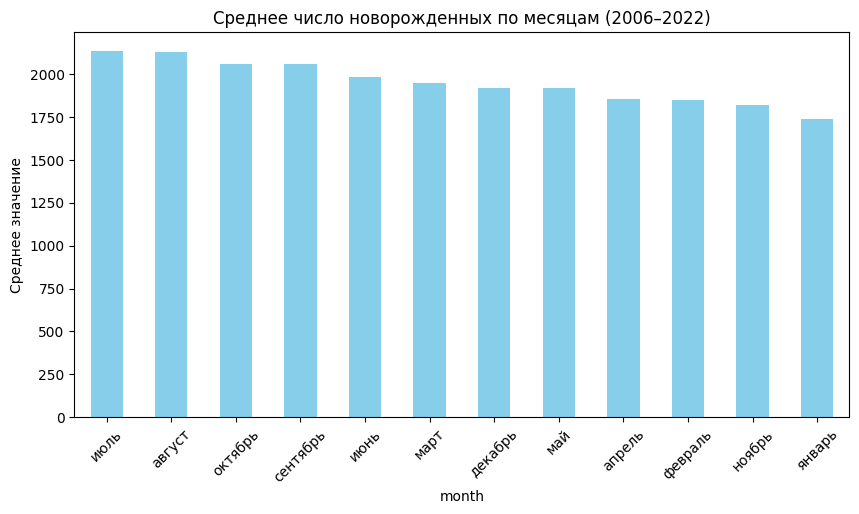

In [208]:


# 1. Переводим в long-format
df_long = data_newborn.melt(
    id_vars=["Region"], 
    var_name="period", 
    value_name="births"
)

# 2. Достаём месяц и год из строки
# пример: "январь 2006 г." → month="январь", year=2006
df_long["period"] = df_long["period"].astype(str)
df_long["year"] = df_long["period"].str.extract(r"(\d{4})").astype(float).astype("Int64")
df_long["month"] = df_long["period"].str.replace(r"\s*\d{4}.*", "", regex=True).str.strip()

# 3. Убираем NaN и приводим births к числу
df_long["births"] = pd.to_numeric(df_long["births"], errors="coerce")
df_long = df_long.dropna(subset=["births"])

# --- Графики ---

# . Среднее по всем годам: какой месяц самый "плодоносный"
month_avg = df_long.groupby("month")["births"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
month_avg.plot(kind="bar", color="skyblue")
plt.title("Среднее число новорожденных по месяцам (2006–2022)")
plt.ylabel("Среднее значение")
plt.xticks(rotation=45)
plt.show()




По графику видно, что практически нет явных лидеров среди месяцев, когда появляются дети.

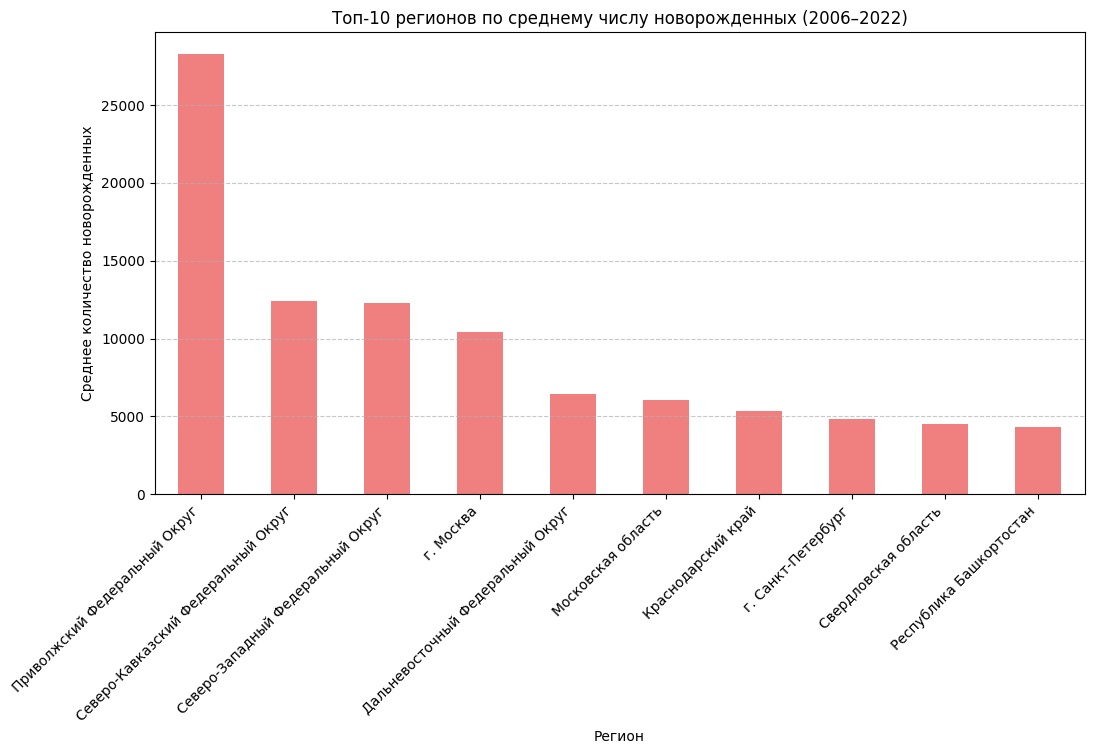

In [209]:

# Выделяем год
df_long["year"] = df_long["period"].str.extract(r"(\d{4})").astype(float).astype("Int64")

#  Число новорожденных → число
df_long["births"] = pd.to_numeric(df_long["births"], errors="coerce")
df_long = df_long.dropna(subset=["births"])

#  Среднее количество новорожденных по региону (за все годы)
region_avg = (
    df_long.groupby("Region")["births"]
    .mean()
    .sort_values(ascending=False)
    .head(10)  # топ-10 регионов
)

#  Строим график
plt.figure(figsize=(12, 6))
region_avg.plot(kind="bar", color="lightcoral")
plt.title("Топ-10 регионов по среднему числу новорожденных (2006–2022)")
plt.ylabel("Среднее количество новорожденных")
plt.xlabel("Регион")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Больше всего новорожденных приходится на город Москва.

In [210]:
nwbn_mean= (
    df_long.groupby("Region")["births"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"births": "nwbn_mean"})
    .rename(columns={"Region": "region"})
)

nwbn_mean

,region,nwbn_mean
0,Приволжский Федеральный Округ,28255.58
1,Северо-Кавказский Федеральный Округ,12440.32
2,Северо-Западный Федеральный Округ,12251.93
3,г. Москва,10402.28
4,Дальневосточный Федеральный Округ,6462.75
...,...,...
86,Магаданская область,138.62
87,Агинский Бурятский округ,136.52
88,Ненецкий автономный округ,55.55
89,Чукотский Автономный Округ,55.44


In [211]:
# популяция по регионам
data_population = pd.read_excel('data/population.xlsx', skiprows=1)
data_population.head(5)

,Unnamed: 0,Unnamed: 1,январь 1999 г.,январь 2000 г.,январь 2001 г.,январь 2002 г.,январь 2003 г.,январь 2004 г.,январь 2005 г.,январь 2006 г.,...,январь 2013 г.,январь 2014 г.,январь 2015 г.,январь 2016 г.,январь 2017 г.,январь 2018 г.,январь 2019 г.,январь 2020 г.,январь 2021 г.,январь 2022 г.
0,все население,w2:p_mest:11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Российская Федерация,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Раздел 1. Муниципальные образования субъектов ...,00000000000,147539426.0,146890128.0,146303611.0,145649334.0,144963650.0,144333586.0,143801046.0,143236582.0,...,143347059.0,143666931.0,146267288.0,146544710.0,146804372.0,146880432.0,146780720.0,146748590.0,146171015.0,145557576.0
3,Центральный федеральный округ,030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Раздел 1. Муниципальные образования субъектов ...,00000000000,38311159.0,38227656.0,38175094.0,38068452.0,37946810.0,37965073.0,38044068.0,38109006.0,...,38678913.0,38819874.0,38951479.0,39104319.0,39209582.0,39311413.0,39378059.0,39433556.0,39250960.0,39104400.0


In [212]:

# создадим копию
df = data_population.copy()

#  Переименуем первые колонки
df = df.rename(columns={"Unnamed: 0": "name", "Unnamed: 1": "code"})

#  Список колонок с месяцами (оставляем только их и регион)
month_cols = [c for c in df.columns if isinstance(c, str) and "январь" in c.lower()]


#  Определим, какие строки несут ИМЯ РЕГИОНА 
name = df["name"].astype(str)

mask_region_name = (
    ~name.str.contains(r"^раздел", flags=re.I, na=False)   # исключаем "Раздел"
    & ~name.str.contains(r"все население", flags=re.I, na=False)         # исключаем "все население"
    & (name.str.strip() != "")
)

#  Протянем (ffill) последнее встреченное название региона вниз
df["region_ffill"] = df["name"].where(mask_region_name).ffill()

#  Строки с ДАННЫМИ: там где в первой колонке «Раздел…», а во второй числовой код
mask_data_row = (
    df["name"].astype(str).str.contains(r"^раздел", flags=re.I, na=False)
    & df["code"].astype(str).str.fullmatch(r"\d+")
)

# Соберём «чистый» датафрейм: Регион + месяцы
df_popl = (
    df.loc[mask_data_row, ["region_ffill"] + month_cols]
      .rename(columns={"region_ffill": "region"})
      .reset_index(drop=True)
)

# 7) Приведём значения к числам
for c in month_cols:
    df_popl[c] = (
        df_popl[c]
        .astype(str)
        .str.replace("\u00A0", "", regex=False)  # неразрывные пробелы
        .str.replace(" ", "", regex=False)      # обычные пробелы
        .str.replace(",", ".", regex=False)     # если вдруг запятые
        .replace({"": None, "-": None, "—": None, "–": None})
    )
    df_popl[c] = pd.to_numeric(df_popl[c], errors="coerce")







In [213]:
df_popl.head(2)

,region,январь 1999 г.,январь 2000 г.,январь 2001 г.,январь 2002 г.,январь 2003 г.,январь 2004 г.,январь 2005 г.,январь 2006 г.,январь 2007 г.,...,январь 2013 г.,январь 2014 г.,январь 2015 г.,январь 2016 г.,январь 2017 г.,январь 2018 г.,январь 2019 г.,январь 2020 г.,январь 2021 г.,январь 2022 г.
0,Российская Федерация,147539426.0,146890128.0,146303611.0,145649334.0,144963650.0,144333586.0,143801046.0,143236582.0,142862692.0,...,143347059.0,143666931.0,146267288.0,146544710.0,146804372.0,146880432.0,146780720.0,146748590.0,146171015.0,145557576.0
1,Центральный федеральный округ,38311159.0,38227656.0,38175094.0,38068452.0,37946810.0,37965073.0,38044068.0,38109006.0,38183357.0,...,38678913.0,38819874.0,38951479.0,39104319.0,39209582.0,39311413.0,39378059.0,39433556.0,39250960.0,39104400.0


In [214]:
df_popl[df_popl['region'].str.contains("Крым", case=False, na=False)] 

,region,январь 1999 г.,январь 2000 г.,январь 2001 г.,январь 2002 г.,январь 2003 г.,январь 2004 г.,январь 2005 г.,январь 2006 г.,январь 2007 г.,...,январь 2013 г.,январь 2014 г.,январь 2015 г.,январь 2016 г.,январь 2017 г.,январь 2018 г.,январь 2019 г.,январь 2020 г.,январь 2021 г.,январь 2022 г.
38,Республика Крым,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1895915.0,1907106.0,1912168.0,1913731.0,1911818.0,1912622.0,1901578.0,1896393.0
107,Крымский федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2294888.0,2323369.0,NaN,NaN,NaN,NaN,NaN,NaN


In [215]:
# оставим население за 2022 год
popul_2022 = df_popl[["region", "январь 2022 г."]]
popul_2022

,region,январь 2022 г.
0,Российская Федерация,145557576.0
1,Центральный федеральный округ,39104400.0
2,Белгородская область,1531917.0
3,Брянская область,1168771.0
4,Владимирская область,1323659.0
...,...,...
103,Магаданская область,137767.0
104,Сахалинская область,484177.0
105,Еврейская автономная область,153831.0
106,Чукотский автономный округ,50040.0


In [216]:
popul_2022[popul_2022['region'].str.contains("Крым", case=False, na=False)] 

,region,январь 2022 г.
38,Республика Крым,1896393.0
107,Крымский федеральный округ,NaN


In [217]:
dubl(popul_2022)

Число найденных дубликатов: 0


In [218]:
# посмотри, как в нашем дата сете представленны показатели по Арх области
popul_2022 [popul_2022 ["region"].str.contains("Архангельская", case=False, na=False)] 

,region,январь 2022 г.
23,Архангельская область,1114322.0
24,Ненецкий автономный округ (Архангельская область),44540.0
25,Архангельская область (кроме Ненецкого автоном...,1069782.0


In [222]:
#  удалим все округа и Тюми Арх области, чтобы не мешали дальнейшему анализу по регионам
mask_totals = popul_2022["region"].str.strip().isin([
    "Южный федеральный округ (с 29.07.2016)",
    "Архангельская область",
    "Тюменская область",
    "Дальневосточный федеральный округ",
    "Российская Федерация",
    "Южный федеральный округ",
    "Центральный федеральный округ",
    "Северо-Западный федеральный округ",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Уральский федеральный округ",
    "Коми-Пермяцкий Округ",
    "Сибирский Фдеральный Округ",
    "Таймырский (Долгано-Ненецкий) Автономный Округ",
    "Усть-Ордынский Бурятский округ",
    "Эвенкийский автономный округ (Красноярский край)",
    "Южный федеральный округ",
    "Центральный Федеральный Округ",
    "Южный Федеральный Округ",
    "Сибирский Фдеральный Округ",
    "Приволжский Федеральный Округ",
    "Северо-Западный Федеральный Округ",
    "Гришинский сельсовет",
    "Агинский Бурятский округ",
    "Корякский Округ",
    "Крымский федеральный округ"  
    
    
])

popul_2022 = popul_2022[~mask_totals].reset_index(drop=True)

In [220]:
# приведем название регионов к общему формату 
popul_2022 = canon_region_df(popul_2022, 'region', region_map)

In [223]:
sorted = popul_2022.sort_values(by='январь 2022 г.', ascending=False)
sorted

,region,январь 2022 г.
17,г. Москва,12635466.0
9,Московская область,7768878.0
32,Краснодарский край,5687378.0
28,г. Санкт-Петербург,5377503.0
59,Свердловская область,4264340.0
...,...,...
64,Республика Алтай,221559.0
83,Еврейская автономная область,153831.0
81,Магаданская область,137767.0
84,Чукотский Автономный Округ,50040.0


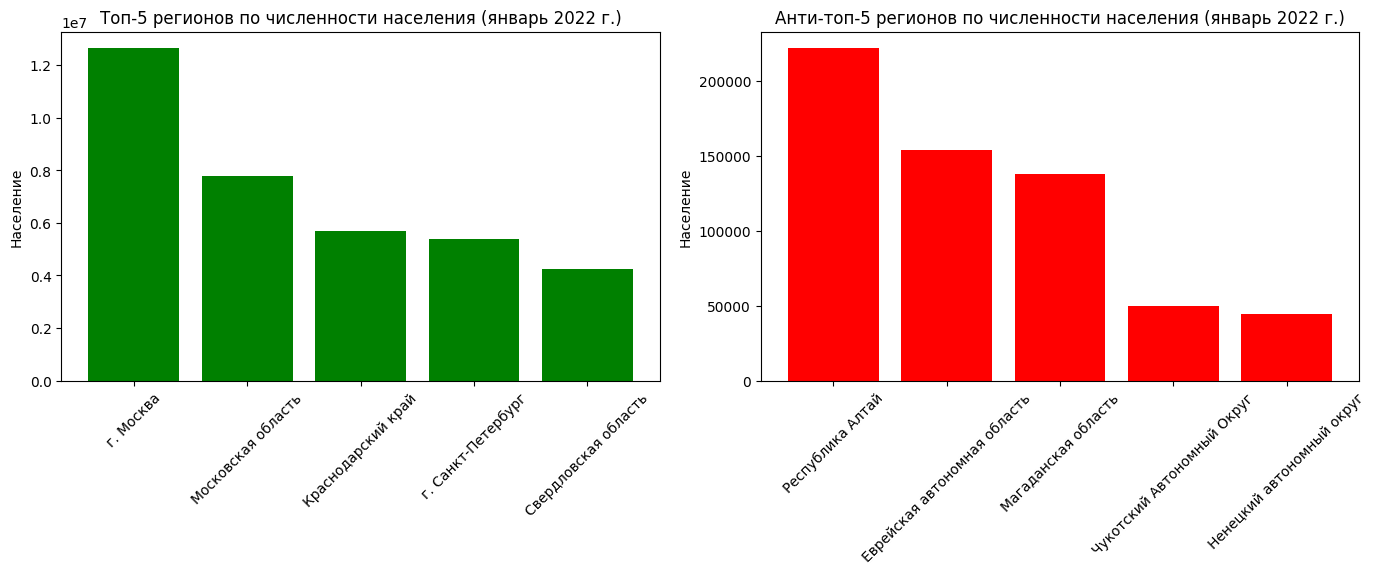

In [224]:
# берём топ-5 и анти-топ-5 по населению
top5 = sorted.head(5)
bottom5 = sorted.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# топ-5
axes[0].bar(top5["region"], top5["январь 2022 г."], color="green")
axes[0].set_title("Топ-5 регионов по численности населения (январь 2022 г.)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Население")

# анти-топ-5
axes[1].bar(bottom5["region"], bottom5["январь 2022 г."], color="red")
axes[1].set_title("Анти-топ-5 регионов по численности населения (январь 2022 г.)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Население")

plt.tight_layout()
plt.show()

Самый новорождаемый регион - г.Москва, самый малорождаемый - Ненецкий автономный округ

In [225]:
popul_2022 = popul_2022.rename(columns={'январь 2022 г.': 'popul_01_22'})

In [226]:
popul_2022[popul_2022['region'].str.contains("Крым", case=False, na=False)] 

,region,popul_01_22
31,Республика Крым,1896393.0


In [227]:
# процент малоимущих по регионам
data_percent_pover_reg = pd.read_csv('data/poverty_percent_by_regions_1992_2020.csv')
data_percent_pover_reg

,region,year,poverty_percent
0,Российская Федерация,1992,33.5
1,Российская Федерация,1993,31.3
2,Российская Федерация,1994,22.4
3,Российская Федерация,1995,24.8
4,Российская Федерация,1996,22.1
...,...,...,...
2334,Чукотский автономный округ,2017,8.5
2335,Чукотский автономный округ,2018,8.8
2336,Чукотский автономный округ,2019,8.5
2337,Чукотский автономный округ,2020,8.0


In [228]:
grouped_percent_pover = data_percent_pover_reg.groupby('region')['poverty_percent'].mean().reset_index().round(2)
grouped_percent_pover

,region,poverty_percent
0,Архангельская область (кроме Ненец...,13.83
1,Ненецкий автономный округ (Арханге...,9.05
2,Тюменская область (кроме Ханты-Ман...,13.57
3,Ханты-Мансийский автономный округ ...,7.83
4,Ямало-Ненецкий автономный округ (Т...,5.75
...,...,...
93,Уральский федеральный округ,0.00
94,Центральный федеральный округ,0.00
95,Южный федеральный округ (с 2010 года),0.00
96,Южный федеральный округ (с 29.07.2016),0.00


In [229]:
#  удалим все округа и Тюми Арх области, чтобы не мешали дальнейшему анализу по регионам
mask_totals = grouped_percent_pover["region"].str.strip().isin([
    "Южный федеральный округ (с 29.07.2016)",
    "Архангельская область",
    "Тюменская область",
    "Дальневосточный федеральный округ",
    "Российская Федерация",
    "Южный федеральный округ",
    "Центральный федеральный округ",
    "Северо-Западный федеральный округ",
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Уральский федеральный округ",
    "Коми-Пермяцкий Округ",
    "Сибирский Фдеральный Округ",
    "Таймырский (Долгано-Ненецкий) Автономный Округ",
    "Усть-Ордынский Бурятский округ",
    "Эвенкийский автономный округ (Красноярский край)",
    "Южный федеральный округ",
    "Центральный Федеральный Округ",
    "Южный Федеральный Округ",
    "Сибирский Фдеральный Округ",
    "Приволжский Федеральный Округ",
    "Северо-Западный Федеральный Округ",
    "Гришинский сельсовет",
    "Агинский Бурятский округ",
    "Корякский Округ",
    "Крымский федеральный округ",
    "Южный федеральный округ (с 2010 года)",
    
    
])

grouped_percent_pover = grouped_percent_pover[~mask_totals].reset_index(drop=True)

In [230]:
grouped_percent_pover.isnull().mean()*100

region             0.0
poverty_percent    0.0
dtype: float64

In [231]:
dubl(grouped_percent_pover)

Число найденных дубликатов: 0


In [232]:
# приведем название регионов к общему формату 
grouped_percent_pover = canon_region_df(grouped_percent_pover, 'region', region_map)

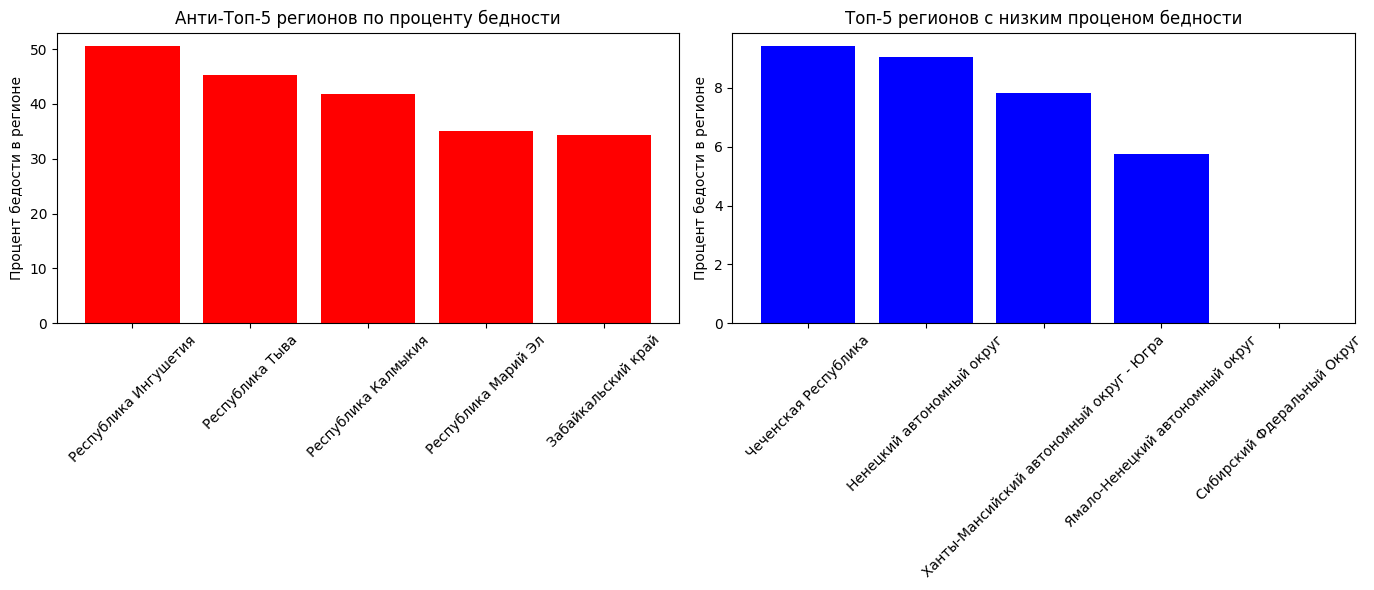

In [233]:
sorted_pover = grouped_percent_pover.sort_values(by='poverty_percent', ascending=False)

# берём топ-5 и анти-топ-5 по проценту бедности
top5 = sorted_pover.head(5)
bottom5 = sorted_pover.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# топ-5
axes[0].bar(top5["region"], top5["poverty_percent"], color="red")
axes[0].set_title("Анти-Топ-5 регионов по проценту бедности")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Процент бедости в регионе")

# анти-топ-5
axes[1].bar(bottom5["region"], bottom5["poverty_percent"], color="blue")
axes[1].set_title("Топ-5 регионов с низким проценом бедности")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Процент бедости в регионе")

plt.tight_layout()
plt.show()

Самый высокий процент бедности населения в Республике Ингушетия, а в Ямало-Ненецком ОА - самый низкий.


In [234]:
# распределение малоимущего населения по социально-демографическим
data_poverty_socdem_20 = pd.read_excel('data/poverty_socdem_2020.xlsx', skiprows=2)

data_poverty_socdem_20  = data_poverty_socdem_20 .rename(columns={data_poverty_socdem_20 .columns[0]: "Регион"})
data_poverty_socdem_20.describe()

,Все население,Дети в возрасте до 16 лет,Население старше трудоспособного возраста,Население трудоспособного возраста
count,88.0,76.000000,76.000000,76.000000
mean,100.0,38.996053,5.063158,55.948684
std,0.0,6.131654,2.832612,5.671602
min,100.0,22.200000,0.300000,42.900000
25%,100.0,34.575000,2.975000,52.200000
50%,100.0,39.350000,4.750000,55.000000
75%,100.0,42.875000,6.700000,59.225000
max,100.0,55.600000,13.200000,73.600000


In [235]:
data_poverty_socdem_20.head()
data_poverty_socdem_20['год'] = 2020

In [236]:
# распределение малоимущего населения по социально-демографическим
data_poverty_socdem_19 = pd.read_excel('data/poverty_socdem_2019.xlsx', skiprows=2)
data_poverty_socdem_19  = data_poverty_socdem_19.rename(columns={data_poverty_socdem_19 .columns[0]: "Регион"})
data_poverty_socdem_19['год'] = 2019

data_poverty_socdem_18 = pd.read_excel('data/poverty_socdem_2018.xlsx', skiprows=2)
data_poverty_socdem_18  = data_poverty_socdem_18.rename(columns={data_poverty_socdem_18 .columns[0]: "Регион"})
data_poverty_socdem_18['год'] = 2018

data_poverty_socdem_17 = pd.read_excel('data/poverty_socdem_2017.xlsx', skiprows=2)
data_poverty_socdem_17  = data_poverty_socdem_17.rename(columns={data_poverty_socdem_17 .columns[0]: "Регион"})
data_poverty_socdem_17['год'] = 2017

In [238]:
frames = [data_poverty_socdem_20, data_poverty_socdem_19, data_poverty_socdem_18, data_poverty_socdem_17]
data_poverty = pd.concat(frames, ignore_index=True)
data_poverty

,Регион,Все население,Дети в возрасте до 16 лет,Население старше трудоспособного возраста,Население трудоспособного возраста,год
0,Российская Федерация,100,39.7,5.2,55.2,2020
1,Белгородская область,100,NaN,NaN,NaN,2020
2,Брянская область,100,44.8,3.7,51.6,2020
3,Владимирская область,100,NaN,NaN,NaN,2020
4,Воронежская область,100,28.5,2.3,69.2,2020
...,...,...,...,...,...,...
347,Амурская область,100,39.9,6.0,54.1,2017
348,Магаданская область,100,32.2,14.8,53.0,2017
349,Сахалинская область,100,36.4,6.4,57.1,2017
350,Еврейская автономная область,100,36.0,9.9,54.1,2017


In [239]:
data_poverty.isnull().mean() * 100

Регион                                       0.000000
Все население                                0.000000
Дети в возрасте до 16 лет                    3.409091
Население старше трудоспособного возраста    3.409091
Население трудоспособного возраста           3.409091
год                                          0.000000
dtype: float64

In [240]:
data_poverty = canon_region_df(data_poverty, 'Регион', region_map)

In [241]:
pover_grouped = data_poverty.groupby(['Регион']).agg({
    "Дети в возрасте до 16 лет": "mean",
    "Население старше трудоспособного возраста": "mean",
    "Население трудоспособного возраста": "mean"
}).reset_index().round(2)

pover_grouped

,Регион,Дети в возрасте до 16 лет,Население старше трудоспособного возраста,Население трудоспособного возраста
0,Алтайский край,37.55,6.15,56.30
1,Амурская область,38.20,5.62,56.18
2,Архангельская область,35.20,7.02,57.80
3,Архангельская область без НАО,34.00,7.45,58.55
4,Астраханская область,40.17,4.90,54.90
...,...,...,...,...
83,Ямало-Ненецкий автономный округ,47.70,1.05,51.22
84,Ярославская область,36.33,5.28,58.42
85,г. Москва,39.65,9.78,50.62
86,г. Санкт-Петербург,17.43,3.27,46.00


In [242]:
dubl(pover_grouped)

Число найденных дубликатов: 0


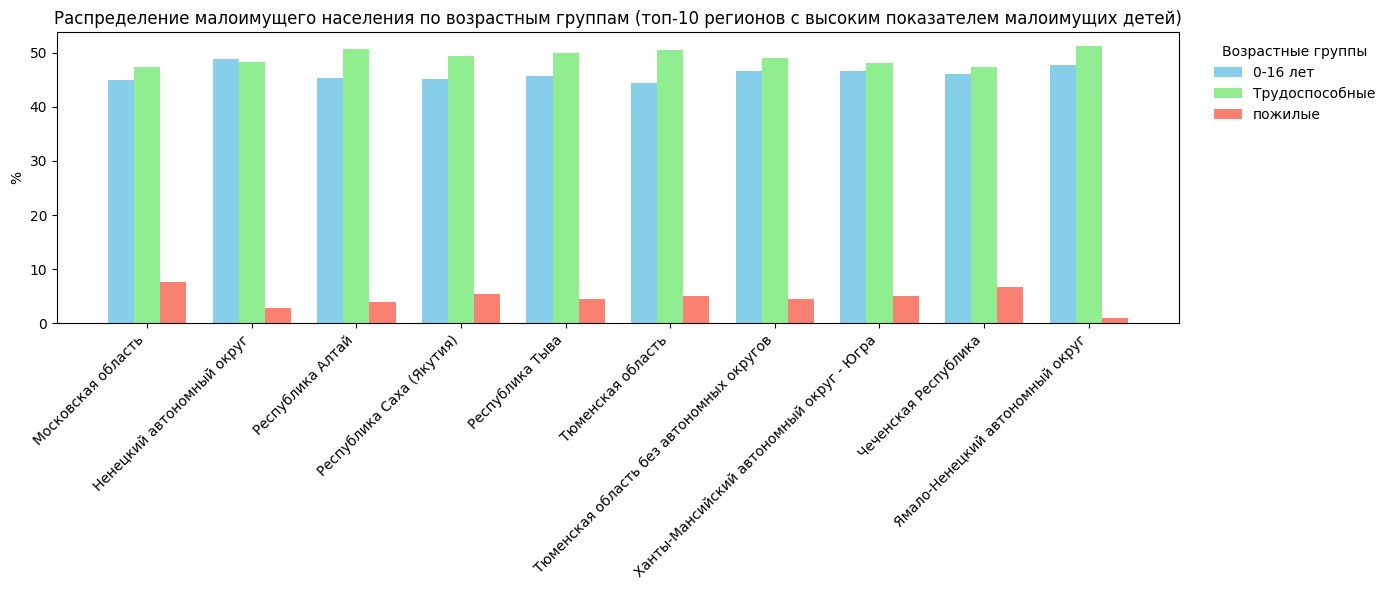

In [243]:


# берём топ-10 по детям (или можешь выбрать по любой категории)
top_regions = pover_grouped.nlargest(10, "Дети в возрасте до 16 лет")["Регион"]

df_top = pover_grouped[pover_grouped["Регион"].isin(top_regions)]

x = np.arange(len(df_top))  # позиции по регионам
width = 0.25  # ширина столбца

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, df_top["Дети в возрасте до 16 лет"], width, label="0-16 лет", color="skyblue")
bars2 = ax.bar(x, df_top["Население трудоспособного возраста"], width, label="Трудоспособные", color="lightgreen")
bars3 = ax.bar(x + width, df_top["Население старше трудоспособного возраста"], width, label="пожилые", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(df_top["Регион"], rotation=45, ha="right")
ax.set_ylabel("%")
ax.set_title("Распределение малоимущего населения по возрастным группам (топ-10 регионов с высоким показателем малоимущих детей)")

# легенду выносим за пределы графика
ax.legend(title="Возрастные группы", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)


plt.tight_layout()
plt.show()



Самый высокий показатель малоимущих детей в Ненецки автономный округ, трудоспособного населения - Ямало-Ненецкий АО.

In [314]:
# переименуем столбцы для дальнейшего объединения 
pover_grouped = pover_grouped.rename(columns={
    'Регион': 'region',
    'Дети в возрасте до 16 лет': 'children_befor16_pover',
    'Население старше трудоспособного возраста': 'retired_pover',
    'Население трудоспособного возраста':'adult_pover'
})

In [244]:
# загрузим дата сет - объём отгруженных товаров собственногопроизводства илиработ/услуг, выполненных собственными силами,по видам деятельности за 2017 -2020 гг

data_reg_prod = pd.read_csv('data/regional_production_2017_2020.csv')

data_reg_prod['2017'] = (data_reg_prod['2017'] / 1e9).round(2)
data_reg_prod['2018'] = (data_reg_prod['2018'] / 1e9).round(2)
data_reg_prod['2019'] = (data_reg_prod['2019'] / 1e9).round(2)
data_reg_prod['2020'] = (data_reg_prod['2020'] / 1e9).round(2)

data_reg_prod.head()

,region,production_field,2017,2018,2019,2020
0,Российская Федерация,ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ,13.92,18.19,18.32,14.50
1,Российская Федерация,Добыча угля,1.23,1.57,1.39,1.10
2,Российская Федерация,Добыча и обогащение угля и антрацита,1.15,1.47,1.30,1.01
3,Российская Федерация,Добыча и обогащение бурого угля (лигнита),0.08,0.09,0.09,0.09
4,Российская Федерация,Добыча нефти и природного газа,9.29,12.87,12.86,8.95


In [245]:
# приведем таблицу к лонг формату, чтобы преобразования

year_cols = [c for c in data_reg_prod.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) приведём имена годовых столбцов к строкам (на всякий случай)
rename_map = {c: str(c) for c in year_cols}
df = data_reg_prod.rename(columns=rename_map)


# 3) лонг-формат (id_vars — сразу два поля)
prod_long = df.melt(
    id_vars=["region", "production_field"],   
    value_vars=[rename_map[c] for c in year_cols],  
    var_name="year",
    value_name="value"
)

# 4) приведение типов
prod_long["year"] = prod_long["year"].astype(int)
prod_long["value"] = pd.to_numeric(prod_long["value"], errors="coerce")

prod_long.head(10)

,region,production_field,year,value
0,Российская Федерация,ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ,2017,13.92
1,Российская Федерация,Добыча угля,2017,1.23
2,Российская Федерация,Добыча и обогащение угля и антрацита,2017,1.15
3,Российская Федерация,Добыча и обогащение бурого угля (лигнита),2017,0.08
4,Российская Федерация,Добыча нефти и природного газа,2017,9.29
5,Российская Федерация,Добыча нефти и нефтяного (попутног...,2017,7.83
6,Российская Федерация,Добыча природного газа и газового ...,2017,1.45
7,Российская Федерация,Добыча металлических руд,2017,1.03
8,Российская Федерация,Добыча и обогащение железных руд,2017,0.35
9,Российская Федерация,Добыча руд цветных металлов,2017,0.68


In [246]:
dubl(prod_long)



Число найденных дубликатов: 0


In [247]:
prod_long.isnull().mean() * 100

region              0.0
production_field    0.0
year                0.0
value               0.0
dtype: float64

In [248]:
prod_long = canon_region_df(prod_long, 'region', region_map)

In [249]:
prod_grouped = (prod_long.groupby(['region', 'production_field'])['value'].mean().reset_index())
prod_grouped.head()

,region,production_field,value
0,Алтайский край,"ВОДОСНАБЖЕНИЕ; ВОДООТВЕДЕНИЕ, ОРГАНИЗАЦИЯ СБОР...",0.0100
1,Алтайский край,ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ,0.0100
2,Алтайский край,"ОБЕСПЕЧЕНИЕ ЭЛЕКТРИЧЕСКОЙ ЭНЕРГИЕЙ, ГАЗОМ И ПА...",0.0450
3,Алтайский край,ОБРАБАТЫВАЮЩИЕ ПРОИЗВОДСТВА,0.3375
4,Алтайский край,Промышленное производство (промышленность),0.4025


In [250]:
prod_grouped['production_field'].nunique()


133

In [251]:
df_prod = prod_grouped.groupby('region')['value'].sum().reset_index()
df_prod = df_prod.rename(columns={'value': 'prod_mean'})
df_prod

,region,prod_mean
0,Алтайский край,0.8050
1,Амурская область,0.3150
2,Архангельская область,1.2775
3,Архангельская область без НАО,0.6275
4,Астраханская область,0.7875
...,...,...
91,Ямало-Ненецкий автономный округ,5.5700
92,Ярославская область,0.8850
93,г. Москва,18.3150
94,г. Санкт-Петербург,5.6550


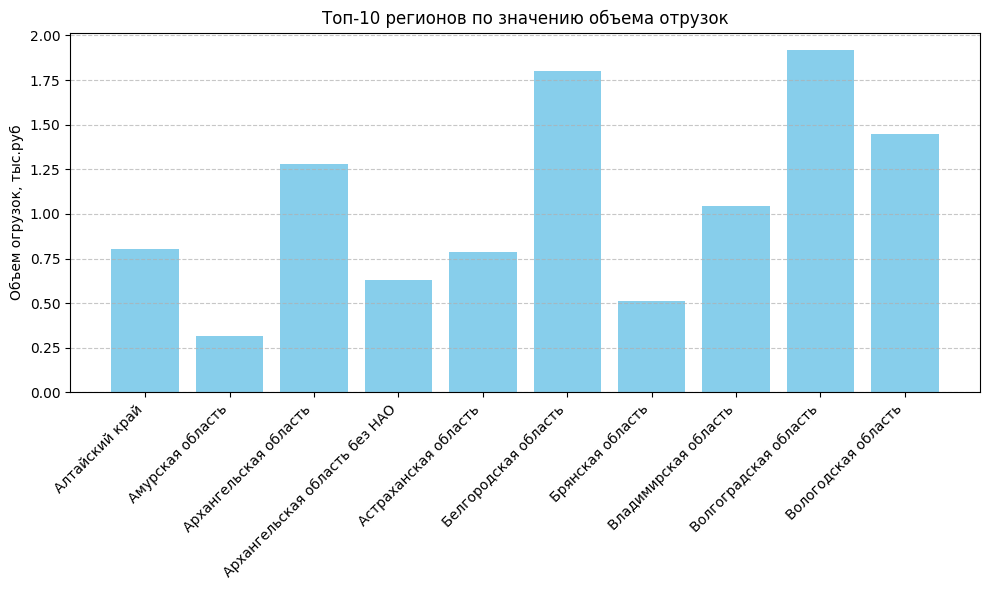

In [252]:
df_prod.sort_values(by='prod_mean', ascending=False)
# топ-10
top10 = df_prod.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["region"], top10["prod_mean"], color="skyblue")

plt.xticks(rotation=45, ha="right")
plt.title("Топ-10 регионов по значению объема отрузок")
plt.ylabel("Объем огрузок, тыс.руб")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()



Максимальные показатели в Волгоградской области и Белгородской области

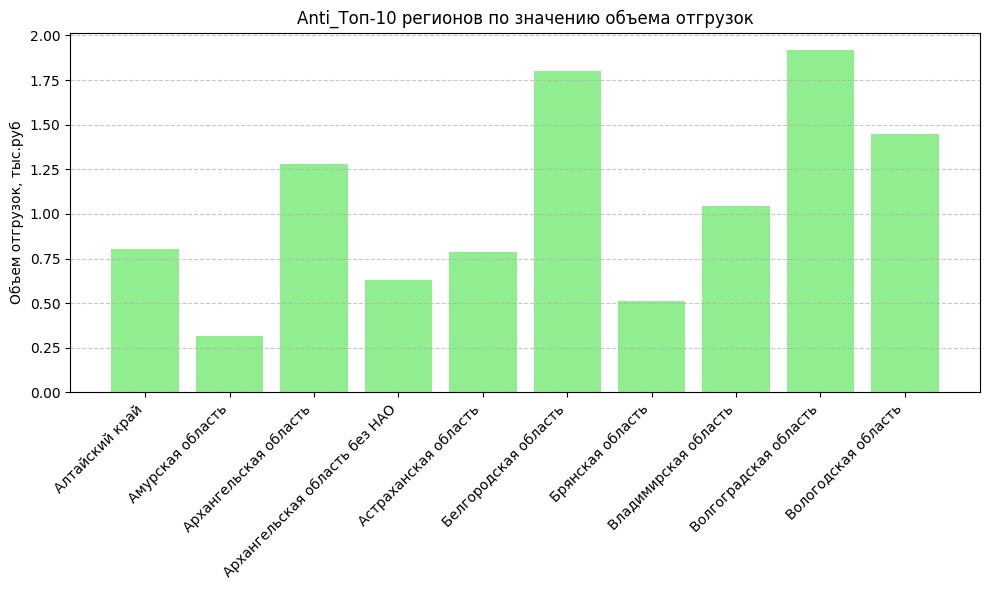

In [253]:
df_prod.sort_values(by='prod_mean', ascending=True)

anti_top10 = df_prod.head(10)

plt.figure(figsize=(10, 6))
plt.bar(anti_top10["region"], top10["prod_mean"], color="lightgreen")

plt.xticks(rotation=45, ha="right")
plt.title("Anti_Топ-10 регионов по значению объема отгрузок")
plt.ylabel("Объем отгрузок, тыс.руб")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Минимальные показатели Амурскя область и Брянская облась.

In [254]:
# оборот розничной торговли на душу населения,
data_retail = pd.read_excel('data/retail_turnover_per_capita_2000_2021.xlsx', skiprows=4, header=None)

data_retail.columns = ['region', 'Currency'] + list(range(2000, 2022))

data_retail.head(5)

,region,Currency,2000,2001,2002,2003,2004,2005,2006,2007,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Российская Федерация,рубль,16046.0,21031.0,25913.0,31557.0,39166.0,49063.0,60901.0,76111.0,...,149401.0,165051.0,180410.0,188017.0,192541.0,202568.0,215074.0,229104.0,231283.0,270606.0
1,Центральный федеральный округ,рубль,26062.0,33630.0,40010.0,46760.0,57011.0,68302.0,81774.0,97965.0,...,188757.0,207394.0,231873.0,237737.0,243426.0,258278.0,277011.0,296368.0,301192.0,354141.0
2,Белгородская область,рубль,11820.0,13837.0,16366.0,19222.0,24168.0,30174.0,41387.0,55460.0,...,129904.0,144992.0,164079.0,178097.0,192504.0,203298.0,217059.0,230704.0,237076.0,259151.0
3,Брянская область,рубль,8267.0,10951.0,14312.0,17988.0,22849.0,28892.0,36931.0,48448.0,...,121136.0,138669.0,158501.0,177048.0,179767.0,192775.0,209987.0,225818.0,225643.0,257679.0
4,Владимирская область,рубль,7442.0,9403.0,10984.0,13357.0,16584.0,21140.0,29719.0,42497.0,...,103848.0,116202.0,129564.0,139408.0,143643.0,153088.0,164519.0,175251.0,177680.0,207670.0


In [255]:
data_retail.isnull().mean() *100 

region       0.000000
Currency     0.000000
2000         5.555556
2001         5.555556
2002         5.555556
2003        11.111111
2004        11.111111
2005        11.111111
2006        11.111111
2007        11.111111
2008        11.111111
2009        11.111111
2010        11.111111
2011        11.111111
2012        11.111111
2013        11.111111
2014         8.333333
2015         7.407407
2016         8.333333
2017         9.259259
2018        11.111111
2019        11.111111
2020        11.111111
2021        11.111111
dtype: float64

In [256]:
# оставим для анализа последние 5 лет

df_retail = data_retail.drop([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 'Currency'], axis=1)

In [257]:
df_retail.isnull().mean() *100 

region     0.000000
2016       8.333333
2017       9.259259
2018      11.111111
2019      11.111111
2020      11.111111
2021      11.111111
dtype: float64

In [258]:
dubl(df_retail)

Число найденных дубликатов: 0


In [259]:
df_retail= canon_region_df(df_retail, 'region', region_map )

In [260]:
# приведем таблицу к лонг формату, чтобы преобразования

year_cols = [c for c in df_retail.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) привести имена годовых колонок к строкам (для стабильного melt)
rename_map = {c: str(c) for c in year_cols}
retail_long = (
    df_retail
    .rename(columns=rename_map)
    .melt(
        id_vars=["region"],
        value_vars=[rename_map[c] for c in year_cols],  # теперь точно есть в DF
        var_name="year",
        value_name="value"
    )
)
retail_long["year"] = retail_long["year"].astype(int)

retail_long.head(10)

,region,year,value
0,Российская Федерация,2016,192541.0
1,Центральный Федеральный Округ,2016,243426.0
2,Белгородская область,2016,192504.0
3,Брянская область,2016,179767.0
4,Владимирская область,2016,143643.0
5,Воронежская область,2016,208638.0
6,Ивановская область,2016,143568.0
7,Калужская область,2016,175286.0
8,Костромская область,2016,144117.0
9,Курская область,2016,169082.0


In [261]:
retail_grouped = retail_long.groupby('region')['value'].mean().round(2).reset_index()

retail_grouped = retail_grouped.rename(columns={'value': 'retail_mean'})

In [262]:
mask_totals = retail_grouped["region"].str.strip().isin([
    "Агинский Бурятский округ",
    "Центральный Федеральный Округ",
    "Усть-Ордынский Бурятский округ",
    "Коми-Пермяцский округ",
    "Коми-Пермяцкий Округ",
    "Корякский Округ",
    "Таймырский (Долгано-Ненецкий) Автономный Округ",
    "Эвенкийский автономный округ (Красноярский край)"
    
])
retail_grouped = retail_grouped[~mask_totals].reset_index(drop=True)
retail_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   region       95 non-null     object 
 1   retail_mean  95 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [263]:
# проверим регионы с пустыми значениями 
retail_grouped[retail_grouped["retail_mean"].isna()]

,region,retail_mean


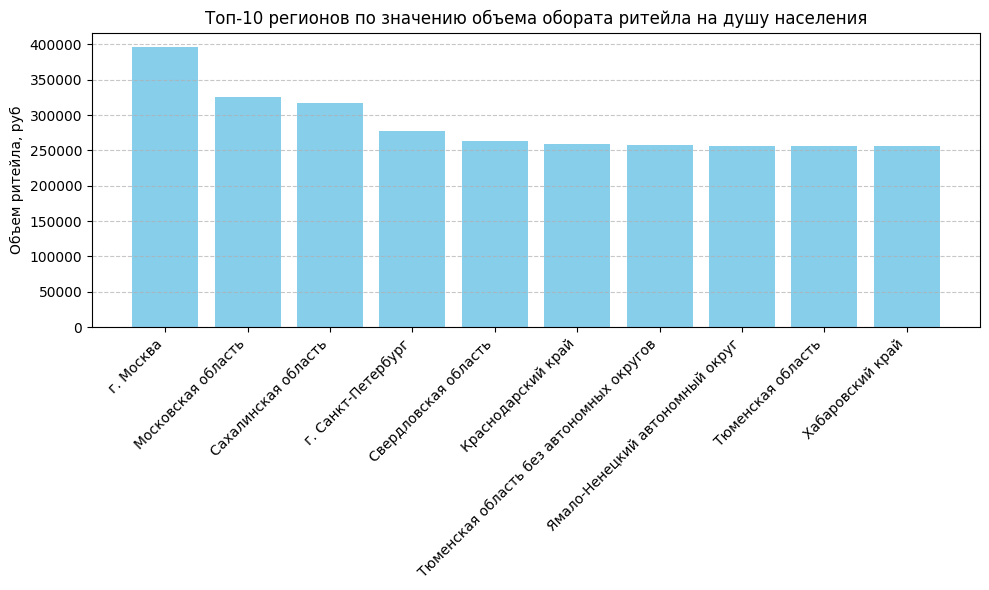

In [264]:
retail_sorted_top = retail_grouped.sort_values(by='retail_mean', ascending=False)
# топ-10
top10 = retail_sorted_top.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["region"], top10["retail_mean"], color="skyblue")

plt.xticks(rotation=45, ha="right")
plt.title("Топ-10 регионов по значению объема обората ритейла на душу населения")
plt.ylabel("Объем ритейла, руб")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


Москва - регион с самым высоким объемом ритейла на душу населения.

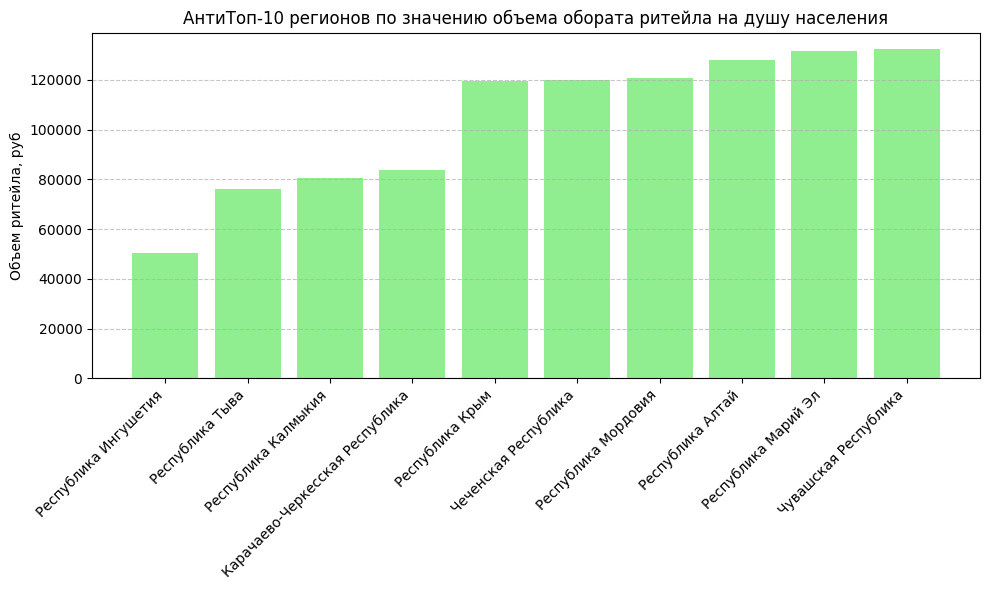

In [265]:
retail_sorted_anti= retail_grouped.sort_values(by='retail_mean', ascending=True)
# топ-10
anti_top10 = retail_sorted_anti.head(10)

plt.figure(figsize=(10, 6))
plt.bar(anti_top10["region"], anti_top10["retail_mean"], color="lightgreen")

plt.xticks(rotation=45, ha="right")
plt.title("АнтиТоп-10 регионов по значению объема обората ритейла на душу населения")
plt.ylabel("Объем ритейла, руб")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


Республика Ингушетия - регион с самым низким ритейлом на душу населения

In [266]:
# расходы на социальную политику от общих расходов бюджета региона, % в год

data_welfare = pd.read_excel('data/welfare_expense_share_2015_2020.xlsx')
data_welfare.head(5)

,region,2015,2016,2017,2018,2019,2020
0,Российская Федерация,15.8,16.6,20.4,20.3,19.8,21.3
1,Центральный\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
2,Белгородская область,11.3,11.8,16.4,15.6,13.8,16.1
3,Брянская область,22.0,26.6,24.7,23.7,20.7,23.1
4,Владимирская область,18.1,18.0,24.0,23.4,23.4,26.0


In [267]:
# приведем таблицу к лонг формату, чтобы преобразования

year_cols = [c for c in data_welfare.columns if re.fullmatch(r"\d{4}", str(c))]

# 2) привести имена годовых колонок к строкам (для стабильного melt)
rename_map = {c: str(c) for c in year_cols}
welfare_long = (
    data_welfare
    .rename(columns=rename_map)
    .melt(
        id_vars=["region"],
        value_vars=[rename_map[c] for c in year_cols],  # теперь точно есть в DF
        var_name="year",
        value_name="value"
    )
)
welfare_long["year"] = welfare_long["year"].astype(int)

welfare_long.head(10)

,region,year,value
0,Российская Федерация,2015,15.8
1,Центральный\n федеральный округ,2015,NaN
2,Белгородская область,2015,11.3
3,Брянская область,2015,22.0
4,Владимирская область,2015,18.1
5,Воронежская область,2015,15.2
6,Ивановская область,2015,18.1
7,Калужская область,2015,14.5
8,Костромская область,2015,14.9
9,Курская область,2015,17.8


In [268]:
welfare_grouped = welfare_long.groupby('region')['value'].mean().round(2).reset_index()
welfare_grouped

,region,value
0,Алтайский край,26.32
1,Амурская область,23.82
2,Архангельская область,20.75
3,Астраханская область,25.10
4,Белгородская область,14.17
...,...,...
89,Ямало-Ненецкий \nавтономный округ,13.12
90,Ярославская область,20.93
91,г. Москва,16.98
92,г. Санкт-Петербург,15.73


In [269]:
# проверим регионы с пустыми значениями 
welfare_grouped[welfare_grouped["value"].isna()]

,region,value
10,Дальневосточный\n федеральный округ,NaN
41,Приволжский\n федеральный округ,NaN
68,Северо-Западный\n федеральный округ,NaN
69,Северо-Кавказский\n федеральный округ,NaN
70,Сибирский\n федеральный округ,NaN
80,Уральский\n федеральный округ,NaN
83,Центральный\n федеральный округ,NaN
88,Южный\n федеральный округ,NaN


In [270]:
mask_totals = welfare_grouped["region"].str.strip().isin([
    "Дальневосточный\n федеральный округ",
    "Приволжский\n федеральный округ",
    "Северо-Западный\n федеральный округ",
    "Северо-Кавказский\n федеральный округ",
    "Сибирский\n федеральный округ",
    "Уральский\n федеральный округ",
    "Центральный\n федеральный округ",
    "Южный\n федеральный округ"
    
])
welfare_grouped = welfare_grouped[~mask_totals].reset_index(drop=True)
welfare_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  86 non-null     object 
 1   value   86 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.5+ KB


In [271]:
dubl(welfare_grouped)

Число найденных дубликатов: 0


In [272]:
welfare_grouped = canon_region_df(welfare_grouped, 'region', region_map)

In [273]:
welfare_grouped[welfare_grouped['region'].str.contains("Арх", case=False, na=False)] 

,region,value
2,Архангельская область,20.75


In [274]:
welfare_grouped = welfare_grouped.rename(columns={'value': 'welfare_mean'})
welfare_grouped["region"] = welfare_grouped["region"].replace({
    "Архангельская область": "Архангельская область без НАО",
    "Тюменская область": "Тюменская область без автономных округов"
})

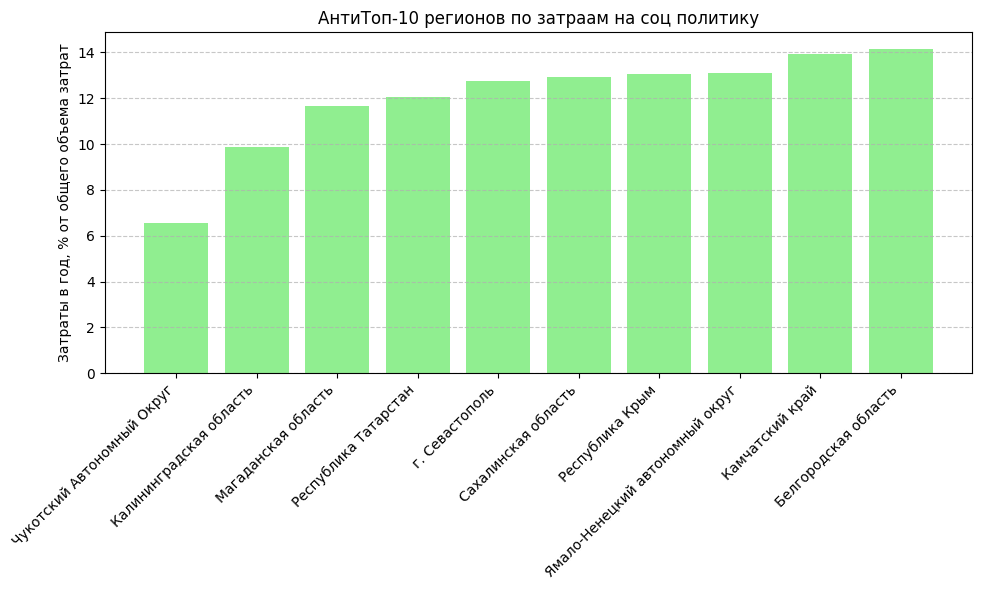

In [275]:
#  посмотрим на регионы с самыми низкими расодами на соц политику
welfare_sorted_anti= welfare_grouped.sort_values(by='welfare_mean', ascending=True)
# топ-10
anti_top10 = welfare_sorted_anti.head(10)

plt.figure(figsize=(10, 6))
plt.bar(anti_top10["region"], anti_top10["welfare_mean"], color="lightgreen")

plt.xticks(rotation=45, ha="right")
plt.title("АнтиТоп-10 регионов по затраам на соц политику")
plt.ylabel("Затраты в год, % от общего объема затрат")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Самые низкие заттраты на соц политику  Чукотском АО

In [283]:
# загрузим данные по преступлениям

TARGET_COLS = [
    "region",
    "juveniles_or_with_them",
    "repeat_offenders",
    "convicted_among_them",
    "by_group",
    "by_conspiracy",
    "by_organized_group",
]
def parse_period_from_file(path: str) -> str:
    # Читаем первые 10 строк, все столбцы
    raw = pd.read_excel(path, header=None, nrows=10)
    
    for row in raw.values:
        for cell in row:
            if isinstance(cell, str) and "Период" in cell:
                m = re.search(r"Период\s*:\s*(.+)", cell)
                if m:
                    return m.group(1).strip()
    return "неизвестно"

def extract_year_from_name(name: str):
    m = re.search(r"(20\d{2}|19\d{2})", name)
    return int(m.group(1)) if m else None

def parse_period(sheet_name: str) -> str:
    s = str(sheet_name).lower().replace("ё", "е")
    replacements = {
        "январ": "январь", "феврал": "февраль", "март": "март", "апрел": "апрель",
        "май": "май", "мая": "май", "июн": "июнь", "июл": "июль", "авг": "август",
        "сентябр": "сентябрь", "октябр": "октябрь", "ноябр": "ноябрь", "декабр": "декабрь",
        "полугод": "полугодие", "год": "год"
    }
    for k, v in replacements.items():
        if k in s:
            return v
    return sheet_name

def clean_numbers(s):
    if pd.isna(s):
        return pd.NA
    if isinstance(s, (int, float)):
        return s
    s = str(s).replace("\u00A0", "").replace(" ", "").replace(",", ".")
    if s in ["", "-", "—", "–"]:
        return pd.NA
    try:
        val = float(s)
        return int(val) if val.is_integer() else val
    except Exception:
        return pd.NA

def parse_first_sheet_only(path: str) -> pd.DataFrame:
    """
    Для файлов формата 4-EGS…:
    - читаем ТОЛЬКО первый лист
    - пропускаем 12 строк с шапкой
    - регионы находятся во 2-м столбце
    """
    xls = pd.ExcelFile(path)
    sheet = xls.sheet_names[0]  # только первый лист
    df = pd.read_excel(xls, sheet_name=sheet, skiprows=12)

    # Регион во 2-м столбце; далее 6 числовых показателей
    df = df.iloc[:, 1:8].copy()
    df.columns = TARGET_COLS

    # фильтрация мусора и приведение чисел
    df = df[df["region"].notna()]
    df["region"] = df["region"].astype(str).str.strip()
    drop_mask = df["region"].str.lower().str.contains("примеч|итого|всего|форма|таблица", na=False)
    df = df[~drop_mask]
    for c in TARGET_COLS[1:]:
        df[c] = df[c].apply(clean_numbers)

    # метаданные
    df["year"]   = extract_year_from_name(os.path.basename(path))
    df["period"] = parse_period_from_file(path)

    # убираем полностью пустые строки по показателям
    df = df.dropna(subset=TARGET_COLS[1:], how="all").reset_index(drop=True)
    return df

In [ ]:

# Папка с исходными файлами crimes
FOLDER = r"data/crimes/crimes"
# сохраняем обработанный файл
OUT_CSV = r"data/crimes/crimes/crimes_all_cleaned.csv"

all_files = glob(os.path.join(FOLDER, "*.xls*"))  # все .xls и .xlsx
frames = []

for f in all_files:
    try:
        df = parse_first_sheet_only(f)  # функция из прошлого ответа
        if not df.empty:
            frames.append(df)
        else:
            print(f"❗ Пустой результат: {os.path.basename(f)}")
    except Exception as e:
        print(f"⚠ Ошибка в {os.path.basename(f)}: {e}")

# Склеиваем всё в один датафрейм
if frames:
    result = pd.concat(frames, ignore_index=True)
    result.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
    print(f"✅ Готово! Сохранено: {OUT_CSV}, строк: {len(result)}")
else:
    print("❌ Ни один файл не обработан.")


In [284]:
data_crime = pd.read_csv('data/crimes/crimes/crimes_all_cleaned.csv')
data_crime

,region,juveniles_or_with_them,repeat_offenders,convicted_among_them,by_group,by_conspiracy,by_organized_group,year,period
0,Центральный федеральный округ,533,11208,6496,128,1795,770,2016,январь 2016 года
1,Белгородская область,14,393,217,3,50,10,2016,январь 2016 года
2,Брянская область,27,484,248,5,53,15,2016,январь 2016 года
3,Владимирская область,44,523,301,10,98,29,2016,январь 2016 года
4,Воронежская область,50,743,350,5,113,1,2016,январь 2016 года
...,...,...,...,...,...,...,...,...,...
7965,УТ МВД по Приволжскому ФО,43,1473,593,7,479,55,2021,январь - декабрь 2021 года
7966,УТ МВД по Сибирскому ФО,19,1456,720,22,481,31,2021,январь - декабрь 2021 года
7967,УТ МВД по Северо-Западному ФО,8,824,447,18,403,38,2021,январь - декабрь 2021 года
7968,УТ МВД по Дальневосточному ФО,3,897,294,4,150,78,2021,январь - декабрь 2021 года


In [285]:
# Регулярка для "январь - декабрь 20XX года" (с разными тире)
mask = data_crime["period"].str.contains(
    r"январ[ья]\s*[-—–]\s*декабр[ья]\s+\d{4}\s+года",
    flags=re.IGNORECASE,
    na=False
)

# Оставляем только полные годы
data_crime_year= data_crime[mask].reset_index(drop=True)
    

In [286]:
data_crime_year[data_crime_year['region'].str.contains("Тюменская", case=False, na=False)] 


,region,juveniles_or_with_them,repeat_offenders,convicted_among_them,by_group,by_conspiracy,by_organized_group,year,period
66,Тюменская область,677,8733,4478,64,882,61,2016,январь - декабрь 2016 года
168,Тюменская область,643,8480,4619,45,827,57,2017,январь - декабрь 2017 года
270,Тюменская область,562,8503,4912,53,727,80,2018,январь - декабрь 2018 года
372,Тюменская область,532,8476,4842,52,736,128,2019,январь - декабрь 2019 года
474,Тюменская область,448,8028,4458,50,762,16,2020,январь - декабрь 2020 года
576,Тюменская область,433,7992,4384,27,667,55,2021,январь - декабрь 2021 года


In [ ]:
# объединим все престуупления, свершенные группой в один признак
data_crime_year['by_group_sum'] = data_crime_year['by_group'] + data_crime_year['by_conspiracy'] + data_crime_year['by_organized_group']

In [288]:
data_crime_fin = data_crime_year.drop(['by_group', 'by_conspiracy', 'by_organized_group', 'period'], axis=1)

In [289]:
data_crime_fin.isnull().mean()* 100

region                    0.0
juveniles_or_with_them    0.0
repeat_offenders          0.0
convicted_among_them      0.0
year                      0.0
by_group_sum              0.0
dtype: float64

In [323]:
# приведем навзвание регионов к общему формату к обще
data_crime_fin = canon_region_df(data_crime_fin, 'region', region_map)

In [324]:
#  удалим все округи, чтобы не мешали дальнейшему анализу по регионам
mask_totals = data_crime_fin["region"].str.strip().isin([
    "Приволжский Федеральный Округ",
    "Центральный Федеральный Округ",
    "Сибирский Фдеральный Округ",
    "Дальневосточный Федеральный Округ", 
    "Северо-Западный Федеральный Округ", 
    "Северо-Кавказский федеральный округ",
    "Приволжский федеральный округ",
    "Уральский федеральный округ",
    "Южный Федеральный Округ",
    "Северо-Кавказский Федеральный Округ",
    
    
])

data_crime_fin = data_crime_fin[~mask_totals].reset_index(drop=True)

data_crime_fin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   region                  564 non-null    object
 1   juveniles_or_with_them  564 non-null    int64 
 2   repeat_offenders        564 non-null    int64 
 3   convicted_among_them    564 non-null    int64 
 4   year                    564 non-null    int64 
 5   by_group_sum            564 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 26.6+ KB


In [325]:
# так у нас в статистике фгуриют Архангельская обл без НАО и Тюменская обл без АО, переименуем регионы в дата сете
data_crime_fin["region"] = data_crime_fin["region"].replace({
    "Архангельская область": "Архангельская область без НАО",
    "Тюменская область": "Тюменская область без автономных округов"
})

In [326]:
# сгруппируем данные по регионам со средними показателями преступности
crime_grouped = data_crime_fin.groupby('region').agg({
    'juveniles_or_with_them': 'mean',
    'repeat_offenders': 'mean',
    'convicted_among_them': 'mean',
    'by_group_sum': 'mean'
}).reset_index().round(2)

crime_grouped

,region,juveniles_or_with_them,repeat_offenders,convicted_among_them,by_group_sum
0,Алтайский край,1023.83,16855.33,7659.50,1340.67
1,Амурская область,548.50,6604.50,3247.50,620.33
2,Архангельская область без НАО,601.00,6546.17,3455.67,1184.33
3,Астраханская область,339.50,5333.67,2825.67,841.67
4,Белгородская область,234.33,4436.33,2603.33,587.00
...,...,...,...,...,...
89,Ямало-Ненецкий автономный округ,132.83,2247.17,1165.17,289.67
90,Ярославская область,341.17,5116.17,2772.33,837.50
91,г. Москва,556.83,16558.00,10033.83,8205.83
92,г. Санкт-Петербург,535.67,11281.67,6682.17,1971.83


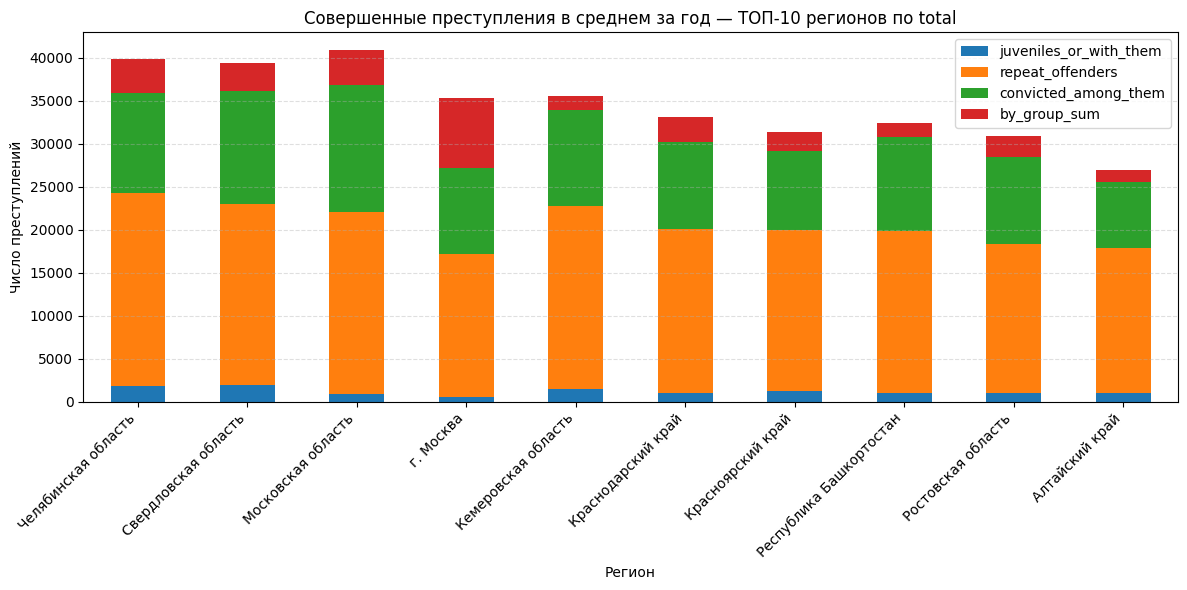

In [327]:
#  посмотрим на регионы с самыми высоким показателем преступности
# создадим копию
plot_crime = crime_grouped.copy()

#добавим общую сумму преступлений за год
plot_crime['total'] = plot_crime['juveniles_or_with_them'] + plot_crime['repeat_offenders'] + plot_crime['by_group_sum'] 

# берём топ-10 по total
top10 = plot_crime.nlargest(10, "total").set_index("region")

crime_cols = ["juveniles_or_with_them", "repeat_offenders", "convicted_among_them", "by_group_sum"]

ax = top10[crime_cols].plot(kind="bar", stacked=True, figsize=(12,6))
ax.set_title("Совершенные преступления в среднем за год — ТОП-10 регионов по total")
ax.set_xlabel("Регион")
ax.set_ylabel("Число преступлений")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# правим подписи
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.tight_layout()
plt.show()

Самые высокие показатели прстуности в Московской, Челябинской и Свердлдовской областях.

Соберем единый дата фрейм для дальнейшего анализа и кластеризации

In [328]:
data = {'region':
    ["Республика Алтай",
     "Республика Адыгея (Адыгея)",
    "Республика Башкортостан",
    "Республика Бурятия",
    "Республика Дагестан",
    "Республика Ингушетия",
    "Кабардино-Балкарская Республика",
    "Республика Калмыкия",
    "Карачаево-Черкесская Республика",
    "Республика Карелия",
    "Республика Коми",
    "Республика Крым",
    "Республика Марий Эл",
    "Республика Мордовия",
    "Республика Саха (Якутия)",
    "Республика Северная Осетия-Алания",
    "Республика Татарстан",
    "Республика Тыва",
    "Республика Хакасия",
    "Удмуртская Республика",
    "Чеченская Республика",
    "Чувашская Республика",
    "Алтайский край",
    "Забайкальский край",
    "Камчатский край",
    "Краснодарский край",
    "Красноярский край",
    "Пермский край",
    "Приморский край",
    "Ставропольский край",
    "Хабаровский край",
    "Амурская область",
    "Архангельская область без НАО",
    "Белгородская область",
    "Брянская область",
    "Владимирская область",
    "Волгоградская область",
    "Вологодская область",
    "Воронежская область",
    "Ивановская область",
    "Иркутская область",
    "Калининградская область",
    "Калужская область",
    "Кемеровская область",
    "Кировская область",
    "Костромская область",
    "Курганская область",
    "Курская область",
    "Ленинградская область",
    "Липецкая область",
    "Магаданская область",
    "Московская область",
    "Мурманская область",
    "Нижегородская область",
    "Новгородская область",
    "Новосибирская область",
    "Омская область",
    "Оренбургская область",
    "Орловская область",
    "Пензенская область",
    "Псковская область",
    "Ростовская область",
    "Рязанская область",
    "Самарская область",
    "Саратовская область",
    "Сахалинская область",
    "Свердловская область",
    "Смоленская область",
    "Тамбовская область",
    "Тверская область",
    "Томская область",
    "Тульская область",
    "Тюменская область без автономных округов",
    "Ульяновская область",
    "Челябинская область",
    "Ярославская область",
    "г. Москва",
    "г. Санкт-Петербург",
    "г. Севастополь",
    "Еврейская автономная область",
    "Ненецкий автономный округ",
    "Ханты-Мансийский автономный округ - Югра",
    "Чукотский автономный округ",
    "Ямало-Ненецкий автономный округ"
]}

df = pd.DataFrame(data, columns=['region'])
df

,region
0,Республика Алтай
1,Республика Адыгея (Адыгея)
2,Республика Башкортостан
3,Республика Бурятия
4,Республика Дагестан
...,...
79,Еврейская автономная область
80,Ненецкий автономный округ
81,Ханты-Мансийский автономный округ - Югра
82,Чукотский автономный округ


In [329]:
# приведем список регионов к основному формату
df = canon_region_df(df, 'region', region_map)

In [331]:


# Подготовим список дата сетов
frames = [
    cash_mean, 
    cmr_mean, 
    cmu_mean, 
    dis_grouped, 
    data_alco_sum, 
    data_drug_sum, 
    gp_mean, 
    data_housing,
    morbidity_df,
    nwbn_mean,
    popul_2022,
    grouped_percent_pover,
    pover_grouped,
    df_prod,
    retail_grouped,
    welfare_grouped,
    crime_grouped
    
]

# Склеиваем всё в один общий df
data_merged = reduce(
    lambda left, right: pd.merge(left, right, on="region", how="left"),
    [df] + frames   # начинаем с твоего базового df
)

print(data_merged.shape)


(84, 35)


In [332]:
data_merged

,region,cash_mean,cmr_mean,cmu_mean,18_30_disab,31_40_disab,41_50_disab,51_60_disab,over_60_disab,alco_sum,...,children_befor16_pover,retired_pover,adult_pover,prod_mean,retail_mean,welfare_mean,juveniles_or_with_them,repeat_offenders,convicted_among_them,by_group_sum
0,Республика Алтай,19304.17,24.57,6.86,981.61,1689.03,2102.88,3680.45,13002.91,1625.4,...,45.38,3.90,50.70,0.0100,128124.50,17.27,156.17,2291.83,1003.50,161.00
1,Республика Адыгея,26924.67,12.71,12.14,1471.89,2425.19,3747.36,6769.39,18697.19,1167.6,...,40.08,9.60,50.35,0.1075,221616.00,19.58,95.00,1470.50,728.67,233.00
2,Республика Башкортостан,28903.33,135.57,161.43,11407.53,16441.48,20459.16,41559.58,160204.62,1325.3,...,40.10,5.50,54.42,3.2550,221927.50,18.83,993.33,18879.67,10862.00,1674.83
3,Республика Бурятия,24480.33,41.71,43.57,4420.75,7241.56,8140.08,13449.23,40531.12,862.2,...,43.50,4.95,51.58,0.2800,189867.00,20.80,756.33,8359.50,3560.17,784.67
4,Республика Дагестан,26623.33,268.86,167.86,36471.12,44024.89,59044.53,77186.12,81064.08,307.7,...,39.90,6.52,53.55,0.1400,195425.00,25.23,254.33,4317.50,2162.83,977.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Еврейская автономная область,24975.50,8.86,12.57,713.66,1186.83,1316.50,1840.70,7493.17,2301.1,...,34.12,9.65,56.22,0.0475,157348.67,24.85,86.83,1020.83,571.50,91.67
80,Ненецкий автономный округ,76707.67,1.00,1.71,134.78,212.70,298.58,506.80,1733.44,3209.9,...,48.87,2.83,48.27,0.6425,220871.33,14.98,33.83,269.33,146.50,41.33
81,Ханты-Мансийский автономный округ - Югра,50059.50,7.86,87.86,3967.86,5727.16,6423.56,11219.81,23581.84,1547.1,...,46.72,5.05,48.20,8.3675,254311.83,14.85,420.33,6578.17,3139.33,846.17
82,Чукотский Автономный Округ,75961.83,5.29,3.14,174.78,224.58,277.00,389.20,546.89,6295.0,...,32.63,0.90,33.13,0.1850,197298.33,6.55,18.00,309.50,131.17,19.00


In [333]:
data_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  84 non-null     object 
 1   cash_mean               84 non-null     float64
 2   cmr_mean                84 non-null     float64
 3   cmu_mean                84 non-null     float64
 4   18_30_disab             84 non-null     float64
 5   31_40_disab             84 non-null     float64
 6   41_50_disab             84 non-null     float64
 7   51_60_disab             84 non-null     float64
 8   over_60_disab           84 non-null     float64
 9   alco_sum                84 non-null     float64
 10  drug_sum                84 non-null     float64
 11  vrp_mean                84 non-null     float64
 12  good_cond_house         84 non-null     float64
 13  not_good_cond_house     84 non-null     float64
 14  bad_cond_house          84 non-null     floa

In [ ]:
# на всякий случай проверим на наличие дубликатов
dubl(data_merged)

Число найденных дубликатов: 0


In [ ]:
# на всякий случай проверим на наличие пропусков
data_merged.isnull().sum().sum()

0

In [334]:
data_merged.describe()

,cash_mean,cmr_mean,cmu_mean,18_30_disab,31_40_disab,41_50_disab,51_60_disab,over_60_disab,alco_sum,drug_sum,...,children_befor16_pover,retired_pover,adult_pover,prod_mean,retail_mean,welfare_mean,juveniles_or_with_them,repeat_offenders,convicted_among_them,by_group_sum
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,...,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,30174.628333,32.390952,72.607143,5953.400238,9312.785476,12414.875952,22476.021667,82128.506429,1557.857143,185.251190,...,38.511190,6.190238,53.412619,1.603869,191832.886429,20.305000,496.927024,7371.135000,4057.428214,1079.902976
std,12824.394469,38.469523,87.991469,6187.461849,8901.176108,11940.863391,21703.422407,99705.203276,906.772220,110.104641,...,5.226209,2.119623,4.951305,2.461327,54527.275459,4.110912,398.275221,5750.598055,3308.437243,1151.591966
min,16064.170000,0.000000,1.710000,134.780000,212.700000,277.000000,389.200000,546.890000,10.000000,29.400000,...,16.830000,0.900000,29.030000,0.007500,50579.330000,6.550000,10.330000,269.330000,131.170000,19.000000
25%,23318.582500,12.710000,28.285000,2734.727500,3967.187500,5882.600000,10441.257500,33331.592500,1074.250000,103.425000,...,36.065000,4.950000,51.482500,0.346250,158793.750000,18.802500,232.830000,3258.497500,1786.002500,407.082500
50%,26744.580000,19.785000,43.430000,3813.505000,6228.500000,8133.245000,15633.635000,59729.095000,1500.550000,159.900000,...,39.375000,5.660000,54.490000,0.791250,190093.750000,21.115000,374.170000,5109.085000,2774.165000,758.835000
75%,30734.750000,37.002500,88.035000,6933.855000,11827.437500,15707.962500,29344.292500,103801.677500,1873.500000,240.575000,...,41.402500,7.525000,55.985000,1.870000,224191.920000,22.972500,649.497500,9883.705000,5546.167500,1359.670000
max,78070.500000,268.860000,665.860000,36471.120000,44024.890000,65045.720000,141911.840000,726118.500000,6295.000000,481.200000,...,48.870000,10.980000,61.420000,18.315000,396943.830000,27.320000,1934.500000,22514.500000,14745.500000,8205.830000


Тепрь все наши данные представленные в одной таблице. 

* **cash_mean** - годовой средний показатель среднедушевного дохода в месяц (2015 -2020 гг), руб
* **cmr_mean** - годовой средний показатель смертности детей на первом году жизни в сельской местности (2015-2021 гг), кол-во чел
* **cmu_mean** - годовой средний показатель смертности детей на первом году жизни в городской местности (20015-2021 гг), кол-во чел
* **18_30_disab** - годовой средний показатель людей с инвалидностью  возрастной группе 18-30 (2017 - 2022 гг), кол-во чел
* **31_40_disab** - годовой средний показатель людей с инвалидностью  возрастной группе 31-40 (2017 - 2022 гг), кол-во чел
* **41_50_disab** - годовой средний показатель людей с инвалидностью  возрастной группе 41-50 (2017 - 2022 гг), кол-во чел	
* **51_60_disab** - годовой средний показатель людей с инвалидностью  возрастной группе 51-60 (2017 - 2022 гг), кол-во чел
* **over_60_disab**	- годовой средний показатель людей с инвалидностью  возрастной группе свыше 60 (2017 - 2022 гг), кол-во чел
* **alco_sum** - показатель заболеваний алкоголизмом на 100 тыс. населения суммированный показатель с 2008 по 2018 гг
* **drug_sum** - показатель заболеваний наркоманией на 100 тыс. населения суммированный показатель с 2008 по 2018 гг
* **vrp_mean** - средний годовой показатель Внутреннего Региональого Продукта
* **good_cond_house** - средний годовой показатель в процентах жилищных хозяйств, не испытыввающих стесненности 
* **not_good_cond_house** - показатель в процентах жилищных хозяйств, испытыввающих определенную стесненность
* **bad_cond_house** - показатель в процентах жилищных хозяйств, испытыввающих большую степерь стесненности
* **no_answer_cond_house** - средний годовой показатель в процентах жилищных хозяйств, затруднившихся ответить
* **total_area_per_member** - размер общей площади в расчете на члена домохозяйства
* **livng_area_per_member** - размер жилой площади в расчете на члена домохозяйства
* **living_room_quantity** - число жилых комнат в расчете на одно домохозяйство
* **0-14_dieses** - средний годовой показатель забоволеваемости на 100 тыс. чел в возрастной гуппе 0-14 лет (2005 - 2016 гг), кол-во 
* **15_17_dieses** - средний годовой показатель забоволеваемости на 100 тыс. чел в возрастной гуппе 15-17 лет (2005 - 2016 гг), кол-во 
* **18_and_over_dieses**  - средний годовой показатель забоволеваемости на 100 тыс. чел в возрастной гуппе от 18 лет и выше (2005 - 2016 гг), кол-во 
* **nwbn_mean** - средний годовой показатель числа новорожденных, кол-во чел
* **popul_01_22** - показатель населения на январь 2022 года, кол-во чел
* **poverty_percent** - средний процент бедности населения по регионам (1992-2020 гг)
* **children_befor16_pover** - средний процент бедности населения по регионам в возрастной группе *дети до 16 лет* (2017-2020 гг)
* **retired_pover**  - средний процент бедности населения по регионам в возрастной группе *пожилые люди* (2017-2020 гг)
* **adult_pover**  - средний процент бедности населения по регионам в возрастной группе *трудоспособное население* (2017-2020 гг)
* **prod_mean** - средний годовой показатель объема отруженного товара собственного производства (2017 -2020), тыс. руб
* **retail_mean** - средний годовой показатель оборота розничной торговли на душу населения (2016 - 2021), руб
* **welfare_mean** - среднегодовой показатель расходов на соц политику % от общих расходов региона (2015 -2020)
* **juveniles_or_with_them** - средний годовой показатель преступлений с участием несовершеннолетних (2016 -2022)
* **repeat_offenders** - средний годовой показатель повторных преступлений (2016 -2022)
* **convicted_among_them** - средний годовой показатель повторных преступлений с осужденными ранее (2016 -2022)
* **by_group_sum** - средний годовой показатель преступлений, совершенных организованными группами (2016 -2022)

## Часть 2. Статистический анализ

### 2.1 Проверка распределений

Проверим наши признаки на нормальность распределения.

In [339]:

# проводим тест Шапиро — Уилка так как у нас до ~5000 наблюдений


# только числовые признаки
num_cols = data_merged.select_dtypes(include="number").columns

results = {}
for col in num_cols:
    stat, p = stats.shapiro(data_merged[col].dropna())
    results[col] = (p, p > 0.05)   # p-value и решение

# DataFrame с результатами
shapiro_df = pd.DataFrame(results, index=["p_value", "is_normal"]).T

# Считаем количество нормальных / ненормальных
summary = (
    shapiro_df["is_normal"]
    .map({True: "нормальное", False: "не нормальное"})
    .value_counts()
    .rename_axis(None)  # убираем лишний индекс "is_normal"
)

# два списка
normal_cols = [col for col, is_norm in results.items() if is_norm]
non_normal_cols = [col for col, is_norm in results.items() if not is_norm]


print("Summary:")
print(summary.to_string())


Summary:
не нормальное    30
нормальное        4


### 2.2 Корреляционный анализ

Итак у нас получается 30 признаков с не нормальным распределением и 4 с нормалным. Так как большинство признаков имеет ненормальное распределение для корреляцонного анализа будем использовать метод Спирмена.

<Axes: >

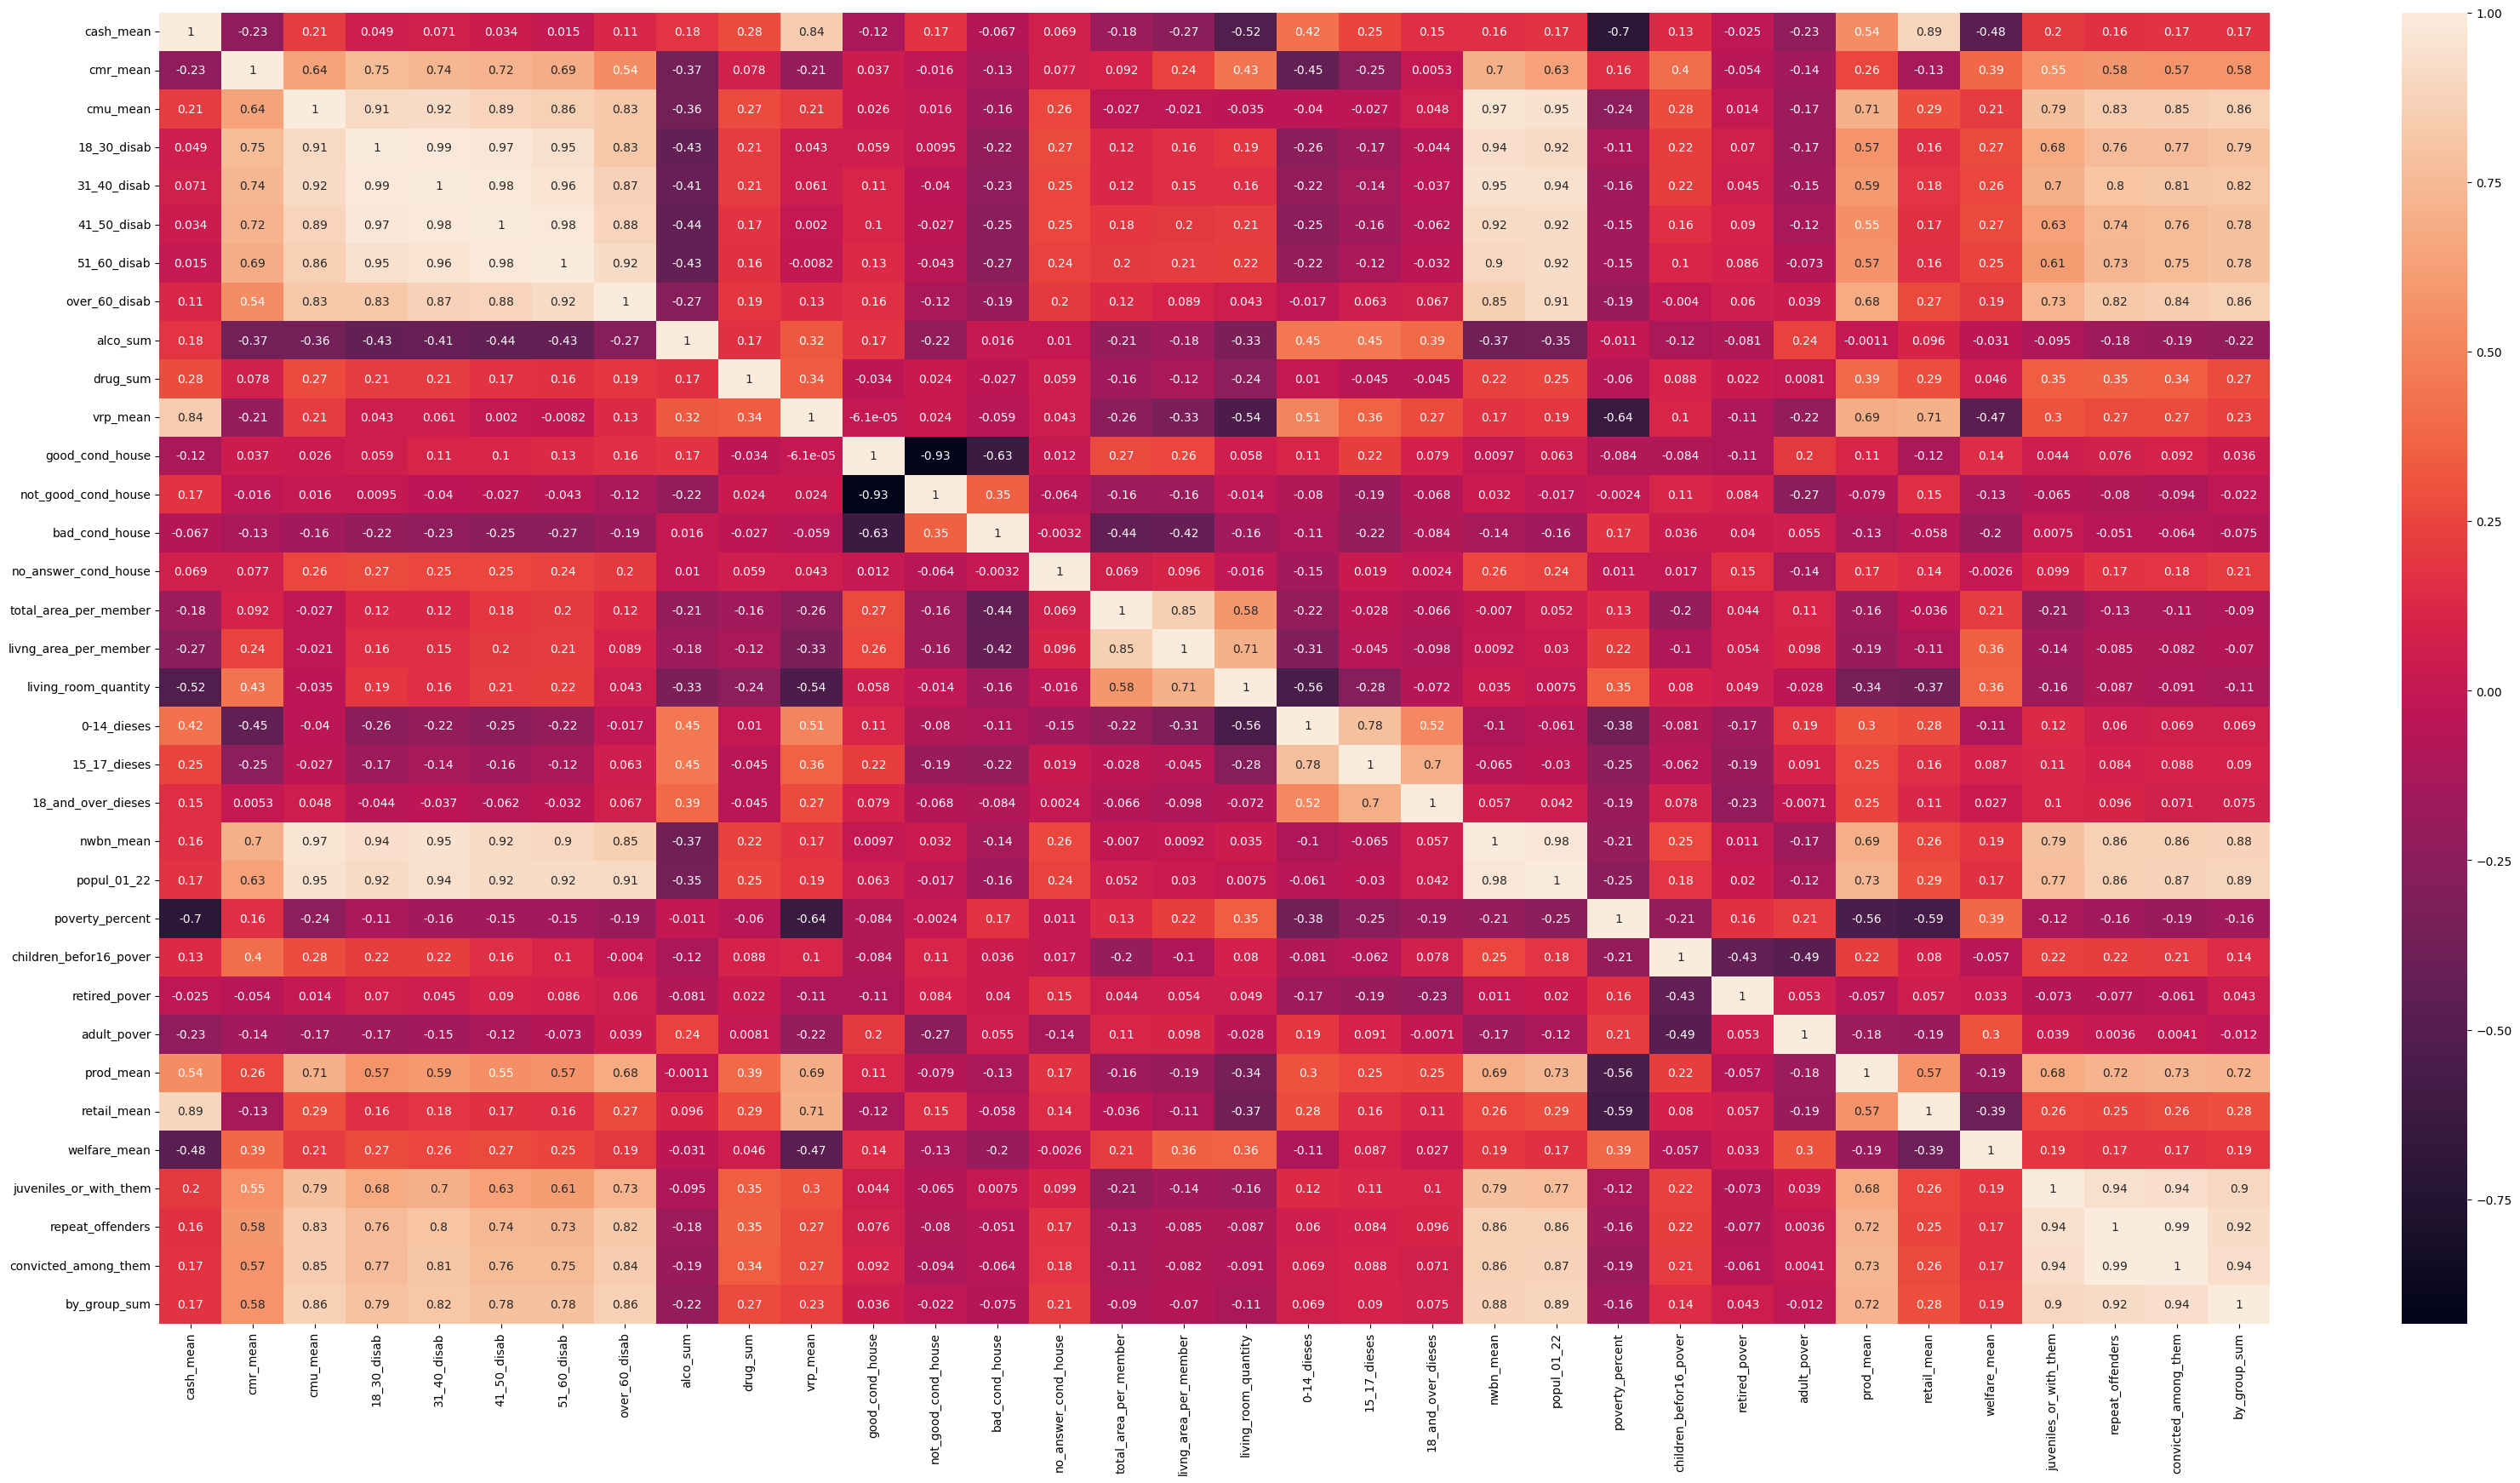

In [340]:
# посмотрим на корреляцю можду признаками
plt.rcParams['figure.figsize'] = (40,20)
sns.heatmap(data_merged.corr(numeric_only=True, method='spearman'), annot=True)

По данным тепловой карты небольшую корреляцию с проценом бедности имеют  4 признака: доход на душу населения, валовый внетренний продукт, оборот товаров собственного производства, оборот розничной торговли.

In [341]:
# проверим наши признаки на влияние статистической значимости с признаком процент бедности в регионе

target = "poverty_percent"
num_cols = [c for c in data_merged.columns if c not in ["region", target]]

results = []

for col in num_cols:
    x = data_merged[col].dropna()
    y = data_merged[target].dropna()
    common_idx = x.index.intersection(y.index)
    stat, p = stats.spearmanr(x.loc[common_idx], y.loc[common_idx])
    results.append((col, stat, p))

df_results = pd.DataFrame(results, columns=["feature", "spearman_corr", "p_value"])
df_results["significant"] = df_results["p_value"] < 0.05

print(df_results.sort_values("p_value").head(10))

                 feature  spearman_corr       p_value  significant
0              cash_mean      -0.700800  1.159114e-13         True
10              vrp_mean      -0.638311  6.507880e-11         True
27           retail_mean      -0.585664  4.861645e-09         True
26             prod_mean      -0.555152  4.243471e-08         True
28          welfare_mean       0.387312  2.729242e-04         True
18           0-14_dieses      -0.376795  4.112051e-04         True
17  living_room_quantity       0.345423  1.290520e-03         True
22           popul_01_22      -0.247140  2.342603e-02         True
19          15_17_dieses      -0.246370  2.387520e-02         True
2               cmu_mean      -0.240027  2.786518e-02         True


По проведенному тесту 10 признаков имеют статистически значимую связь с признаком процента бедности:

* cash_mean (-0.70) → чем выше средний доход (деньги), тем ниже бедность.
* vrp_mean (-0.64) → чем выше валовый региональный продукт, тем ниже бедность.
* retail_mean (-0.59) → чем выше оборот розницы, тем ниже бедность.
* prod_mean (-0.56) → чем выше объем отруженного товара собственного производства, тем ниже бедность.


* welfare_mean (+0.39) → чем выше соц выплаты, тем выше уровень бедности (логично: в бедных регионах выше доля соцвыплат).
* living_room_quantity (+0.35) → чем выше число жилых комнат в расчете на одно домохозяйство, тем выше бедность. интересный результат: может быь связан с наличием знаменитых коммунальных квартир.

* 0-14_dieses (-0.38) и 15_17_dieses (-0.25) → чем больше смертность среди подростков, тем выше бедность (обратная зависимость может быть статистическим артефактом).
* popul_01_22 (-0.25) → численность населения немного связана с бедностью.

**В ИТОГЕ:** 
Уровень бедности в первую очередь обратно связан с доходами, производством и торговлей (сильные отрицательные корреляции).
Прямая зависимость с соц выплатами и жильём на душу населения.

## Часть 3. Кластеризация. Определение уязвимых регионов и грапп населения

In [370]:
# оставим в наших данных, только статистически значимые признаки

df_clust = data_merged[['region', 'cash_mean', 'vrp_mean', 'retail_mean', 'prod_mean', 'living_room_quantity', '0-14_dieses', 'popul_01_22', 'poverty_percent']]
df_clust

,region,cash_mean,vrp_mean,retail_mean,prod_mean,living_room_quantity,0-14_dieses,popul_01_22,poverty_percent
0,Республика Алтай,19304.17,205304.78,128124.50,0.0100,2.4,16415.17,221559.0,32.93
1,Республика Адыгея,26924.67,211819.63,221616.00,0.1075,3.1,12668.97,468340.0,25.48
2,Республика Башкортостан,28903.33,345002.88,221927.50,3.2550,2.4,18528.60,4001678.0,17.69
3,Республика Бурятия,24480.33,222081.98,189867.00,0.2800,2.4,12968.11,982629.0,29.89
4,Республика Дагестан,26623.33,186556.23,195425.00,0.1400,3.6,13039.06,3153857.0,30.82
...,...,...,...,...,...,...,...,...,...
79,Еврейская автономная область,24975.50,293728.43,157348.67,0.0475,2.2,17985.06,153831.0,22.22
80,Ненецкий автономный округ,76707.67,5321754.28,220871.33,0.6425,2.7,37619.58,44540.0,9.05
81,Ханты-Мансийский автономный округ - Югра,50059.50,2025254.76,254311.83,8.3675,2.1,22322.43,1702240.0,7.83
82,Чукотский Автономный Округ,75961.83,1392794.65,197298.33,0.1850,1.7,27321.49,50040.0,11.94


### k_means

In [371]:
#  для начала понизим размерность наших данных
data_cl = df_clust.drop(columns=["region"])

pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=5))])
data_norm = pipe.fit_transform(data_cl)

<Axes: xlabel='cluster', ylabel='silhouette'>

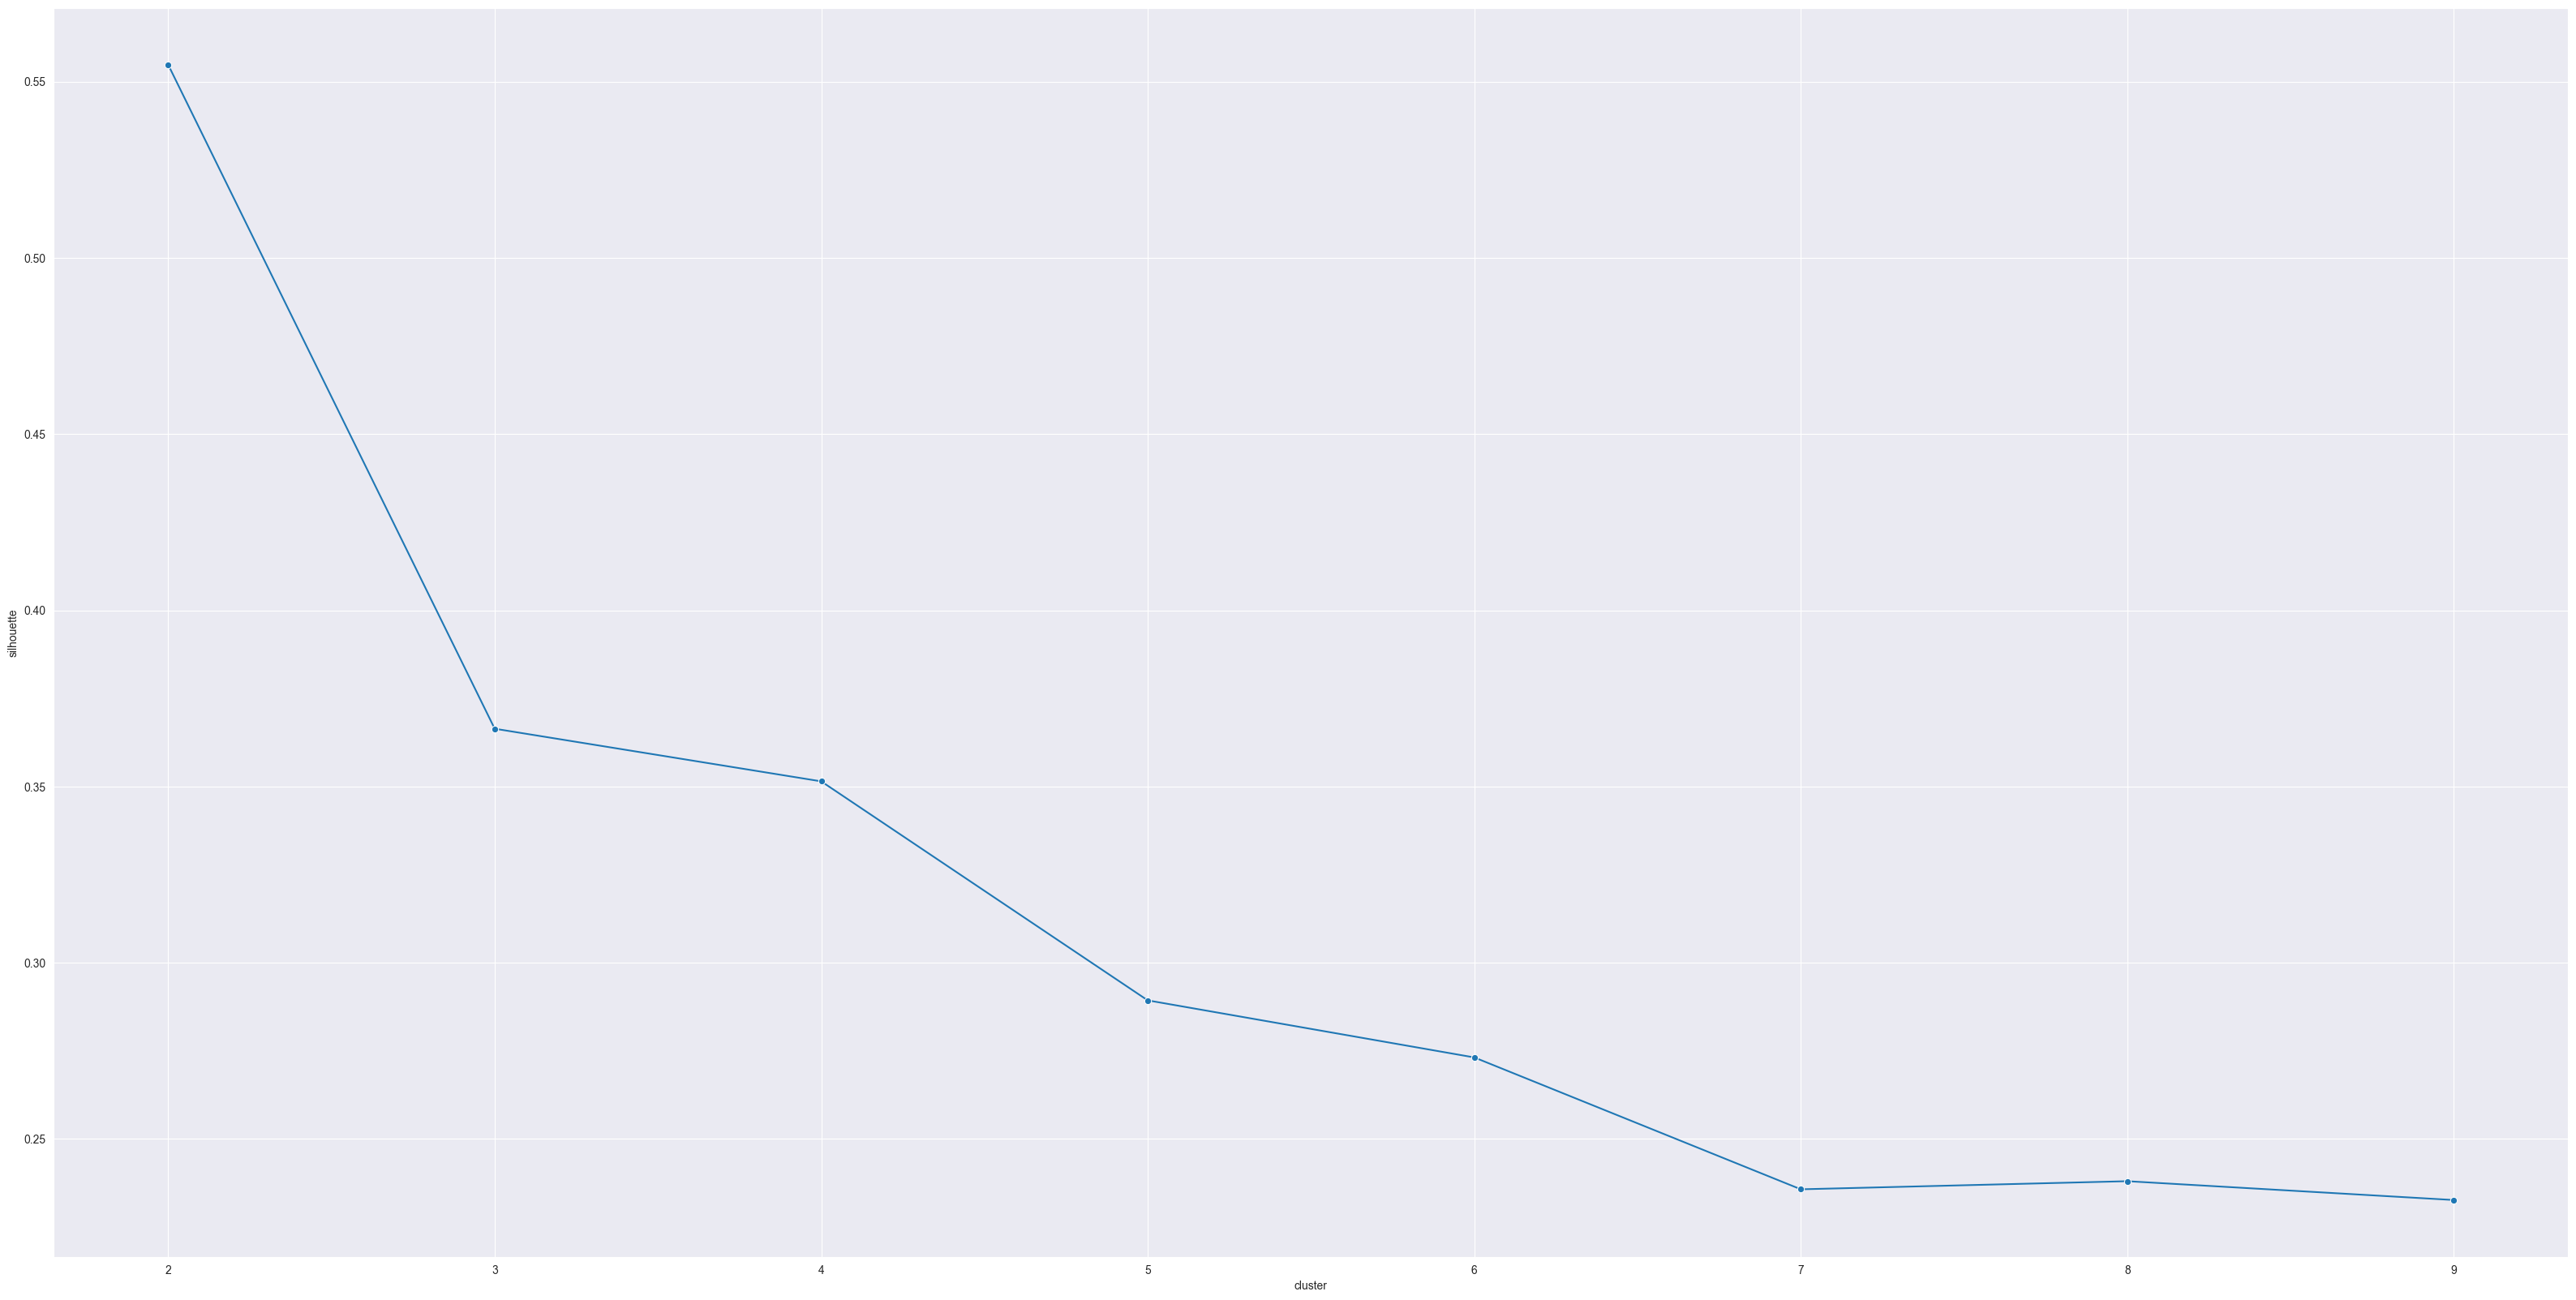

In [372]:
# выберем число кластеров методом силуэта
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, init='k-means++', n_init=10, random_state=42)
    k_means.fit(X)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(X, k_means.predict(X))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res = {"silhouette": [], "cluster": []}

# выберем нужные данные 
X = data_norm

for cluster_num in range(2, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, X))
    silhouette_res["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df = pd.DataFrame(silhouette_res)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

По графику силуэта нам нужно использовать 3 кластера.

In [373]:
# создадим модель кластеризации с 3 кластерами
model_km = KMeans(n_clusters=3, random_state=42).fit(data_norm)

c:\Users\Евгения\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


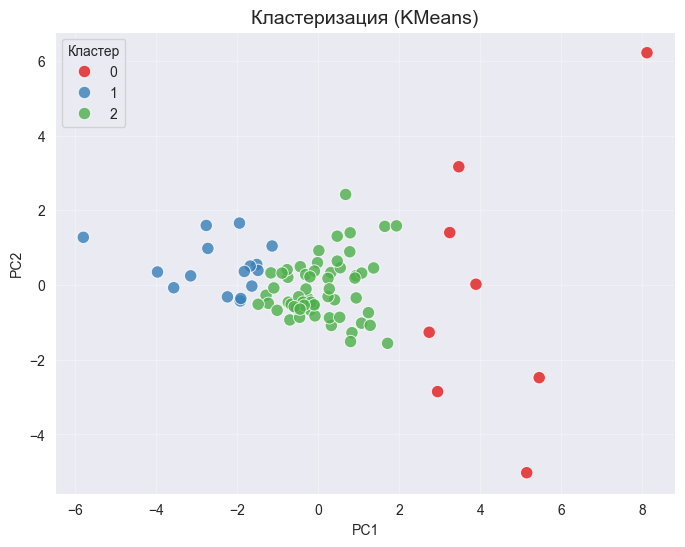

In [374]:
# берём ваши данные после нормализации
data_2d = data_norm

# метки кластеров из модели
labels = model_km.labels_

# рисуем график
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=data_2d[:,0], 
    y=data_2d[:,1], 
    hue=labels, 
    palette="Set1", 
    s=80, 
    alpha=0.8
)

plt.title("Кластеризация (KMeans)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Кластер")
plt.grid(alpha=0.3)
plt.show()

По графику алгоритм kmeans вроде неплохо разделил данные на кластеры. Посмотрим на состав регионов.

In [375]:
# посмотрим на наши кластеры
kmeans_predictions = model_km.fit_predict(data_norm)
data_kmean = data_merged.copy()
data_kmean["clusters_kmeans"] = kmeans_predictions
data_kmean.clusters_kmeans.value_counts()

c:\Users\Евгения\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


clusters_kmeans
2    60
1    16
0     8
Name: count, dtype: int64

Кластеры получились неравномерные. Теперь посмотрим на средний процент бедности в кластерах

In [376]:
# на процент бедности в кластерах
clust_grouped = data_kmean.groupby('clusters_kmeans')['poverty_percent'].mean().round(2)
clust_grouped

clusters_kmeans
0    12.08
1    30.79
2    20.03
Name: poverty_percent, dtype: float64

Получается у нас самый высокий средний процент бедности в кластере 1. А в первом кластере 16 регионов.

In [ ]:
# выведим регионы 
poverty_col = "poverty_percent"  
vulnerable_cluster = cluster_summary[poverty_col].idxmax()

print(f"\n Уязвимый кластер = {vulnerable_cluster} (самый высокий уровень бедности)")

# Список регионов из уязвимого кластера 
vulnerable_regions = data_kmean[data_kmean["clusters_kmeans"] == vulnerable_cluster]["region"].tolist()
print("\n Регионы с наибольшей уязвимостью:")
print(vulnerable_regions)


 Уязвимый кластер = 1 (самый высокий уровень бедности)

 Регионы с наибольшей уязвимостью:
['Республика Алтай', 'Республика Адыгея', 'Республика Бурятия', 'Республика Дагестан', 'Республика Ингушетия', 'Кабардино-Балкарская Республика', 'Республика Калмыкия', 'Карачаево-Черкесская Республика', 'Республика Крым', 'Республика Марий Эл', 'Республика Мордовия', 'Республика Северная Осетия-Алания', 'Республика Тыва', 'Чеченская Республика', 'Забайкальский край', 'Ставропольский край']


### DBSCAN

In [401]:
#  для начала понизим размерность наших данных
data_cl = df_clust.drop(columns=["region"])

pipe_2 = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2))])
data_tsen = pipe_2.fit_transform(data_cl)


In [402]:

X = data_tsen

rows = []
for eps in np.arange(0.2, 5.1, 0.2):       # шире диапазон eps
    for min_samples in range(2, 16, 2):    # min_samples >= 2
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels = db.labels_

        # убираем шум
        mask = labels != -1
        X_n = X[mask]
        y_n = labels[mask]

        # число кластеров среди не-шумовых
        uniq = np.unique(y_n)
        n_clusters = len(uniq)

        # доля шума (для анализа)
        noise_frac = (labels == -1).mean()

        # силуэт считаем только если 2..(n-1) кластеров
        if len(X_n) > 1 and 2 <= n_clusters < len(X_n):
            sil = silhouette_score(X_n, y_n, metric='euclidean')
        else:
            sil = np.nan

        rows.append((eps, min_samples, sil, n_clusters, noise_frac))

df_dbscan = pd.DataFrame(
    rows, columns=['eps', 'min_samples', 'sil_score', 'n_clusters', 'noise_frac']
).sort_values('sil_score', ascending=False)

df_dbscan.head(10)


,eps,min_samples,sil_score,n_clusters,noise_frac
0,0.2,2,0.611987,9,0.583333
29,1.0,4,0.525569,2,0.154762
28,1.0,2,0.497349,2,0.119048
9,0.4,6,0.467066,2,0.690476
14,0.6,2,0.406111,3,0.178571
21,0.8,2,0.352388,4,0.130952
8,0.4,4,0.271243,4,0.345238
7,0.4,2,0.222411,6,0.238095
1,0.2,4,NaN,1,0.821429
2,0.2,6,NaN,1,0.869048


In [407]:
#запускаем кластеризацию на наших данных
clustering_dbsn = DBSCAN(eps=1, min_samples=4).fit(data_tsen)
labels = clustering_dbsn.labels_

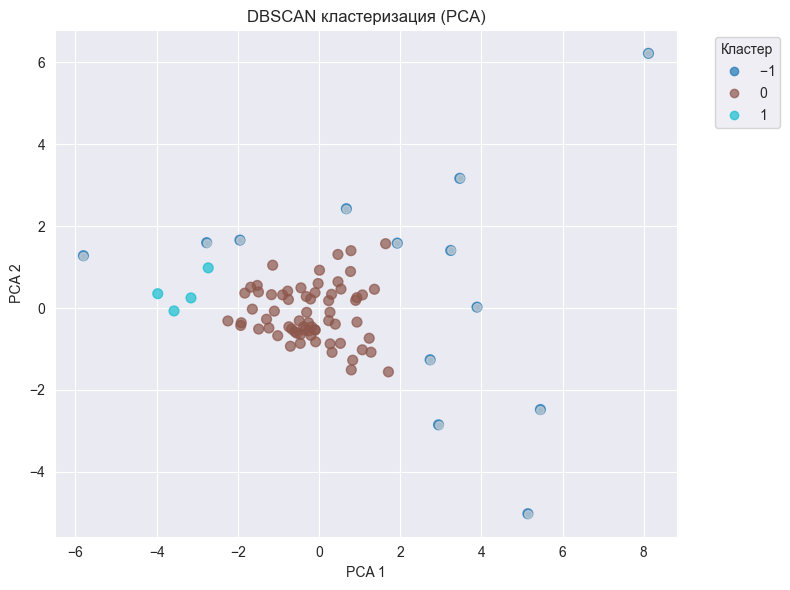

In [408]:
# Рисуем результат
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    data_tsen[:, 0], data_tsen[:, 1],
    c=labels, cmap='tab10', s=50, alpha=0.7
)

# Отдельно отметим шум (label = -1)
plt.scatter(
    data_tsen[labels == -1, 0], data_tsen[labels == -1, 1],
    c="lightgray", s=30, alpha=0.6, label="Шум"
)

plt.title("DBSCAN кластеризация (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Кластер", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Алгоритм DBSCAN Hазделил данные на 2 класса и оставил немного шума (не отнес данные ни к какому классу)

In [409]:
data_dbsn = data_merged.copy()
data_dbsn["clusters_dbsn"] = clustering_dbsn.labels_
data_dbsn.clusters_dbsn.value_counts()

clusters_dbsn
 0    67
-1    13
 1     4
Name: count, dtype: int64

13 регионов алгоритм определил как шум. Кластеры неравномерные: 1 кластере всего 4 региона.

In [410]:
# на процент бедности в кластерах
dbsn_grouped = data_dbsn.groupby('clusters_dbsn')['poverty_percent'].mean().round(2)
dbsn_grouped

clusters_dbsn
-1    17.24
 0    21.18
 1    37.01
Name: poverty_percent, dtype: float64

In [422]:
#  Список регионов из уязвимого кластера 
vulnerable_regions = data_dbsn[data_dbsn["clusters_dbsn"] == vulnerable_cluster]["region"].tolist()
print("\n Регионы с наибольшей уязвимостью:")
print(vulnerable_regions)


 Регионы с наибольшей уязвимостью:
['Кабардино-Балкарская Республика', 'Республика Калмыкия', 'Карачаево-Черкесская Республика', 'Республика Тыва']


Зато выявил 4 кластера с самым высоким процентом бености. В шумовых регионах процент бедности даже ниже, чем в 0 классе. Пока этот алгоритм отработал наилучшим образом.

### Agglomerative Clustering

Лучшее k по силуэту: 4, score=0.371


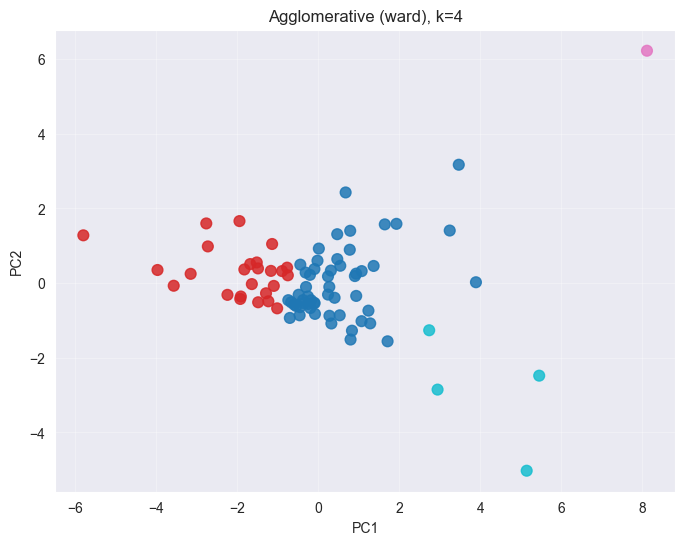

In [388]:
# найдем лучшие параметры по методу силуэта
sil = []
k_range = range(2, 9)
for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(data_tsen)
    sil.append(silhouette_score(data_tsen, labels))

best_k = k_range[int(np.argmax(sil))]
print(f"Лучшее k по силуэту: {best_k}, score={max(sil):.3f}")

#  Обучение с лучшим k
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_agg = agg.fit_predict(data_tsen)

# 3 Визуализация (PCA)
X2 = data_tsen
plt.figure(figsize=(8,6))
plt.scatter(X2[:,0], X2[:,1], c=labels_agg, s=60, alpha=0.85, cmap="tab10")
plt.title(f"Agglomerative (ward), k={best_k}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3)
plt.show()

Agglomerative Clustering Разделил  наши данные на 4 кластера. Посмотрим на распределение регионов и среднего процента бедности.

In [389]:
data_agg = data_merged.copy()
data_agg["clusters_agg"] = labels_agg
data_agg.clusters_agg.value_counts()

clusters_agg
0    54
1    25
3     4
2     1
Name: count, dtype: int64

In [390]:
# на процент бедности в кластерах
agg_grouped = data_agg.groupby('clusters_agg')['poverty_percent'].mean().round(2)
agg_grouped

clusters_agg
0    18.85
1    28.58
2    13.25
3    11.41
Name: poverty_percent, dtype: float64

Алгорим вывел 25 регионов со средним процентом бедности 28.58, то есть эти регионы находятся в зоне уязвимости.

### Gaussian Mixture

Лучшее k по BIC: 2


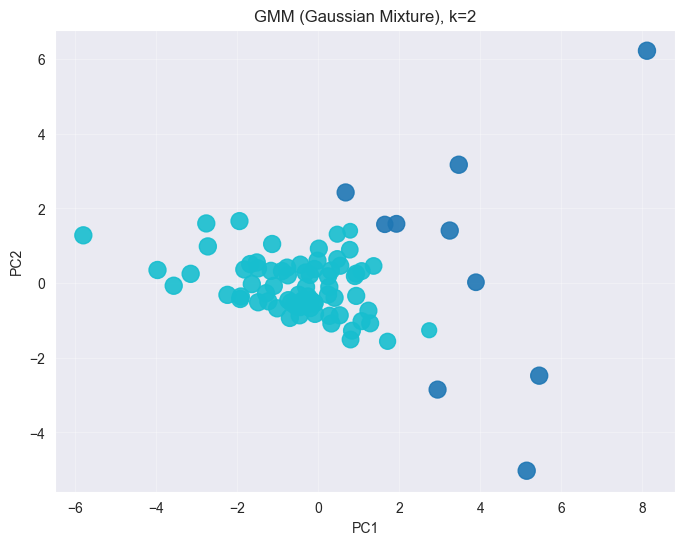

In [391]:
# 1) Подбор числа компонентов по BIC
bic_vals = []
k_range = range(2, 9)
for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(data_tsen)
    bic_vals.append(gmm.bic(data_tsen))

best_k = k_range[int(np.argmin(bic_vals))]
print(f"Лучшее k по BIC: {best_k}")

# 2) Обучаем GMM и берём вероятности/классы
gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=42)
gmm.fit(data_tsen)
labels_gmm = gmm.predict(data_tsen)
proba = gmm.predict_proba(data_tsen).max(axis=1)  # «уверенность» модели

# 3) Визуализация (PCA 2D); размер точки ~ уверенность
X2 = PCA(n_components=2, random_state=42).fit_transform(data_tsen)
plt.figure(figsize=(8,6))
plt.scatter(X2[:,0], X2[:,1], c=labels_gmm, s=30 + 120*proba, alpha=0.9, cmap="tab10")
plt.title(f"GMM (Gaussian Mixture), k={best_k}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3)
plt.show()

GaussianMixture разделил данные на 2 кластера. Посмотрим на показатели

In [392]:
data_gmm = data_merged.copy()
data_gmm["clusters_gmm"] = labels_gmm
data_gmm.clusters_gmm.value_counts()

clusters_gmm
1    74
0    10
Name: count, dtype: int64

In [393]:
# на процент бедности в кластерах
gmm_grouped = data_gmm.groupby('clusters_gmm')['poverty_percent'].mean().round(2).sort_values(ascending=False)
gmm_grouped

clusters_gmm
1    22.48
0    12.79
Name: poverty_percent, dtype: float64

в кластер с 22ю48 процентом бедности вошли 74 региона. Алгорим отработал не очень.

In [444]:
data_gmm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  84 non-null     object 
 1   cash_mean               84 non-null     float64
 2   cmr_mean                84 non-null     float64
 3   cmu_mean                84 non-null     float64
 4   18_30_disab             84 non-null     float64
 5   31_40_disab             84 non-null     float64
 6   41_50_disab             84 non-null     float64
 7   51_60_disab             84 non-null     float64
 8   over_60_disab           84 non-null     float64
 9   alco_sum                84 non-null     float64
 10  drug_sum                84 non-null     float64
 11  vrp_mean                84 non-null     float64
 12  good_cond_house         84 non-null     float64
 13  not_good_cond_house     84 non-null     float64
 14  bad_cond_house          84 non-null     floa

In [456]:
grouped = (data_kmean.groupby('clusters_kmeans').agg({
    '18_30_disab': 'mean',
    '31_40_disab': 'mean',
    '41_50_disab': 'mean',
    '51_60_disab': 'mean',
    'over_60_disab': 'mean',
    'adult_pover': 'mean',
    'retired_pover': 'mean',
    'children_befor16_pover':'mean',
    'bad_cond_house': 'mean',
    'good_cond_house': 'mean'
 
}).round(2))
grouped

,18_30_disab,31_40_disab,41_50_disab,51_60_disab,over_60_disab,adult_pover,retired_pover,children_befor16_pover,bad_cond_house,good_cond_house
clusters_kmeans,,,,,,,,,,
0,8310.25,12488.72,17459.88,35834.04,186583.57,47.38,4.77,39.52,3.44,79.96
1,7060.91,9897.68,13084.62,19359.57,38025.81,52.93,6.68,38.84,4.59,78.65
2,5343.82,8733.36,11563.61,21526.01,79961.88,54.35,6.25,38.29,3.80,81.76


### ИТОГО: 
Алгоритм DBSN покаазлал наилучший резуультат, вывявив 4 региона:'Кабардино-Балкарская Республика', 'Республика Калмыкия', 'Карачаево-Черкесская Республика', 'Республика Тыва', но оставил много шума.

Результаты KMEANs 16 регионов: 'Республика Алтай', 'Республика Адыгея', 'Республика Бурятия', 'Республика Дагестан', 'Республика Ингушетия', 'Кабардино-Балкарская Республика', 'Республика Калмыкия', 'Карачаево-Черкесская Республика', 'Республика Крым', 'Республика Марий Эл', 'Республика Мордовия', 'Республика Северная Осетия-Алания', 'Республика Тыва', 'Чеченская Республика', 'Забайкальский край', 'Ставропольский край'


Уязвимые группы: пожилые люди и дети до 16 лет, живущие в домах с плохими условиями

## Часть 4. Запуск в продакшин

Будем использовать кластеры, которые определил нам KMEANS, так как он определил регоны с  высоким средним процентом  бедности

In [424]:
# создадим признак уязвимости региона

cluster_pov = data_kmean.groupby("clusters_kmeans")["poverty_percent"].mean().sort_values(ascending=False)


q = 0.90  # верхний квартиль 
thr = cluster_pov.quantile(q)
vulnerable_clusters = cluster_pov[cluster_pov >= thr].index.tolist()

print("уязвимые кластеры:", vulnerable_clusters)

# создаём целевую переменную y: 1 — уязвимый кластер, 0 — остальные
data_kmean = data_kmean.copy()
data_kmean["is_vulnerable"] = data_kmean["clusters_kmeans"].isin(vulnerable_clusters).astype(int)

print(data_kmean["is_vulnerable"].value_counts())





уязвимые кластеры: [1]
is_vulnerable
0    68
1    16
Name: count, dtype: int64


In [426]:

# разделим выборку на 

X = data_kmean.drop(["clusters_kmeans", "poverty_percent", "is_vulnerable", "region"], axis=1)
y = data_kmean["is_vulnerable"]

In [427]:
# разделим данные на тестовую и обучающиую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [428]:
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [439]:
# создадим pipeline с стандартизацией данных и logstic regression 
pipe_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        random_state=42
        ))
    ])

pipe_lr.fit(X_train, y_train)

# predict & metrics
y_pred_lr = pipe_lr.predict(X_test)

print("accuracy на тестовом наборе: {:.2f}".format(pipe_lr.score(X_test, y_test)))

print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_pred_lr)))

accuracy на тестовом наборе: 0.81
f1_score на тестовом наборе: 0.33


In [ ]:


# создадим pipeline с стандартизацией данных и рандомным лесом, количество деревьем выберем 500, random_state=42, class_weight="balanced", остальные параметры оставим по умолчанию. 
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"))
])

# обучаем 
pipe.fit(X_train, y_train)

# предсказание и выводим метрики
y_pred = pipe.predict(X_test)


print("accuracy на тестовом наборе: {:.2f}".format(pipe.score(X_test, y_test)))

print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_pred)))




accuracy на тестовом наборе: 0.90
f1_score на тестовом наборе: 0.67


Получили следующие результаты:

*Случайный лес*:
* accuracy на тестовом наборе: 0.90
* f1_score на тестовом наборе: 0.67 

*Логистическая регрессия*:
* accuracy на тестовом наборе: 0.81
* f1_score на тестовом наборе: 0.33

Попробуем улучшить параметры с помощью GridSearchCV и hyperopt

In [437]:

# pipeline for the model
pipe_gs_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("regressor", LogisticRegression()),
    ]
)


param_grid = {
    "regressor": [LogisticRegression(random_state=42)],
    "regressor__penalty": ['l2', 'none'],
    "regressor__solver": ['lbfgs', 'sag'],
    "regressor__C": [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
    
    
}



grid = GridSearchCV(
    pipe_gs_lr,
    param_grid=param_grid,
    cv=5,
    n_jobs = -1
)

grid.fit(X_train, y_train)

print("accuracy на тестовом наборе: {:.2f}".format(grid.score(X_test, y_test)))
y_test_pred = grid.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid.best_params_))

accuracy на тестовом наборе: 0.86
f1_score на тестовом наборе: 0.57
Наилучшие значения гиперпараметров: {'regressor': LogisticRegression(C=0.01, penalty='none', random_state=42, solver='sag'), 'regressor__C': 0.01, 'regressor__penalty': 'none', 'regressor__solver': 'sag'}


c:\Users\Евгения\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
c:\Users\Евгения\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Евгения\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [457]:


# 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_state = 42

def make_rf_pipeline(params):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]) if params["max_depth"] is not None else None,
            min_samples_leaf=int(params["min_samples_leaf"]),
            max_features=params["max_features"],
            class_weight=params["class_weight"],
            n_jobs=-1,
            random_state=random_state
        ))
    ])

# пространство гиперпараметров
space_rf = {
    "n_estimators":     hp.quniform("rf_n_estimators", 100, 500, 10),
    "max_depth":        hp.qloguniform("rf_max_depth", np.log(4), np.log(64), 1),
    "min_samples_leaf": hp.quniform("rf_min_samples_leaf", 1, 10, 1),
    "max_features":     hp.choice("rf_max_features", ["sqrt", "log2", 0.5, 0.7, 1.0]),
    "class_weight":     hp.choice("rf_class_weight", [None, "balanced"]),
}

def objective_rf(params):
    use_params = {
        "n_estimators": int(params["n_estimators"]),
        "max_depth": int(params["max_depth"]),
        "min_samples_leaf": int(params["min_samples_leaf"]),
        "max_features": params["max_features"],
        "class_weight": params["class_weight"],
    }
    pipe = make_rf_pipeline(use_params)
    # === главная метрика для оптимизации — F1
    cv_f1  = cross_val_score(pipe, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    # === для информации также посчитаем Accuracy на CV
    cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
    return {"loss": -cv_f1, "status": STATUS_OK, "cv_f1": cv_f1, "cv_acc": cv_acc, "params": use_params}

trials_rf = Trials()
best_rf_raw = fmin(
    fn=objective_rf,
    space=space_rf,
    algo=partial(tpe.suggest, n_startup_jobs=20),
    max_evals=80,
    trials=trials_rf,
    rstate=np.random.default_rng(42)
)

# декодируем choice-поля
best_rf = {
    "n_estimators": int(best_rf_raw["rf_n_estimators"]),
    "max_depth": int(best_rf_raw["rf_max_depth"]),
    "min_samples_leaf": int(best_rf_raw["rf_min_samples_leaf"]),
    "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0][best_rf_raw["rf_max_features"]],
    "class_weight": [None, "balanced"][best_rf_raw["rf_class_weight"]],
}
print("Лучшие параметры RF:", best_rf)

# финальная модель и метрики (F1, Accuracy)
pipe_rf = make_rf_pipeline(best_rf)
pipe_rf.fit(X_train, y_train)

y_pred = pipe_rf.predict(X_test)
print("TEST F1:", metrics.f1_score(y_test, y_pred))
print("TEST Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("\nClassification report:\n", metrics.classification_report(y_test, y_pred, digits=3))


100%|██████████| 80/80 [05:39<00:00,  4.25s/trial, best loss: -0.8647619047619047]
Лучшие параметры RF: {'n_estimators': 260, 'max_depth': 28, 'min_samples_leaf': 3, 'max_features': 0.7, 'class_weight': 'balanced'}
TEST F1: 0.5714285714285715
TEST Accuracy: 0.8571428571428571

Classification report:
               precision    recall  f1-score   support

           0      0.889     0.941     0.914        17
           1      0.667     0.500     0.571         4

    accuracy                          0.857        21
   macro avg      0.778     0.721     0.743        21
weighted avg      0.847     0.857     0.849        21



# ВЫВОД

1. Мы провели кластеризацию и выявили:
* уязвимые регионы - 'Республика Алтай', 'Республика Адыгея', 'Республика Бурятия', 'Республика Дагестан', 'Республика Ингушетия', 'Кабардино-Балкарская Республика', 'Республика Калмыкия', 'Карачаево-Черкесская Республика', 'Республика Крым', 'Республика Марий Эл', 'Республика Мордовия', 'Республика Северная Осетия-Алания', 'Республика Тыва', 'Чеченская Республика', 'Забайкальский край', 'Ставропольский край'
* уязвимые группы населения - пожилые люди и дети до 16 лет, живущие в домах с неблогаприятными условиями.

2. Провели классиикацию и добились результата accuracy 0.86,  f1-score 0.57. Теперь наш алгоритм готов к тому, чтобы предсказать, к какой группе относится человек с заданными стат показателями.